Où se trouve le dossier sur la machine ?
http://10.117.49.59:8888/notebooks/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/Test_GGD_Pi.ipynb

In [2]:
# pour telecharder de la machine à mon ordinateur local
import os

def sync_files(user, host, password, remote_path, local_path=None):
    if local_path is None:
        local_path = os.getcwd()

    # Détection : est-ce un fichier (on regarde si un nom de fichier semble être présent) ?
    is_file = os.path.splitext(local_path)[1] != ""

    if is_file:
        # Cas fichier : on s'assure que le dossier contenant le fichier existe
        local_dir = os.path.dirname(local_path)
        if not os.path.exists(local_dir):
            print(f"📁 Création du dossier parent : {local_dir}")
            os.makedirs(local_dir)
        command = f'sshpass -p "{password}" rsync -ah --progress -u "{user}@{host}:{remote_path}" "{local_path}"'
    else:
        # Cas dossier : on crée le dossier si nécessaire
        if not os.path.exists(local_path):
            print(f"📁 Création du dossier : {local_path}")
            os.makedirs(local_path)
        command = f'sshpass -p "{password}" rsync -ah --progress -u "{user}@{host}:{remote_path}" "{local_path}"'

    print(f"🚀 Exécution : {command}")
    !{command}



In [3]:
# Définition des informations communes
PASSWORD="Cedt,ll?"
USER="isabelle.bouchoule"
HOST="10.117.49.59"

In [4]:
# parametre selectionné
nom1 = "theta_edge_1.0_ih1"
nom2 = "theta_edge_1.0_ih2"
date = "2025-01-27"
mu , T , x0 , Taille = 64.676, 559.424, 18.339, 22.089

In [5]:
import os

index_last_underscore = nom2.rfind('_')
remote_path0 ="/home/isabelle.bouchoule/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/"
local_path = os.getcwd()

# theta
filename = f"{date}/theta_discr_{nom2[index_last_underscore+1:]}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )

# nu
filename = f"{date}/nu_discr_{nom1[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}.npz" 
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )

# veff
filename = f"{date}/veff_bord_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )


✅ Fichier 'donnees1.dat' écrit avec 50 lignes.
✅ Fichier enregistré sous : insitut.table
✅ Fichier enregistré sous : insitut_minus.table


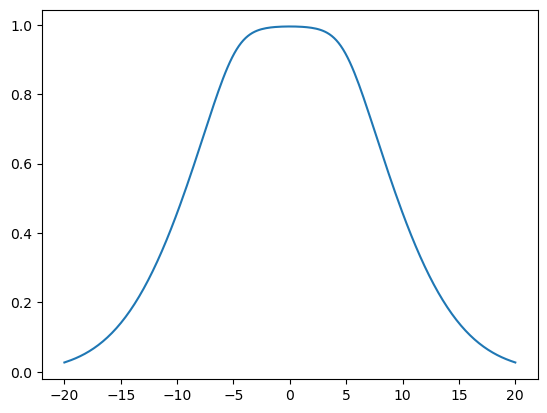

In [6]:
import numpy as np
import matplotlib.pyplot as plt

filename = f"{date}/theta_discr_{nom2[index_last_underscore+1:]}.npz"
theta_discr = np.load(filename)

filename = f"{date}/nu_discr_{nom1[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}.npz" 
nu0 = np.load(filename)

filename = f"{date}/veff_bord_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}.npz"
veff_bord_discr = np.load(filename)

Temp_bord = 18

plt.plot(theta_discr , nu0 )

def write_triplet_data(x_list, y_list, z_list, filepath="donnees.dat"):
    if not (len(y_list) == len(z_list)):
        raise ValueError("Les listes y et z doivent avoir la même longueur.")

    with open(filepath, "w") as f:
        f.write("x y z\n")  # en-tête facultatif, tu peux le retirer
        for x in x_list : 
            for y, z in zip(y_list, z_list):
                f.write(f"{x} {y} {z}\n")

    print(f"✅ Fichier '{filepath}' écrit avec {len(x_list)} lignes.")

write_triplet_data(theta_discr[::4], theta_discr[::2], nu0[::2], "donnees1.dat")

def save_as_tikz_table(x, y, filename="plot.table"):
    """
    Enregistre les listes x et y dans un fichier .table pour TikZ.
    Format :
    #Curve 0, N points
    #x y type
    x1 y1 i
    x2 y2 i
    ...
    """
    assert len(x) == len(y), "x et y doivent avoir la même longueur"
    n_points = len(x)

    with open(filename, "w") as f:
        f.write(f"#Curve 0, {n_points} points\n")
        f.write("#x y type\n")
        #f.write(f"{-9:.5f} {0:.5f} i\n")
        for xi, yi in zip(x, y):
            f.write(f"{xi:.5f} {yi:.5f} i\n")
        #f.write(f"{9:.5f} {0:.5f} i\n")

    print(f"✅ Fichier enregistré sous : {filename}")

save_as_tikz_table(theta_discr*8.8/20, nu0*5, filename="insitut.table")
save_as_tikz_table(theta_discr*8.8/20, -nu0*5, filename="insitut_minus.table")

# x y type
-8.80000 0.13537 i
-8.71156 0.14643 i
-8.62312 0.15790 i
-8.53467 0.17002 i
-8.44623 0.18288 i
-8.35779 0.19655 i
-8.26935 0.21106 i
-8.18090 0.22647 i
-8.09246 0.24281 i
-8.00402 0.26013 i
-7.91558 0.27848 i
-7.82714 0.29790 i
-7.73869 0.31843 i
-7.65025 0.34013 i
-7.56181 0.36303 i
-7.47337 0.38718 i
-7.38492 0.41263 i
-7.29648 0.43942 i
-7.20804 0.46760 i
-7.11960 0.49722 i
-7.03116 0.52833 i
-6.94271 0.56096 i
-6.85427 0.59516 i
-6.76583 0.63098 i
-6.67739 0.66845 i
-6.58894 0.70763 i
-6.50050 0.74854 i
-6.41206 0.79124 i
-6.32362 0.83574 i
-6.23518 0.88210 i
-6.14673 0.93034 i
-6.05829 0.98048 i
-5.96985 1.03257 i
-5.88141 1.08662 i
-5.79296 1.14265 i
-5.70452 1.20068 i
-5.61608 1.26072 i
-5.52764 1.32280 i
-5.43920 1.38690 i
-5.35075 1.45304 i
-5.26231 1.52122 i
-5.17387 1.59142 i
-5.08543 1.66364 i
-4.99698 1.73785 i
-4.90854 1.81405 i
-4.82010 1.89220 i
-4.73166 1.97227 i
-4.64322 2.05423 i
-4.55477 2.13803 i
-4.46633 2.22362 i
-4.37789 2.31094 i
-4.28945 2.39994 i
-

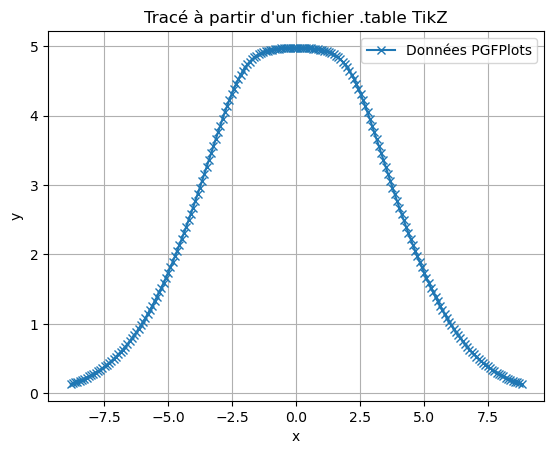

In [7]:
import matplotlib.pyplot as plt

def read_and_plot_table(filename):
    """
    Lit un fichier .table au format TikZ (PGFPlots),
    affiche les données, et trace le graphe.
    """
    x, y,  typ= [], [] , []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) >= 2:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
                typ.append(parts[2])

    # Afficher les données dans le terminal
    print("# x y type")
    for xi, yi , i in zip(x, y , typ):
        print(f"{xi:.5f} {yi:.5f} {i}")

    # Tracer
    plt.plot(x, y, marker='x', linestyle='-', label='Données PGFPlots')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Tracé à partir d'un fichier .table TikZ")
    plt.grid(True)
    plt.legend()
    plt.show()

read_and_plot_table(filename="insitut.table")

/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_5859/3627408683.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("donnees1.dat", delim_whitespace=True)


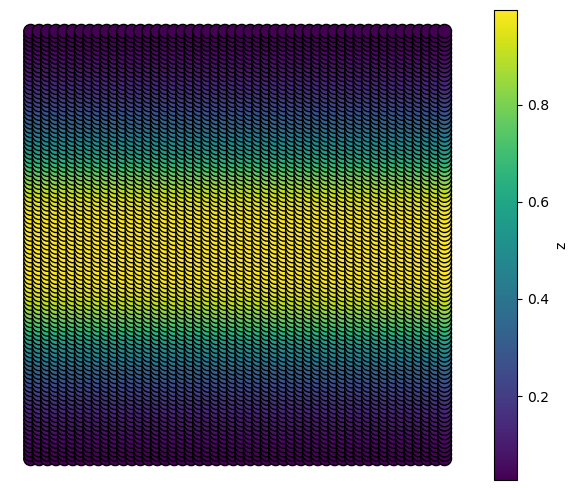

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("donnees1.dat", delim_whitespace=True)

# Extraire x, y, z
x = df['x']
y = df['y']
z = df['z']

# Création de la figure
plt.figure(figsize=(6, 5))
scatter = plt.scatter(x, y, c=z, cmap='viridis', s=100, edgecolor='k')
plt.colorbar(scatter, label='z')
plt.xticks([])  # Pas de graduations sur x
plt.yticks([])  # Pas de graduations sur y
plt.box(False)  # Enlever les bordures de l’axe
plt.tight_layout()
plt.show()


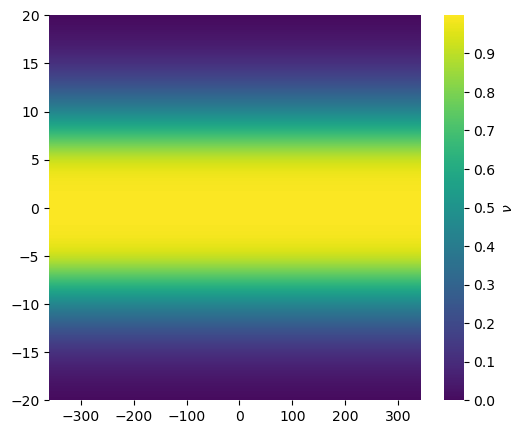

In [9]:
from matplotlib.ticker import FormatStrFormatter

vmin=0
vmax=1
X, Y = np.meshgrid(veff_bord_discr*Temp_bord, theta_discr)
# ➤ Plus de niveaux pour une couleur plus continue
nb_levels = 1000

# Exemple simple
fig, ax = plt.subplots(figsize=(6, 5)) 
cf = ax.contourf( X, Y,   np.array([nu0 for v in veff_bord_discr]).T, levels=nb_levels , cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 1)

# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar avec 21 décimales
cbar = plt.colorbar(cf , label= r'$\nu$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarde
plt.savefig("insitut.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

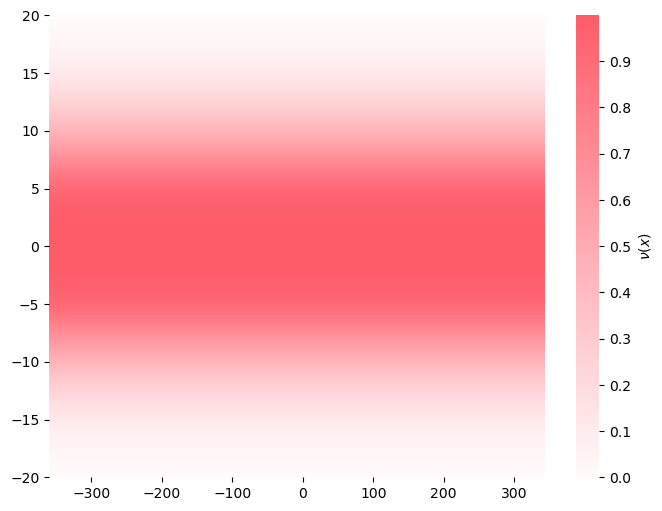

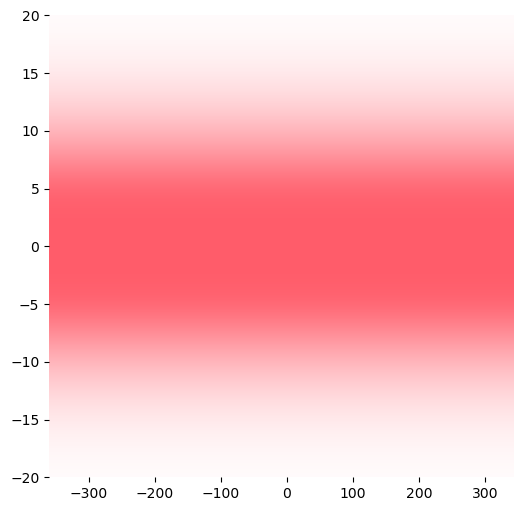

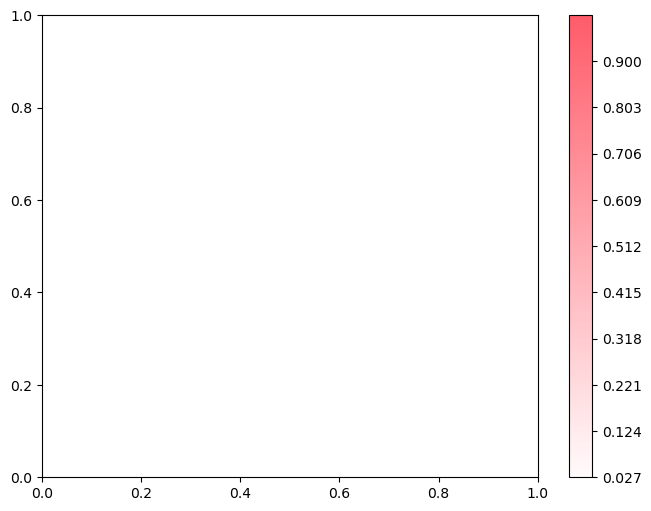

In [10]:
# Définir vmin et vmax pour la colorbar
from matplotlib.colors import LinearSegmentedColormap
# Définition des couleurs HTML
colors = ['#443E46' , '#908CA4' ,  '#57659E', '#F6DEB8' ,  '#C57284', '#FF5B69']  # colorFour → colorFive → colorSix
colors = ['#443E46'  ,  '#57659E' ,   '#C57284' ,'#FF5B69'  ]
colors = ['#FFFFFF'  , '#FF5B69'  ]
#\definecolor{colorOne}{HTML}{443E46}
#\definecolor{colorTwo}{HTML}{F6DEB8}
#\definecolor{colorThree}{HTML}{908CA4}
#\definecolor{colorFour}{HTML}{57659E}
#\definecolor{colorFive}{HTML}{C57284}
#\definecolor{colorSix}{HTML}{FF5B69}
# Création du colormap continu
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

vmin = 0
vmax = 1

# Créer les maillages X et Y
X, Y = np.meshgrid(veff_bord_discr * Temp_bord, theta_discr)

# Définir les niveaux pour un contour plus continu
nb_levels = 1000

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 6))

# Créer un graphique de contours
cf = ax.contourf(X, Y, np.array([nu0 for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)

# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajouter la barre de couleur avec 1 décimale
cbar = plt.colorbar(cf, ax=ax, label=r'$\nu(x)$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarder le graphique complet avec les axes et la colorbar
fig.savefig("complete_graph_insitut.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder les axes sans le graphique ni la colorbar
fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, np.array([nu0 for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax_axes.set_axis_off()  # Masquer les axes
# Supprimer les traits noirs autour de la figure
for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_insitut_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder la colorbar seule
fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_insitut_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Afficher la figure
plt.show()

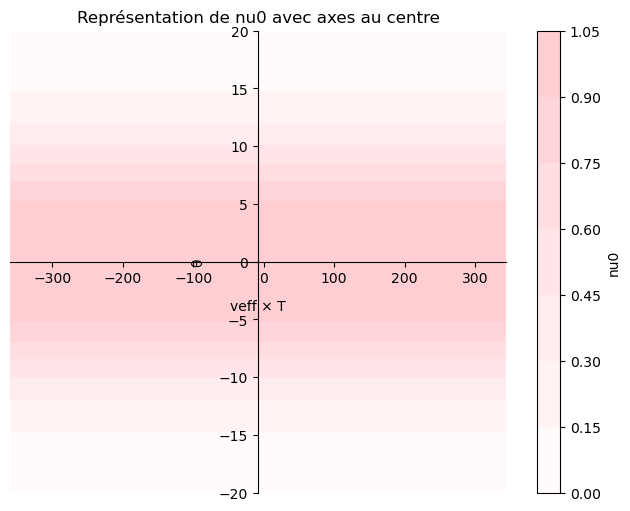

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple de données (à adapter aux tiennes)
# veff_bord_discr = np.linspace(-1, 1, 50)
# theta_discr = np.linspace(-np.pi, np.pi, 50)
# Temp_bord = 1.0
# nu0 = np.random.rand(len(theta_discr), len(veff_bord_discr))

vmin = 0
vmax = 1

X, Y = np.meshgrid(veff_bord_discr * Temp_bord, theta_discr)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y,np.array([nu0 for v in veff_bord_discr]).T, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
plt.colorbar(contour, ax=ax, label='nu0')

# Déplacement des axes au centre
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

# Cache les axes du haut et de droite
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Déplace les ticks des axes vers le centre
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Labels
ax.set_xlabel("veff × T", labelpad=10)
ax.set_ylabel("θ", labelpad=10)
ax.set_title("Représentation de nu0 avec axes au centre")

plt.show()


✅ Fichier enregistré sous : bord_0_0.table


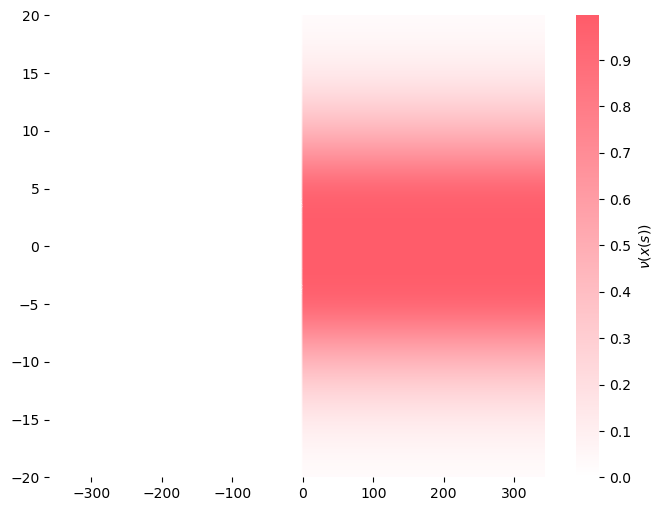

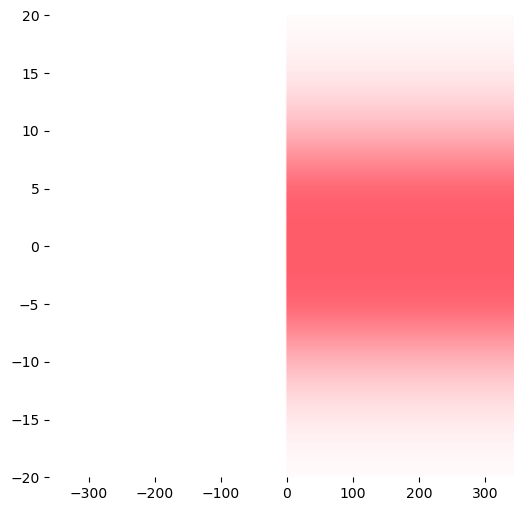

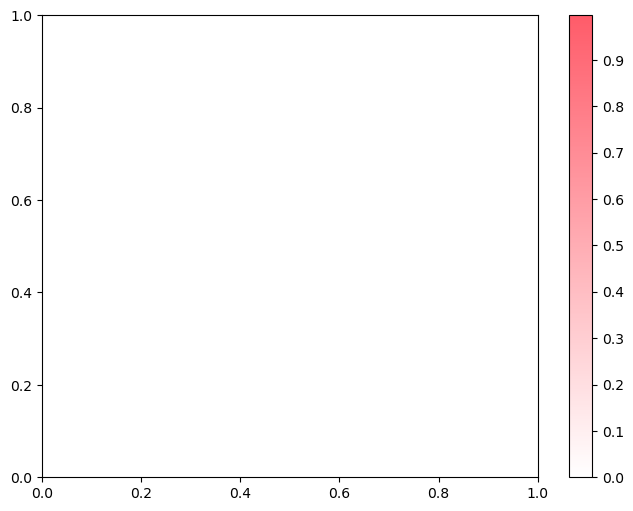

In [12]:
filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_{0:.3f}.npz" 
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
mydensity = np.load(filename)

save_as_tikz_table(mydensity[0,:]*8.8/350, theta_discr*8.8/20, filename="bord_0_0.table")

# Définir vmin et vmax pour la colorbar
vmin = 0
vmax = 1

# Créer les maillages X et Y
X, Y = np.meshgrid(veff_bord_discr * Temp_bord, theta_discr)

# Définir les niveaux pour un contour plus continu
nb_levels = 1000

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 6))

# Créer un graphique de contours
cf = ax.contourf(X, Y, np.array([nu0 if v > 0 else np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax.plot(mydensity[0,:] ,theta_discr , color="#F6DEB8", linewidth=4 , alpha = 0.5 ) 



# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajouter la barre de couleur avec 1 décimale
cbar = plt.colorbar(cf, ax=ax, label=r'$\nu(x(s))$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarder le graphique complet avec les axes et la colorbar
fig.savefig("complete_graph_coupure_1_0.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder les axes sans le graphique ni la colorbar
fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, np.array([nu0 if v > 0 else np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax_axes.set_axis_off()  # Masquer les axes
#ax_axes.plot(mydensity[0,:] ,theta_discr , color="#F6DEB8", linewidth=4 , linestyle='-.',  alpha = 0.4 ) 
# Supprimer les traits noirs autour de la figure
for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_coupure_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder la colorbar seule
fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_coupure_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Afficher la figure
plt.show()

✅ Fichier enregistré sous : bord_0_0.table


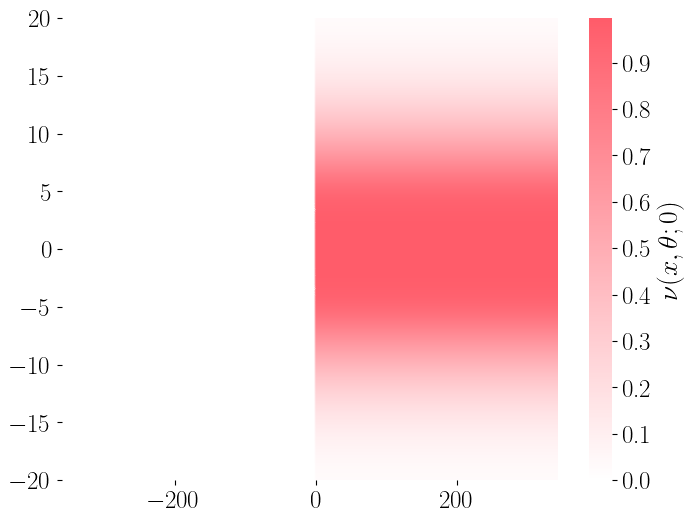

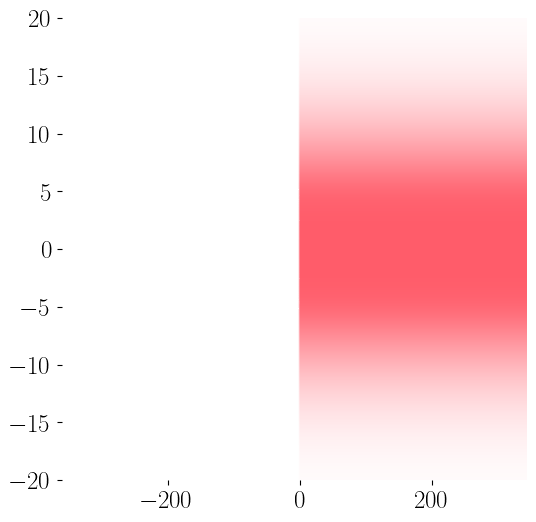

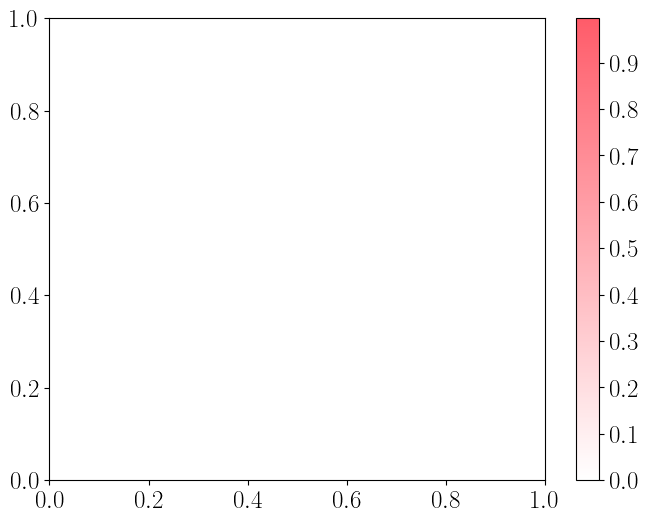

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Configuration générale pour la figure ---
plt.rcParams.update({
    "text.usetex": True,                # utilise LaTeX pour tout le texte
    "font.family": "serif",             # police de type LaTeX
    "font.serif": ["Computer Modern"],  # police math classique
    "axes.labelsize": 20,               # taille des labels (x,y)
    "axes.titlesize": 22,               # taille du titre
    "xtick.labelsize": 18,              # taille des graduations axe x
    "ytick.labelsize": 18,              # taille des graduations axe y
    "legend.fontsize": 18,              # taille de la légende
    "figure.titlesize": 24,             # taille du titre de la figure

    # --- Palette de couleurs personnalisée ---
    "axes.prop_cycle": plt.cycler(color=[
        "#443E46",  # colorOne : gris violet foncé
        "#6C5B7B",  # colorTwo : lavande sombre
        "#C06C84",  # colorThree : rose vintage
        "#F67280",  # colorFour : corail chaud
        "#F8B195",  # colorFive : pêche clair
        "#355C7D",  # colorSix : bleu acier profond
        "#99B898",  # colorSeven : vert doux
        "#FECEAB",  # colorEight : beige pastel
        "#E84A5F",  # colorNine : rouge framboise
        "#2A363B",  # colorTen : gris anthracite
    ]),

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "none",

})

# --- Ton code inchangé ---
filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_{0:.3f}.npz" 
mydensity = np.load(filename)

save_as_tikz_table(mydensity[0,:]*8.8/350, theta_discr*8.8/20, filename="bord_0_0.table")

vmin = 0
vmax = 1
X, Y = np.meshgrid(veff_bord_discr * Temp_bord, theta_discr)
nb_levels = 1000

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X, Y, np.array([nu0 if v > 0 else np.zeros(len(nu0)) for v in veff_bord_discr]).T,
                 levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(cf, ax=ax, label=r'$\nu(x,\theta;0)$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarde
fig.savefig("complete_graph_coupure_1_0.pdf", dpi=300, bbox_inches='tight', transparent=True)

fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, np.array([nu0 if v > 0 else np.zeros(len(nu0)) for v in veff_bord_discr]).T,
                 levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)

for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_coupure_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_coupure_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

plt.show()


✅ Fichier enregistré sous : bord_0_sur_18.table


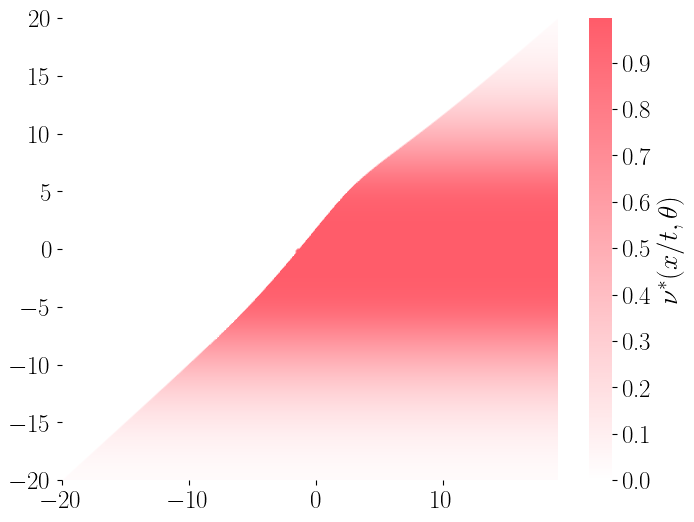

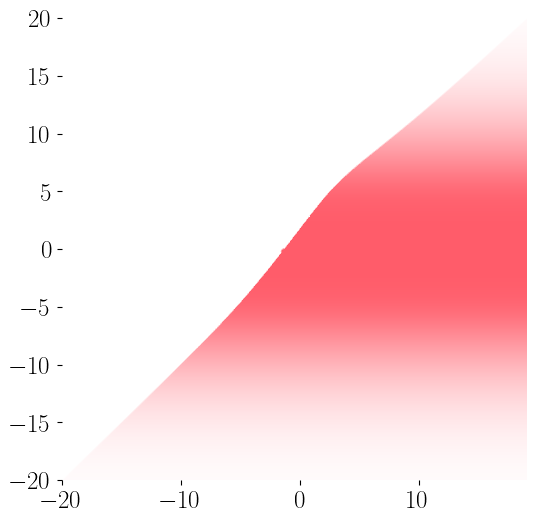

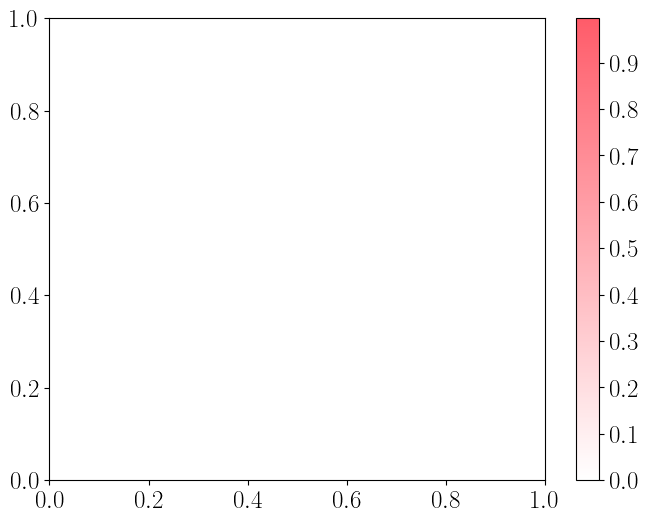

✅ Fichier enregistré sous : coupure_1_sur_18.table
3.1920263799915936
✅ Fichier enregistré sous : coupure_1_sur_18.table
# x y type
-8.80000 0.13537 i
-8.71156 0.14643 i
-8.62312 0.15790 i
-8.53467 0.17002 i
-8.44623 0.18288 i
-8.35779 0.19655 i
-8.26935 0.21106 i
-8.18090 0.22647 i
-8.09246 0.24281 i
-8.00402 0.26013 i
-7.91558 0.27848 i
-7.82714 0.29790 i
-7.73869 0.31843 i
-7.65025 0.34013 i
-7.56181 0.36303 i
-7.47337 0.38718 i
-7.38492 0.41263 i
-7.29648 0.43942 i
-7.20804 0.46760 i
-7.11960 0.49722 i
-7.03116 0.52833 i
-6.94271 0.56096 i
-6.85427 0.59516 i
-6.76583 0.63098 i
-6.67739 0.66845 i
-6.58894 0.70763 i
-6.50050 0.74854 i
-6.41206 0.79124 i
-6.32362 0.83574 i
-6.23518 0.88210 i
-6.14673 0.93034 i
-6.05829 0.98048 i
-5.96985 1.03257 i
-5.88141 1.08662 i
-5.79296 1.14265 i
-5.70452 1.20068 i
-5.61608 1.26072 i
-5.52764 1.32280 i
-5.43920 1.38690 i
-5.35075 1.45304 i
-5.26231 1.52122 i
-5.17387 1.59142 i
-5.08543 1.66364 i
-4.99698 1.73785 i
-4.90854 1.81405 i
-4.82010 1.89

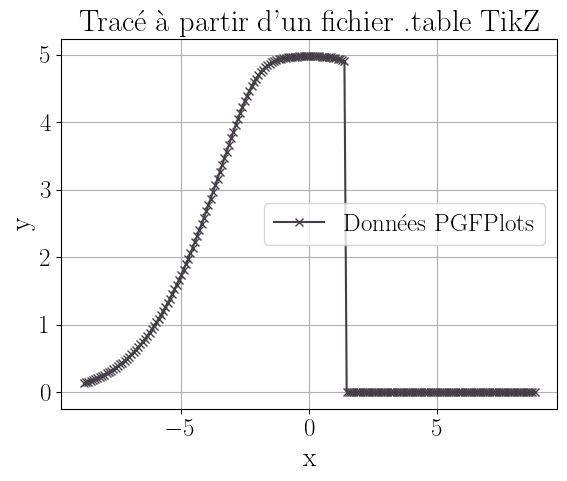

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Configuration générale pour la figure ---
plt.rcParams.update({
    "text.usetex": True,                # utilise LaTeX pour tout le texte
    "font.family": "serif",             # police de type LaTeX
    "font.serif": ["Computer Modern"],  # police math classique
    "axes.labelsize": 20,               # taille des labels (x,y)
    "axes.titlesize": 22,               # taille du titre
    "xtick.labelsize": 18,              # taille des graduations axe x
    "ytick.labelsize": 18,              # taille des graduations axe y
    "legend.fontsize": 18,              # taille de la légende
    "figure.titlesize": 24,             # taille du titre de la figure

    # --- Palette de couleurs personnalisée ---
    "axes.prop_cycle": plt.cycler(color=[
        "#443E46",  # colorOne : gris violet foncé
        "#6C5B7B",  # colorTwo : lavande sombre
        "#C06C84",  # colorThree : rose vintage
        "#F67280",  # colorFour : corail chaud
        "#F8B195",  # colorFive : pêche clair
        "#355C7D",  # colorSix : bleu acier profond
        "#99B898",  # colorSeven : vert doux
        "#FECEAB",  # colorEight : beige pastel
        "#E84A5F",  # colorNine : rouge framboise
        "#2A363B",  # colorTen : gris anthracite
    ]),

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "none",

})


filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_veff_bord.npz" 
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
mydensity = np.load(filename)

#print ( "max" , max(mydensity[0,:]) , max(theta_discr) ) 

save_as_tikz_table(mydensity[0,:]*8.63/max(mydensity[0,:]), theta_discr*8.8/max(theta_discr), filename="bord_0_sur_18.table")

# Définir vmin et vmax pour la colorbar
import numpy as np
from scipy.interpolate import interp1d
# Fonction d'interpolation linéaire
def LinearInterpolation(x, y):
    return interp1d(x, y, kind='linear', fill_value="extrapolate")
    
theta_veff_fun = LinearInterpolation(veff_bord_discr, theta_discr) 
nu_fun = LinearInterpolation(theta_discr , nu0)
mat_nu = np.array([ np.where(  theta_discr <theta_veff_fun(v),  nu0 , 0 ) for v in veff_bord_discr])

vmin = 0
vmax = 1

# Créer les maillages X et Y
X, Y = np.meshgrid(veff_bord_discr , theta_discr)

# Définir les niveaux pour un contour plus continu
nb_levels = 1000

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 6))

# Créer un graphique de contours
cf = ax.contourf(X, Y, mat_nu.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)

# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajouter la barre de couleur avec 1 décimale
cbar = plt.colorbar(cf, ax=ax, label=r'$\nu^\ast(x/t,\theta)$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarder le graphique complet avec les axes et la colorbar
fig.savefig("complete_graph_coupure_1_18.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder les axes sans le graphique ni la colorbar
fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, mat_nu.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax_axes.set_axis_off()  # Masquer les axes
# Supprimer les traits noirs autour de la figure
for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_coupure_1_18_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder la colorbar seule
fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_coupure_1_18_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Afficher la figure
plt.show()


save_as_tikz_table(theta_discr*8.8/20, np.array([nu0[i] if theta < 5/2.23*2 else 0 for i, theta in enumerate(theta_discr)])*5 , filename="coupure_1_sur_18.table")
filename = f"{date}/{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_star = np.load(filename)
print(theta_star)

save_as_tikz_table(theta_discr*8.8/20, np.array([nu0[i] if theta < theta_star else 0 for i, theta in enumerate(theta_discr)])*5 , filename="coupure_1_sur_18.table")

read_and_plot_table(filename="coupure_1_sur_18.table")

✅ Fichier enregistré sous : density_coupure_1_sur_18.table
✅ Fichier enregistré sous : density_coupure_1_18.table


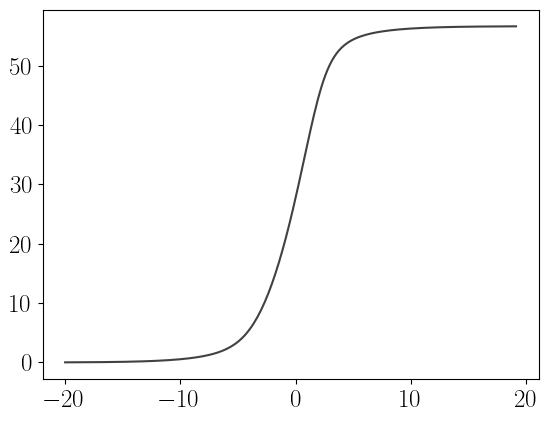

In [36]:
# density_expansion_nu
filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_veff_bord.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
mudensity = np.load(filename)

plt.plot(mudensity[0,:] , mudensity[1,:])

def save_as_tikz_table(x, y, filename="plot.table"):
    """
    Enregistre les listes x et y dans un fichier .table pour TikZ.
    Format :
    #Curve 0, N points
    #x y type
    x1 y1 i
    x2 y2 i
    ...
    """
    assert len(x) == len(y), "x et y doivent avoir la même longueur"
    n_points = len(x)

    with open(filename, "w") as f:
        f.write(f"#Curve 0, {n_points} points\n")
        f.write("#x y type\n")
        #f.write(f"{-9:.5f} {0:.5f} i\n")
        for xi, yi in zip(x, y):
            f.write(f"{xi:.5f} {yi:.5f} i\n")
        #f.write(f"{9:.5f} {0:.5f} i\n")

    print(f"✅ Fichier enregistré sous : {filename}")

save_as_tikz_table(mudensity[0,:]*8.8/20, mudensity[1,:]*5/56 , filename="density_coupure_1_sur_18.table")

save_as_tikz_table(mudensity[0,:]*8.8/20*Temp_bord, mudensity[1,:]*5/56 , filename="density_coupure_1_18.table")

In [15]:
import numpy as np

# Définir les constantes
hbar = 1.05457182e-25   # um^2.kg/ms
mass =  1.44e-25        # kg (masse du Rubidium 87)
kB = 1.380649e-26       # um^2.ms^-2.kg.nK^{-1}
a3D = 5.3e-3            # um
om_perp = 2 * np.pi * 2.56  # kHz (fréquence transverse)

# Calculer les constantes dérivées
g = 2 * hbar * a3D * om_perp        # force de répulsion effective 1D
c = mass / hbar**2 * g              # um^{-1}
gbar = g / hbar

print(gbar)

0.17050051649562528


In [16]:
import numpy as np
from scipy.linalg import solve
from scipy.interpolate import interp1d
from scipy.sparse import diags
from scipy.sparse.linalg import inv

# -------------------------------------------------------------------------------------
# Dressing of function f (given as array f_discr, occupation ratio given as n_discr)
# -------------------------------------------------------------------------------------

def f_varphimat(lam_discr, gb):
    L = len(lam_discr)
    def varphi(lam):
        return 2 * gb / (gb**2 + lam**2)
    
    varphimat = np.zeros((L, L))
    
    for i in range(L):
        for j in range(i + 1):
            value = varphi(lam_discr[i] - lam_discr[j])
            varphimat[i, j] = value
            varphimat[j, i] = value
    
    return varphimat

def f_dlam(lam_discr):
    L = len(lam_discr)
    dlam = np.zeros(L)
    for i in range(1, L - 1):
        dlam[i] = 0.5 * (lam_discr[i + 1] - lam_discr[i - 1])
    dlam[0] = 0.5 * (lam_discr[1] - lam_discr[0])
    dlam[-1] = 0.5 * (lam_discr[-1] - lam_discr[-2])
    return dlam

def dress(gb, lam_discr, n_discr, f_discr):
    varphimat = f_varphimat(lam_discr, gb)
    dlam = f_dlam(lam_discr)
    A = np.eye(len(lam_discr)) - (0.5 / np.pi) * varphimat @ np.diag(n_discr) @ np.diag(dlam)
    return solve(A, f_discr)

# -------------------------------------------------------------------------------------
# To evaluate charge density associated with function f
# -------------------------------------------------------------------------------------

def charge_density(gb, lam_discr, n_discr, f_discr):
    L = len(lam_discr)
    def varphi(lam):
        return 2 * gb / (gb**2 + lam**2)

    #lam_discr_g = np.linspace((lam_discr[0]*3 - lam_discr[-1])/2 , lam_discr[0], int(L/2))
    #lam_discr_d = np.linspace(lam_discr[-1], (lam_discr[-1]*3 - lam_discr[0])/2 int(L/2))
    #lam_discr_exp = np.concatenate([lam_discr_g ,lam_discr , lam_discr_d]) 
    #lam_discr_exp = np.linspace((lam_discr[0]*3 - lam_discr[-1])/2, (lam_discr[-1]*3 - lam_discr[0])/2,  2*L ))
    lam_discr_exp = np.linspace( lam_discr[0], lam_discr[-1]*2 - lam_discr[0],  2*L )
    varphimat = np.zeros((2*L, 2*L))
    for i in range(L):
        for j in range(i + 1):
            value = varphi(lam_discr[i] - lam_discr[j])
            varphimat[i, j] = value
            varphimat[j, i] = value
    
    dlam_exp = f_dlam(lam_discr_exp)
    zeros_array = np.array([0] * L)
    n_discr_exp = np.concatenate([n_discr, zeros_array], axis=0)
    A = np.eye(2*L) - (0.5 / np.pi) * varphimat @ np.diag(n_discr_exp) @ np.diag(dlam_exp)
    f_discr_exp = np.ones(2*L)
    dressed_f = solve(A, f_discr_exp)[:L]
    dlam = f_dlam(lam_discr)
    return (0.5 / np.pi) * np.dot(dlam, np.diag(n_discr) @ dressed_f)

# -------------------------------------------------------------------------------------
# Solve Yang-Yang equation
# -------------------------------------------------------------------------------------

def fun1(z):
    if z > 0:
        return np.log(1 + np.exp(-z))
    else:
        return np.log(1 + np.exp(z)) - z

def fun2(z):
    if z < 0:
        return 1 / (1 + np.exp(z))
    else:
        return np.exp(-z) / (1 + np.exp(-z))

def yangyang(gb, beta, lam_discr):
    L = len(lam_discr)
    def varphi(lam):
        return 2 * gb / (gb**2 + lam**2)
    
    varphimat = np.zeros((L, L))
    for i in range(L):
        for j in range(i + 1):
            value = varphi(lam_discr[i] - lam_discr[j])
            varphimat[i, j] = value
            varphimat[j, i] = value
    
    dlam = f_dlam(lam_discr)
    bare_E = 0.5 * beta[2] * lam_discr**2 + beta[1] * lam_discr + beta[0]
    eps = bare_E.copy()
    n = np.array([fun2(e) for e in eps])
    
    diff = 1.0
    while diff > 1e-12:
        old_n = n.copy()
        eps = bare_E - (0.5 / np.pi) * varphimat @ np.diag([fun1(e) for e in eps]) @ dlam
        n = np.array([fun2(e) for e in eps])
        diff = np.linalg.norm(n - old_n)
    
    eps = bare_E - (0.5 / np.pi) * varphimat @ np.diag([fun1(e) for e in eps]) @ dlam
    n = np.array([fun2(e) for e in eps])
    return n

import numpy as np
from scipy.interpolate import interp1d

def eval_density(x1, x2, gb, theta_tab, n_fun, ratio_m_hbar):
    L = len(x1)
    dens = np.zeros((2, 2 * L))  # Matrice de densité
    
    # Interpolation/extrapolation pour x2
    f2 = interp1d(x2, theta_tab, kind='linear', fill_value="extrapolate")
    
    # Interpolation/extrapolation pour x1
    f1 = interp1d(x1, theta_tab, kind='linear', fill_value="extrapolate")
    
    # La densité pour les premiers et derniers points est zéro
    dens[0, 0] = x1[0]
    dens[1, 0] = 0
    dens[0, L] = x2[-1]
    dens[1, L] = 0
    
    # Calcul des densités pour x1
    for j in range(1, L):  # Parcours de 1 à L-1 (équivalent Julia 2:L)
        thet1 = theta_tab[j]
        if x1[j] < x2[0]:
            thet2 = theta_tab[0]
        else:
            thet2 = f2(x1[j])
        
        lam_discr = np.linspace(thet2, thet1, 600)  # LinRange équivalent
        n_discr = n_fun(lam_discr)
        
        dens[0, j] = x1[j]
        dens[1, j] = ratio_m_hbar * charge_density(gb, lam_discr, n_discr, np.ones(len(lam_discr)))
    
    # Calcul des densités pour x2 sans symétrie
    for j in range(L - 1):  # Parcours de 0 à L-2 (équivalent Julia 1:L-1)
        thet1 = theta_tab[j]
        if x2[j] > x1[-1]:
            thet2 = theta_tab[-1]
        else:
            thet2 = f1(x2[j])
        
        lam_discr = np.linspace(thet1, thet2, 600)  # LinRange équivalent
        n_discr = n_fun(lam_discr)
        
        dens[0, 2 * L - 1 - j] = x2[j]
        dens[1, 2 * L - 1 - j] = ratio_m_hbar * charge_density(gb, lam_discr, n_discr, np.ones(len(lam_discr)))
    
    # Trier les densités selon les positions
    sorted_indices = np.argsort(dens[0, :])
    dens_sorted = dens[:, sorted_indices]
    
    return dens_sorted

import numpy as np

def eval_edge_density(x, gb, theta_tab, nu_fun, ratio_m_hbar):
    npts_integral = 600

    L = len(x)
    dens = np.zeros((2, L))
    dens[0, 0] = x[0]
    dens[1, 0] = 0
    thet1 = theta_tab[0]

    for j in range(1, L):
        thet1 = theta_tab[j]
        thet2 = theta_tab[0]
        lam_discr = np.linspace(thet2, thet1, npts_integral)
        nu_discr = np.array([nu_fun(lam) for lam in lam_discr])
        dens[0, j] = x[j]
        dens[1, j] = ratio_m_hbar * charge_density(gb, lam_discr, nu_discr, np.ones(len(lam_discr)))

    print("la densité haute est :", dens[1, -1])

    # tri selon les positions x
    indices_sorted = np.argsort(dens[0, :])
    return dens[:, indices_sorted]


In [17]:
import numpy as np
from scipy.interpolate import interp1d

index_last_underscore = nom2.rfind('_')
theta_discr = np.load(f"{date}/theta_discr_{nom2[index_last_underscore+1:]}.npz")

filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_veff_bord.npz"
print ( 'filename =' ,filename )
x_bord , y_bord = np.load(filename)

Temp_bord = 18

# Fonction d'interpolation linéaire
def LinearInterpolation(x, y):
    return interp1d(x, y, kind='linear', fill_value="extrapolate")

# Interpolation linéaire
x_fun = LinearInterpolation(theta_discr, x_bord)  # Unité (µm/ms)
theta_fun = LinearInterpolation(x_bord, theta_discr)

# Calcul des limites x1 et x2
x_1 = (x0 - Taille / 2) / Temp_bord
x_2 = (x0 + Taille / 2) / Temp_bord

# Calcul des valeurs theta_1 et theta_2
theta_1 = theta_fun(x_1)
theta_2 = theta_fun(x_2)

# Calcul du maximum de |theta_1| et |theta_2|
max_abs_theta = max(20, abs(theta_1), abs(theta_2))

# Génération des bords pour theta_bord1 et theta_bord2
theta_bord1 = np.linspace(-max_abs_theta, theta_1, 100)
x1_bord1 = np.full(theta_bord1.shape, x_1)

# Génération de theta_bord2 et calcul de x1_bord2
theta_bord2 = np.linspace(theta_1 + 0.0000001, theta_2, 100)
L = len(theta_bord2)
x1_bord2 = np.zeros(L)

for i in range(L):
    x1_bord2[i] = x_fun(theta_bord2[i])

# Concaténation des bords pour theta_discr et x1
theta_discr_exp = np.concatenate([theta_bord1, theta_bord2], axis=0)
x1 = np.concatenate([x1_bord1, x1_bord2], axis=0) * Temp_bord/ Taille

# Calcul de x2
x2 = np.full(theta_discr.shape, x_2) * Temp_bord/ Taille

# Affichage des résultats (facultatif)
#print("theta_discr_exp:", theta_discr_exp)
#print("x1:", x1)
#print("x2:", x2)


filename = 2025-01-27/density_expansion_nu_theta_edge_1.0_ih1_64.676_559.424_veff_bord.npz


In [18]:
import numpy as np

def integ(x, y, tab, axes=(0,)):
    """
    Calcule l'intégrale discrète sur une ou plusieurs dimensions.

    Parameters:
    - x: numpy array, coordonnées discrètes de la première dimension.
    - y: numpy array, coordonnées discrètes de la deuxième dimension (ou autre).
    - tab: numpy array, tableau de valeurs à intégrer.
    - axes: tuple of int, axes sur lesquels effectuer l'intégration.

    Returns:
    - Résultat de l'intégration (scalaire ou tableau réduit).
    """
    # Assurez-vous que les axes sont sous forme de tuple
    if isinstance(axes, int):
        axes = (axes,)

    # Intégration séquentielle sur les axes spécifiés
    result = tab.copy()
    for axis in sorted(axes):
        if axis == 0:
            dx = np.diff(x)  # Différences des x
            weights = np.append(dx, dx[-1])  # Ajouter le dernier poids pour le bord
            result = np.sum(result * weights[:, None], axis=axis)  # Poids le long de l'axe 0
        elif axis == 1:
            dy = np.diff(y)  # Différences des y
            weights = np.append(dy, dy[-1])  # Ajouter le dernier poids pour le bord
            result = np.sum(result * weights[None, :], axis=axis)  # Poids le long de l'axe 1

    return result
    
filename = f"{date}/bord1_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
bord1 = np.load(filename)
filename = f"{date}/bord2_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
bord2 = np.load(filename)

def f_mat_nu_bord(v , theta , veff_bord_discr = veff_bord_discr , theta_discr = theta_discr , nu = nu0 , v1 = bord1*Taille/Temp_bord , v2 = bord2*Taille/Temp_bord , theta_discr_exp = theta_discr_exp ) :
    
    import numpy as np
    from scipy.interpolate import RegularGridInterpolator
    from scipy.interpolate import interp1d
    
    f_nu = interp1d(theta_discr, nu , kind='linear', bounds_error=False, fill_value="extrapolate")
    f_theta_discr_exp_1 = interp1d(v1, theta_discr_exp, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_theta_discr_exp_2 = interp1d(v2, theta_discr_exp, kind='linear', bounds_error=False, fill_value="extrapolate")

    v_min = min(np.min ( v1 ) ,np.min ( v2)) 
    v_max = min(np.max ( v1 ) ,np.max ( v2))

    if v < v_min or v > v_max : return 0

    theta_min = min(theta_discr)
    theta_max = f_theta_discr_exp_1(v)
    if v < min(v2)  :        
        if theta > theta_max : return 0 
        return f_nu(theta) 
    else : 
        theta_min = f_theta_discr_exp_2(v)
        theta_min = f_theta_discr_exp_2(v)
        if (theta < theta_min) or (theta > theta_max) : return 0 
        return f_nu(theta) 

filename = 2025-01-27/bord1_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz
filename = 2025-01-27/bord2_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz


7.570720817562863
✅ Fichier enregistré sous : insitut_rho.table


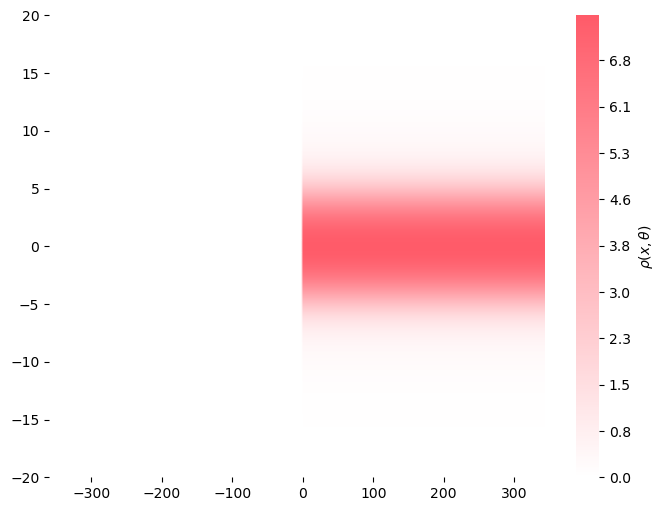

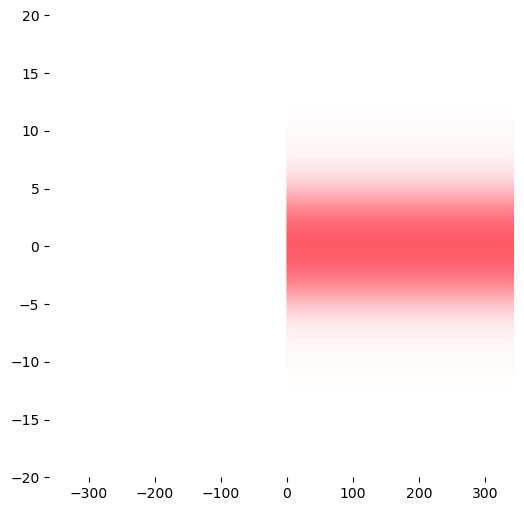

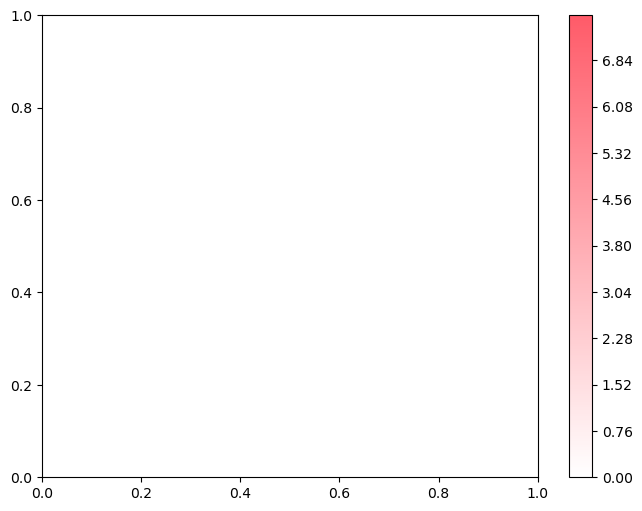

In [19]:
# rho avans deformation 

filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_{0:.3f}.npz" 
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
mydensity = np.load(filename)

#save_as_tikz_table(mydensity[0,:]*8.8/350, theta_discr*8.8/20, filename="bord_0_0.table")
rho0 = 0.5 / np.pi * nu0* mass/hbar* dress(gbar, theta_discr, nu0, np.ones(len(theta_discr)))
# Définir vmin et vmax pour la colorbar

print(max(rho0))
save_as_tikz_table(theta_discr*8.8/20, rho0*5/max(rho0), filename="insitut_rho.table")

vmin = 0
vmax = max(rho0)

# Créer les maillages X et Y
X, Y = np.meshgrid(veff_bord_discr * Temp_bord, theta_discr)

# Définir les niveaux pour un contour plus continu
nb_levels = 1000

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 6))

# Créer un graphique de contours
cf = ax.contourf(X, Y, np.array([rho0 if v > 0 else np.zeros(len(rho0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax.plot(mydensity[0,:] ,theta_discr , color="#F6DEB8", linewidth=4 , alpha = 0.5 ) 



# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajouter la barre de couleur avec 1 décimale
cbar = plt.colorbar(cf, ax=ax, label=r'$\rho(x,\theta)$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarder le graphique complet avec les axes et la colorbar
fig.savefig("complete_graph_coupure_rho_1_0.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder les axes sans le graphique ni la colorbar
fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, np.array([rho0 if v > 0 else np.zeros(len(rho0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax_axes.set_axis_off()  # Masquer les axes
#ax_axes.plot(mydensity[0,:] ,theta_discr , color="#F6DEB8", linewidth=4 , linestyle='-.',  alpha = 0.4 ) 
# Supprimer les traits noirs autour de la figure
for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_coupure_rho_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder la colorbar seule
fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_coupure_rho_1_0_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Afficher la figure
plt.show()#

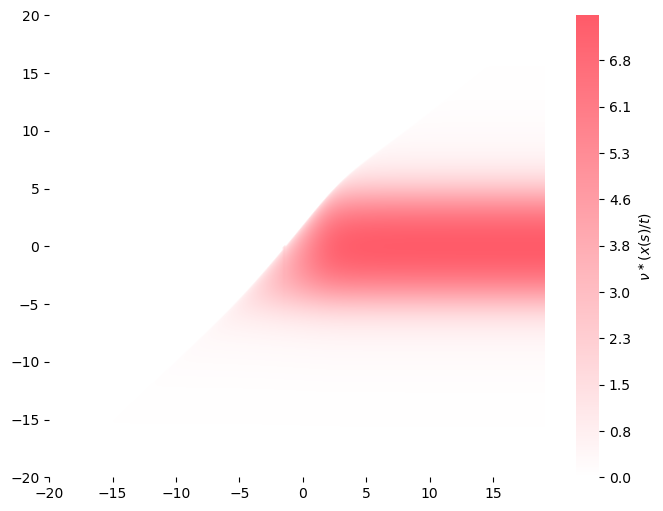

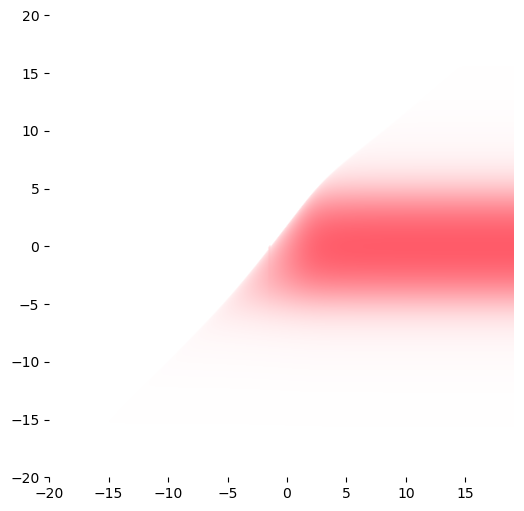

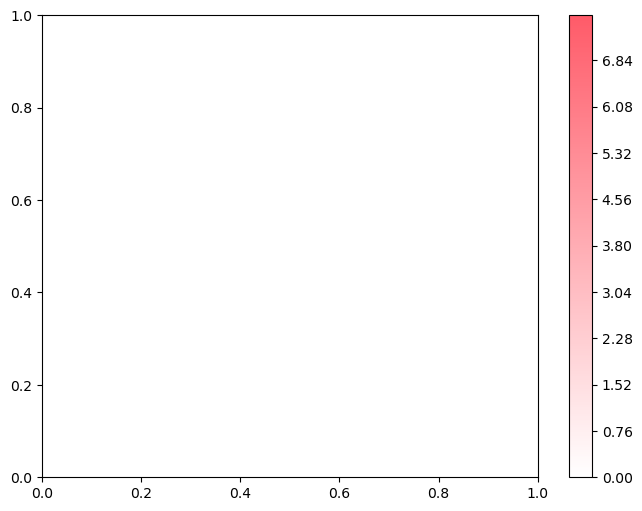

✅ Fichier enregistré sous : coupure_rho_1_sur_18.table
3.1920263799915936
✅ Fichier enregistré sous : coupure_rho_1_sur_18.table
(200,)
[0.00409362 0.00447164 0.00485051 0.00524615 0.00566647 0.00611509
 0.00659461 0.00710737 0.0076557  0.00824198 0.0088687  0.00953851
 0.0102542  0.01101875 0.01183531 0.01270728 0.01363826 0.01463212
 0.01569301 0.01682537 0.01803399 0.01932403 0.02070104 0.02217101
 0.02374045 0.02541638 0.02720645 0.02911898 0.03116303 0.03334849
 0.03568621 0.03818807 0.04086715 0.04373785 0.04681608 0.05011946
 0.05366756 0.05748214 0.06158752 0.06601088 0.07078275 0.07593748
 0.08151383 0.08755572 0.09411297 0.10124237 0.10900877 0.11748647
 0.12676087 0.13693036 0.14810862 0.1604273  0.17403917 0.18912184
 0.20588198 0.22456019 0.24543652 0.26883642 0.29513707 0.32477382
 0.35824598 0.39612138 0.43903845 0.48770419 0.54288629 0.60539694
 0.67606633 0.75570386 0.84504634 0.94469441 1.05504067 1.17619635
 1.30792604 1.44960115 1.60018265 1.7582399  1.92200704 2.08

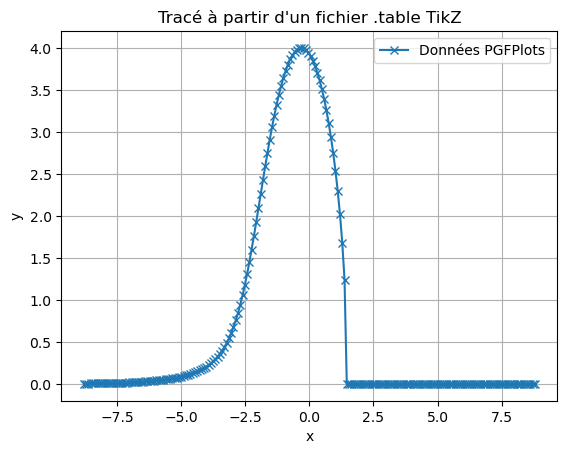

In [28]:
# rho apres deformation bord 
filename = f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_veff_bord.npz" 
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
mydensity = np.load(filename)

##print ( "max" , max(mydensity[0,:]) , max(theta_discr) ) 

#save_as_tikz_table(mydensity[0,:]*8.63/max(mydensity[0,:]), theta_discr*8.8/max(theta_discr), filename="bord_0_sur_18.table")

# Définir vmin et vmax pour la colorbar
import numpy as np
from scipy.interpolate import interp1d
# Fonction d'interpolation linéaire
def LinearInterpolation(x, y):
    return interp1d(x, y, kind='linear', fill_value="extrapolate")
    
theta_veff_fun = LinearInterpolation(veff_bord_discr, theta_discr) 
nu_fun = LinearInterpolation(theta_discr , nu0)
#mat_nu = np.array([ np.where(  theta_discr <theta_veff_fun(v),  nu0 , 0 ) for v in veff_bord_discr])
#mat_rho = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr, nu, np.ones(len(theta_discr))) for nu in mat_nu]  )


vmin = 0
vmax = max(rho0)

# Créer les maillages X et Y
X, Y = np.meshgrid(veff_bord_discr , theta_discr)

# Définir les niveaux pour un contour plus continu
nb_levels = 1000

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 6))

# Créer un graphique de contours
cf = ax.contourf(X, Y, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)

# Supprimer les traits noirs autour de la figure
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajouter la barre de couleur avec 1 décimale
cbar = plt.colorbar(cf, ax=ax, label=r'$\nu^\ast(x(s)/t)$')
cbar.outline.set_visible(False)
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

# Sauvegarder le graphique complet avec les axes et la colorbar
fig.savefig("complete_graph_coupure_rho_1_18.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder les axes sans le graphique ni la colorbar
fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
ax_axes.contourf(X, Y, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
#ax_axes.set_axis_off()  # Masquer les axes
# Supprimer les traits noirs autour de la figure
for spine in ax_axes.spines.values():
    spine.set_visible(False)
fig_axes.savefig("graph_coupure_rho_1_18_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Sauvegarder la colorbar seule
fig_cbar, ax_cbar = plt.subplots(figsize=(8, 6))
cbar = plt.colorbar(cf, ax=ax_cbar)
fig_cbar.savefig("colorbar_coupure_rho_1_18_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

# Afficher la figure
plt.show()


save_as_tikz_table(theta_discr*8.8/20, np.array([rho0[i] if theta < 5/2.23*2 else 0 for i, theta in enumerate(theta_discr)])*5/max(rho0) , filename="coupure_rho_1_sur_18.table")
filename = f"{date}/{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_star = np.load(filename)
print(theta_star)

save_as_tikz_table(theta_discr*8.8/20, np.array([rho0[i] if theta < theta_star else 0 for i, theta in enumerate(theta_discr)])*5/max(rho0) , filename="coupure_rho_1_sur_18.table")


nu18 = np.array([nu0[i] if theta < theta_star else 0 for i, theta in enumerate(theta_discr)])
rho18 = 0.5 / np.pi * nu18 * mass/hbar* dress(gbar, theta_discr, nu18 , np.ones(len(theta_discr)))
print(rho18.shape)
print(rho18*5/max(rho0))
save_as_tikz_table(theta_discr*8.8/20, rho18*5/max(rho0) , filename="coupure_rho_1_sur_18.table")


read_and_plot_table(filename="coupure_rho_1_sur_18.table")#

[True, False, False, False, False, False, False]
filename = 2025-01-27/bord1_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz
filename = 2025-01-27/bord2_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz


Locator attempting to generate 1001 ticks ([-9.999999999999999e-14, ..., 1e-13]), which exceeds Locator.MAXTICKS (1000).


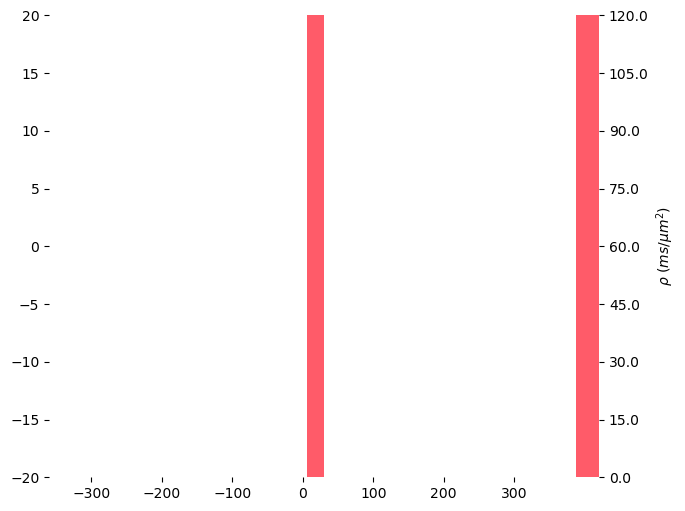

Locator attempting to generate 1001 ticks ([-9.999999999999999e-14, ..., 1e-13]), which exceeds Locator.MAXTICKS (1000).


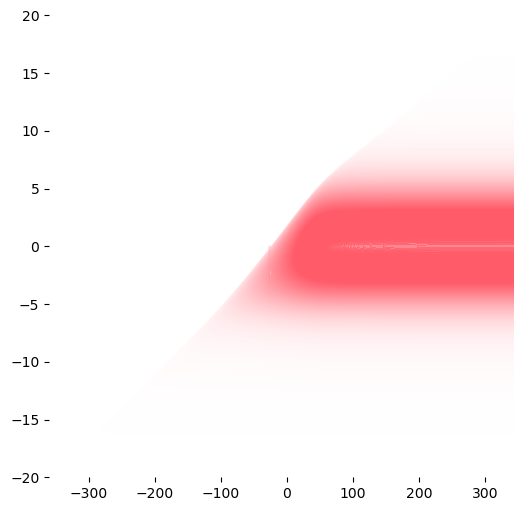

✅ Fichier enregistré sous : density_coupure_2_0.table
✅ Fichier enregistré sous : Pi_coupure_2_0.table
filename = 2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz
✅ Fichier enregistré sous : rho_coupure_2_0.table
✅ Fichier enregistré sous : rho_coupure_2_0_p.table


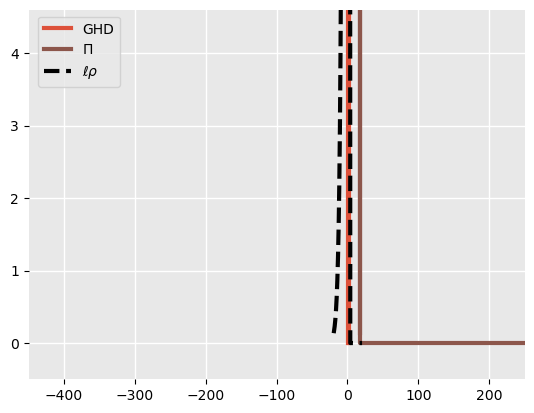

In [29]:
import numpy as np
PI , GHD , N  = [] , [] , [] 
liste_t = np.array([0.000 , 1.000 , 10.000 , 11.000 , 20.000 , 21.000 , 30.000 ])
mask = (liste_t >= 0) & (liste_t <= 30)
mask = [ t in np.array([0.000]) for t in liste_t ]
print(mask)

##mat_nu_1 = np.array([
#        np.array([f_mat_nu_bord(v, theta , v1 = veff_bord_discr_exp_2 , v2 =  0.00001*theta_discr_exp +veff_bord_discr_exp_2[-1]   ) for theta in theta_discr_exp_2])
#        for v in veff_bord_discr_exp_2
#    ]) 

mat_rho = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr, nu, np.ones(len(theta_discr))) for nu in mat_nu ]  )

# theta_discr_exp
filename = f"{date}/theta_discr_exp_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp = np.load(filename)
Temps_exp = 30

for t in liste_t[mask] :
    filename = f"{date}/bord1_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord1 = np.load(filename)
    filename = f"{date}/bord2_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord2 = np.load(filename)

    #save_as_tikz_table(bord1*Taille*8.63/max(veff_bord_discr*Temp_bord), theta_discr_exp*8.8/max(theta_discr), filename="bord_1_0.table")
    #save_as_tikz_table(bord2*Taille*8.63/max(veff_bord_discr*Temp_bord), theta_discr_exp*8.8/max(theta_discr), filename="bord_2_0.table")
    
    veff_bord_discr_exp_2 = np.linspace(min(bord1[0] , bord2[0]) , max(bord2[-1] , bord1[-1]), 200)*Taille/Temp_bord
    theta_discr_exp_2 = np.linspace(theta_discr[0] , theta_discr[-1], 600)
    mat_nu_bord = np.array([
        np.array([f_mat_nu_bord(v, theta , v1 = bord1*Taille/Temp_bord , v2 = bord2*Taille/Temp_bord ) for theta in theta_discr_exp_2])
        for v in veff_bord_discr_exp_2
    ])  
    #vmin=0
    #vmax=1
    # Créer les maillages X et Y
    Xb, Yb = np.meshgrid(veff_bord_discr*Temp_bord , theta_discr)

    X0, Y0 = np.meshgrid(veff_bord_discr*Temp_bord, theta_discr)
    #plt.contourf( X0, Y0,   np.array([nu0 for v in veff_bord_discr]).T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    #plt.contourf( X0, Y0,   mat_nu.T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    X, Y = np.meshgrid(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2)
    #plt.contourf( X, Y,   mat_nu_bord.T, cmap='viridis' , vmin=vmin, vmax=vmax, alpha = 0.5)
    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.show()

    #plt.plot(veff_bord_discr*Temp_bord , theta_veff_fun(veff_bord_discr) , label = "veff" )
    
    #plt.plot(bord1*Taille, theta_discr_exp)
    #plt.plot(bord2*Taille , theta_discr_exp)
    #plt.plot(np.concatenate([bord1, np.flip(bord2)] , axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    #plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    mat_rho_bord = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr_exp_2, nu, np.ones(len(theta_discr_exp_2))) for nu in mat_nu_bord ]  )
    nb_levels = 1000
    vmin, vmax = 0 , 5.6#*Taille

    # Créer un graphique de contours
    #mat_nu
    cf = ax.contourf(Xb, Yb, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.5)
    cf0 = ax.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    #cf0 = ax.contourf(X0, Y0, mat_rho.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.2)
    cf = ax.contourf( X, Y,   mat_rho_bord.T*Taille, cmap=custom_cmap , vmin=vmin, vmax=vmax , alpha = 1)

    # Supprimer les traits noirs autour de la figure
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Ajouter la barre de couleur avec 1 décimale
    cbar = plt.colorbar(cf, ax=ax, label=r'$\rho~ (ms/\mu m^2)$')
    cbar.outline.set_visible(False)
    cbar.formatter = FormatStrFormatter('%.1f')
    cbar.update_ticks()
    
    # Sauvegarder le graphique complet avec les axes et la colorbar
    fig.savefig(f"complete_graph_coupure_2_{t:.0f}_p.pdf", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    
    # Sauvegarder les axes sans le graphique ni la colorbar
    fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
    ax_axes.contourf(X0, Y0, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    ax_axes.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.7)    
    #ax_axes.contourf(X0, Y0, mat_rho.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.2)    
    #ax_axes.contourf(X, Y, mat_rho_bord.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    ax_axes.contourf(Xb, Yb, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.7)
    #ax_axes.set_axis_off()  # Masquer les axes
    # Supprimer les traits noirs autour de la figure
    for spine in ax_axes.spines.values():
        spine.set_visible(False)
    fig_axes.savefig(f"graph_coupure_2_{t:.0f}_only_p.pdf", dpi=300, bbox_inches='tight', transparent=True)

    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.plot(np.concatenate([bord1, np.flip(bord2)], axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    plt.show()





    #Pi = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,))
    #Ghd = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(1,))
    #nat = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,1))

    #PI.append(Pi)
    #GHD.append(Ghd)
    #N.append(nat)

    #plt.plot(theta_discr_exp_2 , Pi , label = f"Pi : {t:.3f}") 
    #for i , rho in enumerate(mat_rho_bord) :
    #    plt.plot(theta_discr_exp_2 , rho , label = f"rho : {i:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"$ms/\mu m$")
    #plt.legend()
    #plt.show()

    #plt.plot(veff_bord_discr_exp_2 , Ghd , label = f"GHD : {t:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()

    #plt.plot(theta_discr_exp_2*liste_t[-1]+x0, PI[0]/liste_t[-1] , label = f"Pi : {0:.3f}") 
    #plt.plot(veff_bord_discr_exp_2*Temp_bord, Ghd , label = f"Ghd : {t:.3f}") 
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()

    
    fig, ax1 = plt.subplots()
    
    label = r"GHD"
    filename = f"{date}/density_expansion_nu_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    density = np.load(filename)    
    # Créer un nouvel intervalle allant de 0 à 400
    #x_new = np.linspace(max(density[0, :] * Taille) , 400, 100)  # 100 points entre 0 et 400
    #y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    # Concaténer avec tes données existantes
    x_combined = density[0, :] * Taille/Temp_bord # np.concatenate([density[0, :] * Taille  , x_new])
    y_combined = density[1, :]# np.concatenate([density[1, :] , y_new])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/56 , filename=f"density_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined, y_combined, linewidth=3, color=plt.cm.inferno(0.6), alpha=1,
         label=label)
    
    label = r"$\Pi$"
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
       
    x_new = np.linspace(max(theta_discr_exp*t +x0) , 400, 100)  # 100 points entre 0 et 400
    y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    filename = f"{date}/Pi_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    Pi_0 = np.load(filename) * Taille
    # Concaténer avec tes données existantes
    x_combined = np.concatenate([theta_discr_exp*t +x0, x_new])
    y_combined = np.concatenate([Pi_0, y_new])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/56 , filename=f"Pi_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined,  y_combined, linewidth=3, color="#8c564b",alpha=1, 
             label=label)

    
    label = r"$\ell\rho$"
    
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
    filename = f"{date}/rho_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    filename = f"{date}/rho_bon_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    rho_theta_star_discr = np.load(filename)['arr_0']
    
    filename = f"{date}/theta_discr_exp_2_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #filename = '2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz' 
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    theta_discr_exp_2 = np.load(filename)['arr_0']
       
    #theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
    theta0 =  x0/Temps_exp

    save_as_tikz_table((theta_discr_exp_2+theta0)*8.8/20, rho_theta_star_discr*Taille*5/56 , filename=f"rho_coupure_2_{t:.0f}.table")
    
    save_as_tikz_table((theta_discr+theta0)*8.8/20, mat_rho[-1]*Taille*5/56 , filename=f"rho_coupure_2_{t:.0f}_p.table")

    ax1.plot(theta_discr_exp_2+theta0, 
             rho_theta_star_discr*Taille , 
             linewidth=3 , 
             linestyle='--',
             alpha=1,
             color = "black",#"#bcbd22", 
             label=label)
    
    plt.ylim([-0.5 , 4.6 ])
    plt.xlim([-450, 250 ])    
    plt.grid(True)
    #plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    #plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    # Personnalisation de la légende
    ax1.legend(
        #loc='upper left',             # Position de la légende
        loc='upper left',
        #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
        #loc='best', 
        bbox_to_anchor=(0.005, 1),
        #fancybox=False,                  # Ajouter une bordure arrondie
        #shadow=False,                    # Ajouter une ombre
        #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
        #fontsize=police,                    # Taille de la police
        #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
        facecolor='#e8e8e8',                  # Couleur de fond de la légende
        #edgecolor='black',              # Couleur du bord de la légende
        #title='Légende de l\'expérience', # Titre de la légende
        #title_fontsize='large',         # Taille de la police du titre
        #labelspacing=0.1,               # Espacement entre les labels de la légende
        #handlelength=0.5,               # Longueur des poignées des items de la légende
        #handleheight=1.5,               # Hauteur des poignées des items de la légende
        #columnspacing=0,               # Espacement entre les colonnes
        #alignment = 'right',
    )
    plt.grid(color='white', linestyle='-', linewidth=1)
    # Rendre le cadre invisible
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Appliquer un fond gris
    #plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas
    
    
    # Appliquer un fond gris clair au graphe
    #plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
    plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
    plt.savefig('Figures/article_distribution_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
    plt.savefig('Figures/article_distribution_24-04-2024.svg', bbox_inches='tight', dpi = 300)
    plt.show()

[True, False, False, False, False, False, False]
filename = 2025-01-27/bord1_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz
filename = 2025-01-27/bord2_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz
✅ Fichier enregistré sous : bord_1_0.table
✅ Fichier enregistré sous : bord_2_0.table


Locator attempting to generate 1001 ticks ([-9.999999999999999e-14, ..., 1e-13]), which exceeds Locator.MAXTICKS (1000).


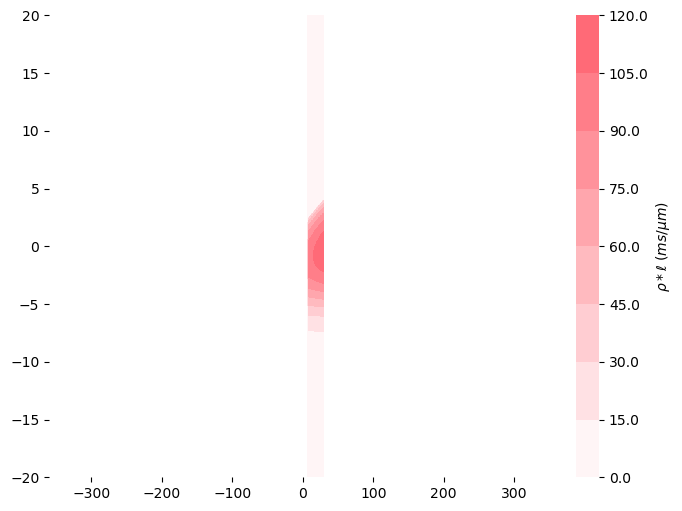

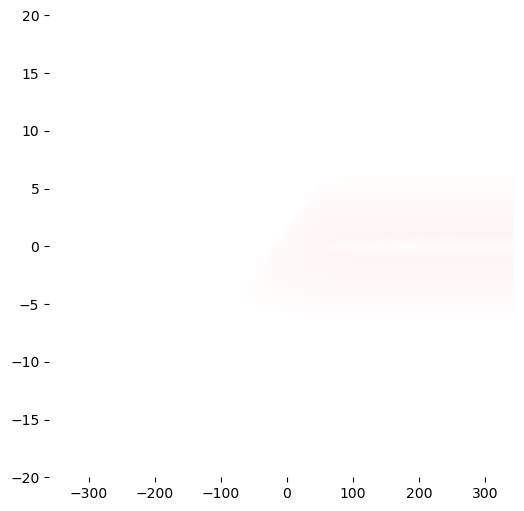

✅ Fichier enregistré sous : density_coupure_2_0.table
✅ Fichier enregistré sous : Pi_coupure_2_0.table
filename = 2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz
✅ Fichier enregistré sous : rho_coupure_2_0.table


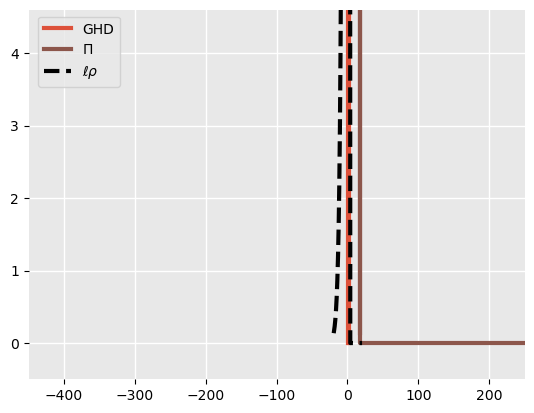

In [30]:
import numpy as np
PI , GHD , N  = [] , [] , [] 
liste_t = np.array([0.000 , 1.000 , 10.000 , 11.000 , 20.000 , 21.000 , 30.000 ])
mask = (liste_t >= 0) & (liste_t <= 30)
mask = [ t in np.array([0.000]) for t in liste_t ]
print(mask)

##mat_nu_1 = np.array([
#        np.array([f_mat_nu_bord(v, theta , v1 = veff_bord_discr_exp_2 , v2 =  0.00001*theta_discr_exp +veff_bord_discr_exp_2[-1]   ) for theta in theta_discr_exp_2])
#        for v in veff_bord_discr_exp_2
#    ]) 

mat_rho = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr, nu, np.ones(len(theta_discr))) for nu in mat_nu ]  )

# theta_discr_exp
filename = f"{date}/theta_discr_exp_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp = np.load(filename)
Temps_exp = 30

for t in liste_t[mask] :
    filename = f"{date}/bord1_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord1 = np.load(filename)
    filename = f"{date}/bord2_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord2 = np.load(filename)

    save_as_tikz_table(bord1*Taille*8.63/max(veff_bord_discr*Temp_bord), theta_discr_exp*8.8/max(theta_discr), filename="bord_1_0.table")
    save_as_tikz_table(bord2*Taille*8.63/max(veff_bord_discr*Temp_bord), theta_discr_exp*8.8/max(theta_discr), filename="bord_2_0.table")
    
    veff_bord_discr_exp_2 = np.linspace(min(bord1[0] , bord2[0]) , max(bord2[-1] , bord1[-1]), 200)*Taille/Temp_bord
    theta_discr_exp_2 = np.linspace(theta_discr[0] , theta_discr[-1], 600)
    mat_nu_bord = np.array([
        np.array([f_mat_nu_bord(v, theta , v1 = bord1*Taille/Temp_bord , v2 = bord2*Taille/Temp_bord ) for theta in theta_discr_exp_2])
        for v in veff_bord_discr_exp_2
    ])  
    #vmin=0
    #vmax=1
    X0, Y0 = np.meshgrid(veff_bord_discr*Temp_bord, theta_discr)
    #plt.contourf( X0, Y0,   np.array([nu0 for v in veff_bord_discr]).T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    #plt.contourf( X0, Y0,   mat_nu.T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    X, Y = np.meshgrid(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2)
    #plt.contourf( X, Y,   mat_nu_bord.T, cmap='viridis' , vmin=vmin, vmax=vmax, alpha = 0.5)
    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.show()

    #plt.plot(veff_bord_discr*Temp_bord , theta_veff_fun(veff_bord_discr) , label = "veff" )
    
    #plt.plot(bord1*Taille, theta_discr_exp)
    #plt.plot(bord2*Taille , theta_discr_exp)
    #plt.plot(np.concatenate([bord1, np.flip(bord2)] , axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    #plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    mat_rho_bord = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr_exp_2, nu, np.ones(len(theta_discr_exp_2))) for nu in mat_nu_bord ]  )
    nb_levels = 1000
    vmin, vmax = 0 , 5.6*Taille

    # Créer un graphique de contours
    #cf0 = ax.contourf(X0, Y0, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    cf0 = ax.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    #cf0 = ax.contourf(X0, Y0, mat_rho.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.2)
    cf = ax.contourf( X, Y,   mat_rho_bord.T*Taille, cmap=custom_cmap , vmin=vmin, vmax=vmax , alpha = 1)

    # Supprimer les traits noirs autour de la figure
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Ajouter la barre de couleur avec 1 décimale
    cbar = plt.colorbar(cf, ax=ax, label=r'$\rho*\ell~ (ms/\mu m)$')
    cbar.outline.set_visible(False)
    cbar.formatter = FormatStrFormatter('%.1f')
    cbar.update_ticks()
    
    # Sauvegarder le graphique complet avec les axes et la colorbar
    fig.savefig(f"complete_graph_coupure_2_{t:.0f}_p.pdf", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    
    # Sauvegarder les axes sans le graphique ni la colorbar
    fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
    ax_axes.contourf(X0, Y0, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    #ax_axes.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)    
    #ax_axes.contourf(X0, Y0, mat_rho.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.2)    
    #ax_axes.contourf(X, Y, mat_rho_bord.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    #ax_axes.set_axis_off()  # Masquer les axes
    # Supprimer les traits noirs autour de la figure
    for spine in ax_axes.spines.values():
        spine.set_visible(False)
    fig_axes.savefig(f"graph_coupure_2_{t:.0f}_only_p.pdf", dpi=300, bbox_inches='tight', transparent=True)

    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.plot(np.concatenate([bord1, np.flip(bord2)], axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    plt.show()





    #Pi = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,))
    #Ghd = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(1,))
    #nat = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,1))

    #PI.append(Pi)
    #GHD.append(Ghd)
    #N.append(nat)

    #plt.plot(theta_discr_exp_2 , Pi , label = f"Pi : {t:.3f}") 
    #for i , rho in enumerate(mat_rho_bord) :
    #    plt.plot(theta_discr_exp_2 , rho , label = f"rho : {i:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"$ms/\mu m$")
    #plt.legend()
    #plt.show()

    #plt.plot(veff_bord_discr_exp_2 , Ghd , label = f"GHD : {t:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()

    #plt.plot(theta_discr_exp_2*liste_t[-1]+x0, PI[0]/liste_t[-1] , label = f"Pi : {0:.3f}") 
    #plt.plot(veff_bord_discr_exp_2*Temp_bord, Ghd , label = f"Ghd : {t:.3f}") 
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()

    
    fig, ax1 = plt.subplots()
    
    label = r"GHD"
    filename = f"{date}/density_expansion_nu_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    density = np.load(filename)    
    # Créer un nouvel intervalle allant de 0 à 400
    #x_new = np.linspace(max(density[0, :] * Taille) , 400, 100)  # 100 points entre 0 et 400
    #y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    # Concaténer avec tes données existantes
    x_combined = density[0, :] * Taille/Temp_bord # np.concatenate([density[0, :] * Taille  , x_new])
    y_combined = density[1, :]# np.concatenate([density[1, :] , y_new])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/56 , filename=f"density_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined, y_combined, linewidth=3, color=plt.cm.inferno(0.6), alpha=1,
         label=label)
    
    label = r"$\Pi$"
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
       
    x_new = np.linspace(max(theta_discr_exp*t +x0) , 400, 100)  # 100 points entre 0 et 400
    y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    filename = f"{date}/Pi_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    Pi_0 = np.load(filename) * Taille
    # Concaténer avec tes données existantes
    x_combined = np.concatenate([theta_discr_exp*t +x0, x_new])
    y_combined = np.concatenate([Pi_0, y_new])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/56 , filename=f"Pi_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined,  y_combined, linewidth=3, color="#8c564b",alpha=1, 
             label=label)

    
    label = r"$\ell\rho$"
    
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
    filename = f"{date}/rho_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    filename = f"{date}/rho_bon_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    rho_theta_star_discr = np.load(filename)['arr_0']
    
    filename = f"{date}/theta_discr_exp_2_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #filename = '2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz' 
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    theta_discr_exp_2 = np.load(filename)['arr_0']
       
    #theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
    theta0 =  x0/Temps_exp

    save_as_tikz_table((theta_discr_exp_2+theta0)*8.8/20, rho_theta_star_discr*Taille*5/56 , filename=f"rho_coupure_2_{t:.0f}.table")
    
    ax1.plot(theta_discr_exp_2+theta0, 
             rho_theta_star_discr*Taille , 
             linewidth=3 , 
             linestyle='--',
             alpha=1,
             color = "black",#"#bcbd22", 
             label=label)
    
    plt.ylim([-0.5 , 4.6 ])
    plt.xlim([-450, 250 ])    
    plt.grid(True)
    #plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    #plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    # Personnalisation de la légende
    ax1.legend(
        #loc='upper left',             # Position de la légende
        loc='upper left',
        #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
        #loc='best', 
        bbox_to_anchor=(0.005, 1),
        #fancybox=False,                  # Ajouter une bordure arrondie
        #shadow=False,                    # Ajouter une ombre
        #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
        #fontsize=police,                    # Taille de la police
        #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
        facecolor='#e8e8e8',                  # Couleur de fond de la légende
        #edgecolor='black',              # Couleur du bord de la légende
        #title='Légende de l\'expérience', # Titre de la légende
        #title_fontsize='large',         # Taille de la police du titre
        #labelspacing=0.1,               # Espacement entre les labels de la légende
        #handlelength=0.5,               # Longueur des poignées des items de la légende
        #handleheight=1.5,               # Hauteur des poignées des items de la légende
        #columnspacing=0,               # Espacement entre les colonnes
        #alignment = 'right',
    )
    plt.grid(color='white', linestyle='-', linewidth=1)
    # Rendre le cadre invisible
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Appliquer un fond gris
    #plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas
    
    
    # Appliquer un fond gris clair au graphe
    #plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
    plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
    plt.savefig('Figures/article_distribution_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
    plt.savefig('Figures/article_distribution_24-04-2024.svg', bbox_inches='tight', dpi = 300)
    plt.show()

[False, False, False, False, False, False, True]
filename = 2025-01-27/bord1_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_30.000.npz
filename = 2025-01-27/bord2_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_30.000.npz
✅ Fichier enregistré sous : bord_1_30.table
✅ Fichier enregistré sous : bord_2_30.table


Locator attempting to generate 1001 ticks ([-9.999999999999999e-14, ..., 1e-13]), which exceeds Locator.MAXTICKS (1000).


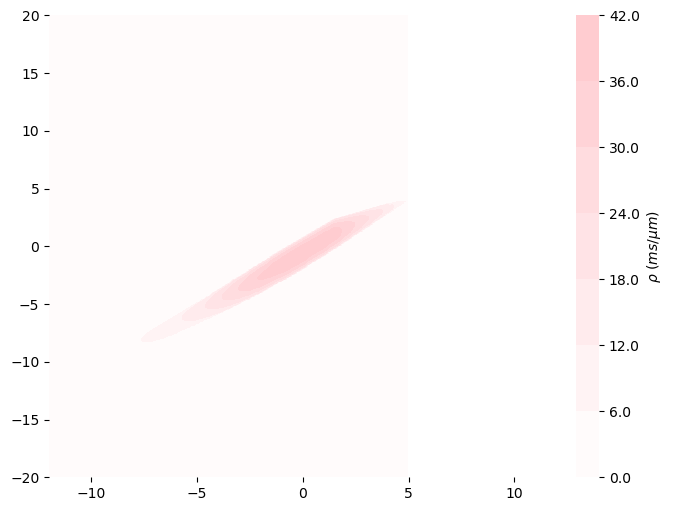

Locator attempting to generate 1001 ticks ([-9.999999999999999e-14, ..., 1e-13]), which exceeds Locator.MAXTICKS (1000).


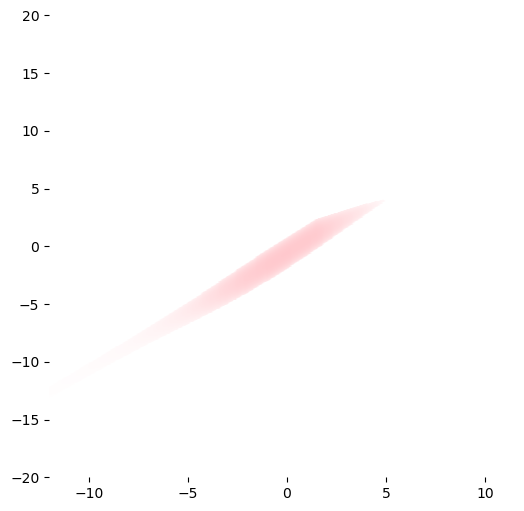

NameError: name 'Pi' is not defined

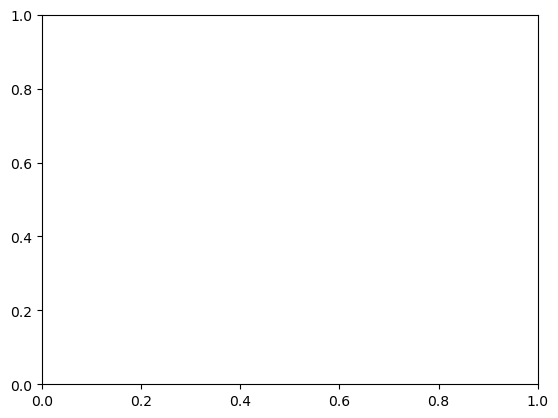

In [47]:
PI , GHD , N  = [] , [] , [] 
liste_t = np.array([0.000 , 1.000 , 10.000 , 11.000 , 20.000 , 21.000 , 30.000 ])
mask = (liste_t >= 0) & (liste_t <= 30)
mask = [ t in np.array([ 30.000]) for t in liste_t ]
print(mask)

##mat_nu_1 = np.array([
#        np.array([f_mat_nu_bord(v, theta , v1 = veff_bord_discr_exp_2 , v2 =  0.00001*theta_discr_exp +veff_bord_discr_exp_2[-1]   ) for theta in theta_discr_exp_2])
#        for v in veff_bord_discr_exp_2
#    ]) 

mat_rho = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr, nu, np.ones(len(theta_discr))) for nu in mat_nu ]  )

# theta_discr_exp
filename = f"{date}/theta_discr_exp_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp = np.load(filename)
Temps_exp = 30

for t in liste_t[mask] :
    filename = f"{date}/bord1_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord1 = np.load(filename)
    filename = f"{date}/bord2_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    bord2 = np.load(filename)

    save_as_tikz_table(bord1*Taille/t*8.63/max(veff_bord_discr*Temp_bord/t), theta_discr_exp*8.8/max(theta_discr), filename=f"bord_1_{t:.0f}.table")
    save_as_tikz_table(bord2*Taille/t*8.63/max(veff_bord_discr*Temp_bord/t), theta_discr_exp*8.8/max(theta_discr), filename=f"bord_2_{t:.0f}.table")
    
    
    veff_bord_discr_exp_2 = np.linspace(min(bord1[0] , bord2[0]) , max(bord2[-1] , bord1[-1]), 200)*Taille/Temp_bord
    theta_discr_exp_2 = np.linspace(theta_discr[0] , theta_discr[-1], 600)
    mat_nu_bord = np.array([
        np.array([f_mat_nu_bord(v, theta , v1 = bord1*Taille/Temp_bord , v2 = bord2*Taille/Temp_bord ) for theta in theta_discr_exp_2])
        for v in veff_bord_discr_exp_2
    ])  
    #vmin=0
    #vmax=1
    X0, Y0 = np.meshgrid(veff_bord_discr*Temp_bord/t, theta_discr)
    #plt.contourf( X0, Y0,   np.array([nu0 for v in veff_bord_discr]).T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    #plt.contourf( X0, Y0,   mat_nu.T, cmap='viridis' , vmin=vmin, vmax=vmax , alpha = 0.3)
    X, Y = np.meshgrid(veff_bord_discr_exp_2*Temp_bord/t, theta_discr_exp_2)
    #plt.contourf( X, Y,   mat_nu_bord.T, cmap='viridis' , vmin=vmin, vmax=vmax, alpha = 0.5)
    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.show()

    #plt.plot(veff_bord_discr*Temp_bord , theta_veff_fun(veff_bord_discr) , label = "veff" )
    
    #plt.plot(bord1*Taille, theta_discr_exp)
    #plt.plot(bord2*Taille , theta_discr_exp)
    #plt.plot(np.concatenate([bord1, np.flip(bord2)] , axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    #plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    mat_rho_bord = np.array([0.5 / np.pi * nu* mass/hbar* dress(gbar, theta_discr_exp_2, nu, np.ones(len(theta_discr_exp_2))) for nu in mat_nu_bord ]  )
    nb_levels = 1000
    vmin, vmax = 0 , 5.6*Taille

    # Créer un graphique de contours
    #cf0 = ax.contourf(X0, Y0, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    cf0 = ax.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    cf = ax.contourf( X, Y,   mat_rho_bord.T*Taille, cmap=custom_cmap , vmin=vmin, vmax=vmax , alpha = 1)
    ax.set_xlim(min(veff_bord_discr*Temp_bord/t), max(veff_bord_discr*Temp_bord/t))
    # Supprimer les traits noirs autour de la figure
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Ajouter la barre de couleur avec 1 décimale
    cbar = plt.colorbar(cf, ax=ax, label=r'$\rho~ (ms/\mu m)$')
    cbar.outline.set_visible(False)
    cbar.formatter = FormatStrFormatter('%.1f')
    cbar.update_ticks()
    
    # Sauvegarder le graphique complet avec les axes et la colorbar
    fig.savefig(f"complete_graph_coupure_2_{t:.0f}.pdf", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    
    # Sauvegarder les axes sans le graphique ni la colorbar
    fig_axes, ax_axes = plt.subplots(figsize=(6, 6))
    #ax_axes.contourf(X0, Y0, mat_rho.T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    ax_axes.contourf(X0, Y0, np.array([np.zeros(len(nu0)) for v in veff_bord_discr]).T, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)    
    ax_axes.contourf(X, Y, mat_rho_bord.T*Taille, levels=nb_levels, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=1)
    ax_axes.set_xlim(min(veff_bord_discr*Temp_bord/t), max(veff_bord_discr*Temp_bord/t))
    #ax_axes.set_axis_off()  # Masquer les axes
    # Supprimer les traits noirs autour de la figure
    for spine in ax_axes.spines.values():
        spine.set_visible(False)
    fig_axes.savefig(f"graph_coupure_2_{t:.0f}_only.pdf", dpi=300, bbox_inches='tight', transparent=True)

    #plt.plot(veff_bord_discr*Temp_bord , theta_discr , label = "veff" )
    #plt.colorbar()  # Ajouter une barre de couleur pour l'échelle des valeurs
    #plt.plot(np.concatenate([bord1, np.flip(bord2)], axis=0)*Taille, np.concatenate([theta_discr_exp, np.flip(theta_discr_exp)], axis=0) , color = "white" , label = str(t) )
    
    #plt.vlines(x_1*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 - Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.vlines(x_2*Temp_bord, min(theta_discr), max(theta_discr), colors='w', label="x0 + Taille/2", linestyle='--', linewidth=2 , alpha = 0.2)
    #plt.xlim([0,2])
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"$\mu m/ms$")
    #plt.legend()
    plt.show()





    #Pi = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,))
    #Ghd = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(1,))
    #nat = integral_axis1 = integ(veff_bord_discr_exp_2*Temp_bord, theta_discr_exp_2, mat_rho_bord, axes=(0,1))

    #PI.append(Pi)
    #GHD.append(Ghd)
    #N.append(nat)

    #plt.plot(theta_discr_exp_2 , Pi , label = f"Pi : {t:.3f}") 
    #for i , rho in enumerate(mat_rho_bord) :
    #    plt.plot(theta_discr_exp_2 , rho , label = f"rho : {i:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"$ms/\mu m$")
    #plt.legend()
    #plt.show()

    #plt.plot(veff_bord_discr_exp_2 , Ghd , label = f"GHD : {t:.3f}") 
    #plt.xlabel(r"$\mu m/ms$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()

    #plt.plot(theta_discr_exp_2*liste_t[-1]+x0, PI[0]/liste_t[-1] , label = f"Pi : {0:.3f}") 
    #plt.plot(veff_bord_discr_exp_2*Temp_bord, Ghd , label = f"Ghd : {t:.3f}") 
    #plt.xlabel(r"$\mu m$")
    #plt.ylabel(r"${\mu m}^{-1}$")
    #plt.legend()
    #plt.show()


    fig, ax1 = plt.subplots()
    
    label = r"$GHD*\tau$"
    filename = f"{date}/density_expansion_nu_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{t:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    density = np.load(filename)    
    # Créer un nouvel intervalle allant de 0 à 400
    x_new = np.linspace(max(density[0, :] * Taille) , 400, 100)  # 100 points entre 0 et 400
    y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    # Concaténer avec tes données existantes
    x_combined = np.concatenate([density[0, :] * Taille/t, x_new/t])
    y_combined = np.concatenate([density[1, :]*t, y_new*t])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/(max(Pi)) , filename=f"density_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined, y_combined, linewidth=3, color=plt.cm.inferno(0.6), alpha=1,
         label=label)
    
    label = r"$\Pi$"
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
       
    x_new = np.linspace(max(theta_discr_exp*t +x0) , 400, 100)  # 100 points entre 0 et 400
    y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
    filename = f"{date}/Pi_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    Pi_0 = np.load(filename) * Taille
    # Concaténer avec tes données existantes
    x_combined = np.concatenate([theta_discr_exp +x0/t, x_new/t])
    y_combined = np.concatenate([Pi_0, y_new])

    save_as_tikz_table(x_combined*8.8/20, y_combined*5/(max(Pi)) , filename=f"Pi_coupure_2_{t:.0f}.table")
    
    ax1.plot(x_combined,  y_combined, linewidth=3, color="#8c564b",alpha=1, 
             label=label)

    print("max Pi" , max(Pi))

    
    label = r"$\ell\rho$"
    
    index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
    filename = f"{date}/rho_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    filename = f"{date}/rho_bon_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    rho_theta_star_discr = np.load(filename)['arr_0']
    
    filename = f"{date}/theta_discr_exp_2_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
    #filename = '2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz' 
    print ( 'filename =' ,filename )
    #sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
    theta_discr_exp_2 = np.load(filename)['arr_0']
       
    #theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
    theta0 =  x0/t

    save_as_tikz_table((theta_discr_exp_2+theta0)*8.8/20, rho_theta_star_discr*Taille*5/(max(Pi)) , filename=f"rho_coupure_2_{t:.0f}.table")
    
    ax1.plot((theta_discr_exp_2+theta0), 
             rho_theta_star_discr*Taille , 
             linewidth=3 , 
             linestyle='--',
             alpha=1,
             color = "black",#"#bcbd22", 
             label=label)
    
    plt.ylim([-0.5 , 4.6*t ])
    plt.xlim([-450/t, 250/t ])    
    plt.grid(True)
    #plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    #plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    # Personnalisation de la légende
    ax1.legend(
        #loc='upper left',             # Position de la légende
        loc='upper left',
        #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
        #loc='best', 
        bbox_to_anchor=(0.005, 1),
        #fancybox=False,                  # Ajouter une bordure arrondie
        #shadow=False,                    # Ajouter une ombre
        #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
        #fontsize=police,                    # Taille de la police
        #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
        facecolor='#e8e8e8',                  # Couleur de fond de la légende
        #edgecolor='black',              # Couleur du bord de la légende
        #title='Légende de l\'expérience', # Titre de la légende
        #title_fontsize='large',         # Taille de la police du titre
        #labelspacing=0.1,               # Espacement entre les labels de la légende
        #handlelength=0.5,               # Longueur des poignées des items de la légende
        #handleheight=1.5,               # Hauteur des poignées des items de la légende
        #columnspacing=0,               # Espacement entre les colonnes
        #alignment = 'right',
    )
    plt.grid(color='white', linestyle='-', linewidth=1)
    # Rendre le cadre invisible
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Appliquer un fond gris
    #plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas
    
    
    # Appliquer un fond gris clair au graphe
    #plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
    plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
    plt.savefig('Figures/article_distribution_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
    plt.savefig('Figures/article_distribution_24-04-2024.svg', bbox_inches='tight', dpi = 300)
    plt.show()

🚀 Exécution : sshpass -p "Cedt,ll?" rsync -ah --progress -u "isabelle.bouchoule@10.117.49.59:/home/isabelle.bouchoule/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/2025-01-27/theta_discr_exp_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz" "/Users/themezeguillaume/Desktop/Scroll_Web/quantum-mechanics-thesis-main/Domain_Wall_Dynamics_for_a_1D_Bose_ga/Figures/data/2025-01-27/theta_discr_exp_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_0.000.npz"
receiving file list ... 
1 file to consider

sent 16 bytes  received 183 bytes  132.67 bytes/sec
total size is 1.68K  speedup is 8.44
🚀 Exécution : sshpass -p "Cedt,ll?" rsync -ah --progress -u "isabelle.bouchoule@10.117.49.59:/home/isabelle.bouchoule/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/2025-01-27/density_expansion_nu_theta_edge_1.0_ih2_64.676_559.424_18.339_22.089_30.000.npz" "/Users/themezeguillaume/Desktop/Scroll_Web/quantum-mechanics-thesis-main/Domain_Wall_Dynamics_for_a_1D_Bose_ga/Figures/data/

NameError: name 'police' is not defined

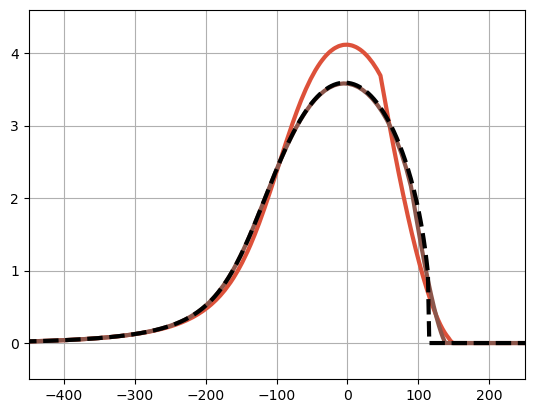

In [ ]:
# theta_discr_exp
filename = f"{date}/theta_discr_exp_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp = np.load(filename)
Temps_exp = 30
fig, ax1 = plt.subplots()

# densité
filename = f"{date}/density_expansion_nu_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{Temps_exp:.3f}.npz"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
density = np.load(filename)     
label = r"GHD"
# Créer un nouvel intervalle allant de 0 à 400
x_new = np.linspace(max(density[0, :] * Taille) , 400, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
# Concaténer avec tes données existantes
x_combined = np.concatenate([density[0, :] * Taille, x_new])
y_combined = np.concatenate([density[1, :], y_new])   
ax1.plot(x_combined, y_combined, linewidth=3, color=plt.cm.inferno(0.6), alpha=1,
     label=label)

#ax1.plot(X[mask], Y[mask], label=f"donnés du "+ date_donnees + ' : ' + label )
index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore

label = r"$\Pi/\tau$"
x_new = np.linspace(max(theta_discr_exp*Temps_exp +x0) , 400, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
filename = f"{date}/Pi_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Pi_0 = np.load(filename) * Taille
# Concaténer avec tes données existantes
x_combined = np.concatenate([theta_discr_exp*Temps_exp +x0, x_new])
y_combined = np.concatenate([Pi_0/Temps_exp, y_new])
ax1.plot(x_combined,  y_combined, linewidth=3, color="#8c564b",alpha=1, 
         label=label)


index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
filename = f"{date}/rho_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
filename = f"{date}/rho_bon_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
rho_theta_star_discr = np.load(filename)['arr_0']

filename = f"{date}/theta_discr_exp_2_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
#filename = '2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz' 
print ( 'filename =' ,filename )
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp_2 = np.load(filename)['arr_0']

label = r"$\ell\rho/\tau$"


#theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
theta0 =  x0/Temps_exp

ax1.plot((theta_discr_exp_2+theta0)*Temps_exp, 
         rho_theta_star_discr/Temps_exp*Taille , 
         linewidth=3 , 
         linestyle='--',
         alpha=1,
         color = "black",#"#bcbd22", 
         label=label)

plt.ylim([-0.5 , 4.6 ])
plt.xlim([-450, 250 ])    
plt.grid(True)
#plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
#plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
# Personnalisation de la légende
ax1.legend(
    #loc='upper left',             # Position de la légende
    loc='upper left',
    #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
    #loc='best', 
    bbox_to_anchor=(0.005, 1),
    #fancybox=False,                  # Ajouter une bordure arrondie
    #shadow=False,                    # Ajouter une ombre
    #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
    fontsize=police,                    # Taille de la police
    #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
    facecolor='#e8e8e8',                  # Couleur de fond de la légende
    #edgecolor='black',              # Couleur du bord de la légende
    #title='Légende de l\'expérience', # Titre de la légende
    #title_fontsize='large',         # Taille de la police du titre
    #labelspacing=0.1,               # Espacement entre les labels de la légende
    #handlelength=0.5,               # Longueur des poignées des items de la légende
    #handleheight=1.5,               # Hauteur des poignées des items de la légende
    #columnspacing=0,               # Espacement entre les colonnes
    #alignment = 'right',
)
plt.grid(color='white', linestyle='-', linewidth=1)
# Rendre le cadre invisible
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Appliquer un fond gris
#plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas


# Appliquer un fond gris clair au graphe
#plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
plt.savefig('Figures/article_distribution_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
plt.savefig('Figures/article_distribution_24-04-2024.svg', bbox_inches='tight', dpi = 300)
plt.show()

🚀 Exécution : sshpass -p "Cedt,ll?" rsync -ah --progress -u "isabelle.bouchoule@10.117.49.59:/home/isabelle.bouchoule/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/2024-04-24/Donnees/Y_coupure2_1ms.txt" "/Users/themezeguillaume/Desktop/Scroll_Web/quantum-mechanics-thesis-main/These_Memoire/BiPart/Figures/data/2024-04-24/Donnees/Y_coupure2_1ms.txt"
receiving file list ... 
1 file to consider

sent 16 bytes  received 128 bytes  57.60 bytes/sec
total size is 17.83K  speedup is 123.84
🚀 Exécution : sshpass -p "Cedt,ll?" rsync -ah --progress -u "isabelle.bouchoule@10.117.49.59:/home/isabelle.bouchoule/Puce/analysedata/analyses_jupyter/analyses_Guillaume/Bord/2024-04-24/Donnees/Y_coupure2_30ms.txt" "/Users/themezeguillaume/Desktop/Scroll_Web/quantum-mechanics-thesis-main/These_Memoire/BiPart/Figures/data/2024-04-24/Donnees/Y_coupure2_30ms.txt"
receiving file list ... 
1 file to consider

sent 16 bytes  received 129 bytes  96.67 bytes/sec
total size is 17.61K  speedup is 121.48


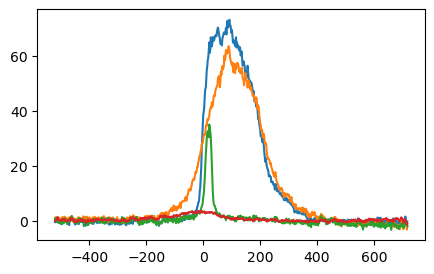

In [ ]:
# Données

date_donnees = '2024-04-24'


fichier_x = "X_coupure1_1ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_x}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
X_1_1 = np.loadtxt(filename)
fichier_y = "Y_coupure1_1ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_y}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Y_1_1 = np.loadtxt(filename)
plt.plot(X_1_1 , Y_1_1)

fichier_x = "X_coupure1_18ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_x}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
X_1_18 = np.loadtxt(filename)
fichier_y = "Y_coupure1_18ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_y}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Y_1_18 = np.loadtxt(filename)
plt.plot(X_1_18 , Y_1_18)

fichier_x = "X_coupure2_1ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_x}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
X_2_1 = np.loadtxt(filename)
fichier_y = "Y_coupure2_1ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_y}"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Y_2_1 = np.loadtxt(filename)
plt.plot(X_2_1 , Y_2_1)

fichier_x = "X_coupure2_30ms.txt"       
filename = f"{date_donnees}/Donnees/{fichier_x}"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
X_2_30 = np.loadtxt(filename)
fichier_y = "Y_coupure2_30ms.txt"
filename = f"{date_donnees}/Donnees/{fichier_y}"
sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Y_2_30 = np.loadtxt(filename)
plt.plot(X_2_30 , Y_2_30)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def norme(x , p ):
    if p == 0 : return float('inf') if any (el != 0 for el in x ) else 0
    elif p == float('inf') : return np.max(np.abs(x))
    else : return np.power(np.sum(np.power(np.abs(x),p)), 1/p)

def chi_squared_and_plot(x, y, xs, sigma=None):
    """
    Fonction pour calculer le chi² entre n(x) et n(-(x - xs)) et tracer les deux fonctions.

    Arguments:
    - x: liste ou tableau des valeurs de x.
    - y: liste ou tableau des valeurs n(x) associées à chaque x.
    - xs: décalage pour la transformation de x vers -(x - xs).
    - sigma: incertitude sur y (optionnel). Si non fourni, une incertitude de 1 est supposée.

    Retourne:
    - La valeur du chi².
    """

    # Fonction d'interpolation de n(x) (renvoie 0 si x est en dehors des bornes)
    def n(x_val):
        if x_val < min(x):
            return y[0]  # Retourne 0 si x est hors des bornes
        elif x_val > max(x):
            return y[-1]

        from scipy.interpolate import CubicSpline

        # Créer l'interpolateur spline cubique
        spline = CubicSpline(x, y)

        # Générer des points à interpoler
        y_new = spline(x_val)
        return y_new#np.interp(x_val, x, y)  # Interpolation linéaire

    # Calcul des différences entre n(x) et n(-(x - xs))
    #diff = [(n(xi-xs) - n(-xi - xs)) for xi in x]
    #n_x = [n(xi)for xi in x]
    n_x_minus_xs = [n(xi-xs)for xi in x]
    #n_neg_x_plus_xs = [n(-(xi-xs))for xi in x]
    n_neg_x_minus_xs = [n(-xi-xs)for xi in x]

    n_neg_x_minus_xs = [item if isinstance(item, np.float64) else item.item() for item in n_neg_x_minus_xs]
    n_x_minus_xs = [item if isinstance(item, np.float64) else item.item() for item in n_x_minus_xs]

    n_s = (np.array(n_x_minus_xs) + np.array(n_neg_x_minus_xs))/2
    n_a = (np.array(n_x_minus_xs) - np.array(n_neg_x_minus_xs))/2

    #print (n_x_minus_xs )

    # Vérification de la taille des deux listes et de leurs types
    #print(f"\nType et taille des listes :")
    #print(f"n_x_minus_xs : type = {type(n_x_minus_xs)}, taille = {len(n_x_minus_xs)}")
    #print(f"n_neg_x_minus_xs : type = {type(n_neg_x_minus_xs)}, taille = {len(n_neg_x_minus_xs)}")


    # Vérification de la présence de NaN dans les deux listes
    #if np.any(np.isnan(n_x_minus_xs)):
    #    print("La liste n_x_minus_xs contient des NaN.")
    #else:
    #    print("La liste n_x_minus_xs ne contient pas de NaN.")
    
    #if np.any(np.isnan(n_neg_x_minus_xs)):
    #    print("La liste n_neg_x_minus_xs contient des NaN.")
    #else:
    #    print("La liste n_neg_x_minus_xs ne contient pas de NaN.")
    
    # Vérification de la taille des deux listes
    #if len(n_x_minus_xs) == len(n_neg_x_minus_xs):
    #    print(f"Les deux listes ont la même taille : {len(n_x_minus_xs)} éléments.")
    #else:
    #    print(f"Les listes ont des tailles différentes : n_x_minus_xs = {len(n_x_minus_xs)}, n_neg_x_minus_xs = {len(n_neg_x_minus_xs)}.")
    
    # Si les tailles sont égales, on peut calculer la différence
    #if len(n_x_minus_xs) == len(n_neg_x_minus_xs):
    #    diff = np.array(n_x_minus_xs) - np.array(n_neg_x_minus_xs)
    #    print(f"Différence calculée avec {len(diff)} éléments.")
    #else:
    #    print("Les tailles des listes ne correspondent, donc la différence ne peut pas être calculée.")

    diff = np.array(n_x_minus_xs) - np.array(n_neg_x_minus_xs)

    # Calcul de chi²
    if sigma is None:sigma = np.ones_like(y)  # Si sigma n'est pas spécifié, on prend une incertitude de 1

    #chi2 = np.sum((np.array(diff) ** 2) / (np.array(sigma) ** 2))
    #chi2 = np.sum((np.array(diff) ** 2) / (np.array(n_x_minus_xs) ** 2))
    chi2 = norme(diff/2, 2)/norme(n_x_minus_xs , 2)
    
    
    # Tracé des deux fonctions : n(x - xs) et n(-(x - xs))
    x_vals = x
    #x_vals = np.linspace(min(x) - 1, max(x) + 1, 500)  # Création d'une plage x fine pour le tracé

    # Calcul des valeurs n(x - xs) et n(-(x - xs)) pour chaque x
    #n_x = [n(xv) for xv in x_vals]
    #n_x_minus_xs = [n(xv - xs) for xv in x_vals]
    #n_neg_x_plus_xs = [n(-(xv - xs)) for xv in x_vals]

    # Tracé des deux courbes
    plt.figure(figsize=(8, 6))
    #plt.plot(x_vals, n_x, label=r'$n(x)$', color='blue')
    plt.plot(x_vals, n_x_minus_xs, label=r'$n(x - x_0)$', color='blue' ,linewidth=1, alpha=0.5 )
    #plt.plot(x_vals, n_neg_x_plus_xs, label=r'$n(-(x - x_0))$', color='red', linestyle='--')
    plt.plot(x_vals, n_neg_x_minus_xs, label=r'$n(-(x + x_0))$', color='red' , linewidth=1, alpha=0.5)
    plt.plot(x_vals, n_s, label=r'$n_s(x - x_0)$', color='magenta', linestyle='-' , linewidth=3)
    plt.plot(x_vals, n_a, label=r'$n_a(x - x_0)$', color='grey', linestyle='-' , linewidth=3)
    #plt.scatter(x, y, color='black', label='Données originales')
    plt.title(f'Comparaison entre n(x - xs) et n(-(x - xs)) pour xs = {xs} , et chi2 = {chi2}')
    plt.axvline(x=xs, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    plt.xlabel('x')
    plt.ylabel('n(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return chi2

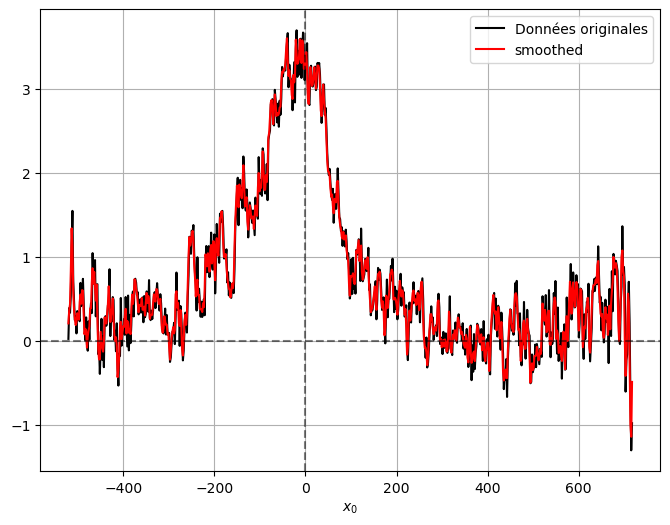

In [ ]:
# il faut lisser sinom beaucoup d'extremum 
X , Y  = X_2_30 , Y_2_30 
window_size = 2
y_smoothed = np.convolve(Y, np.ones(window_size)/window_size, mode='same')
plt.figure(figsize=(8, 6))

plt.plot(X, Y, color='black', label='Données originales')
plt.plot(X, y_smoothed, label=f'smoothed', color='red' , linewidth=1.5 )
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlabel('$x_0$')
plt.legend()
plt.grid(True)
plt.show()

2024-04-24


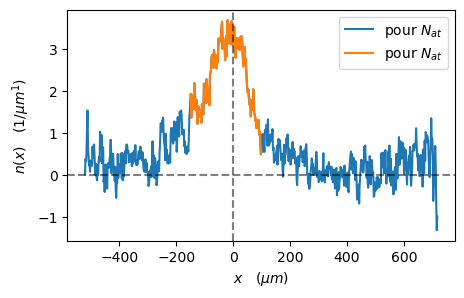

In [ ]:
print(date_donnees)
if date_donnees == '2024-02-09': mask = (X > -200) & (X < 50)
elif date_donnees == '2024-02-29': 
    mask = (X > -220) & (X < 20)
    MASK = (X>0)*(X<150) 
    p0 =  117 # Estimation initiale pour x0
elif date_donnees == '2024-04-24': 
    mask = (X > -150) & (X < 100)
    MASK = (X>10)*(X<20) 
    p0 =  -14 # Estimation initiale pour x0
plt.plot ( X , Y , label = "pour $N_{at}$")
plt.plot ( X[mask] , Y[mask] , label = "pour $N_{at}$")
plt.xlabel(r"$x \quad (\mu m)$")  # Label de l'axe des X (avec notation LaTeX)
plt.ylabel(r"$n(x) \quad (1/\mu m^1)$")  # Label de l'axe des Y (avec notation LaTeX)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.legend()
plt.show()

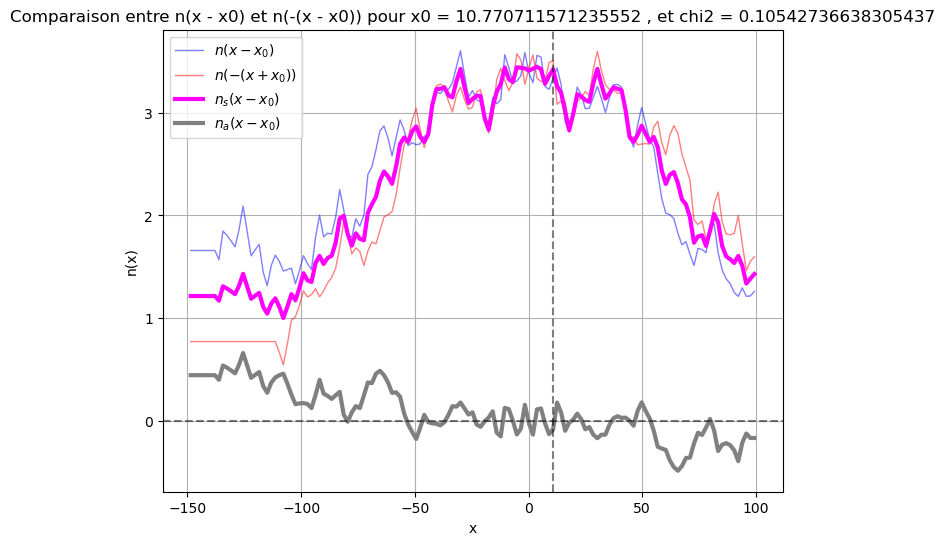

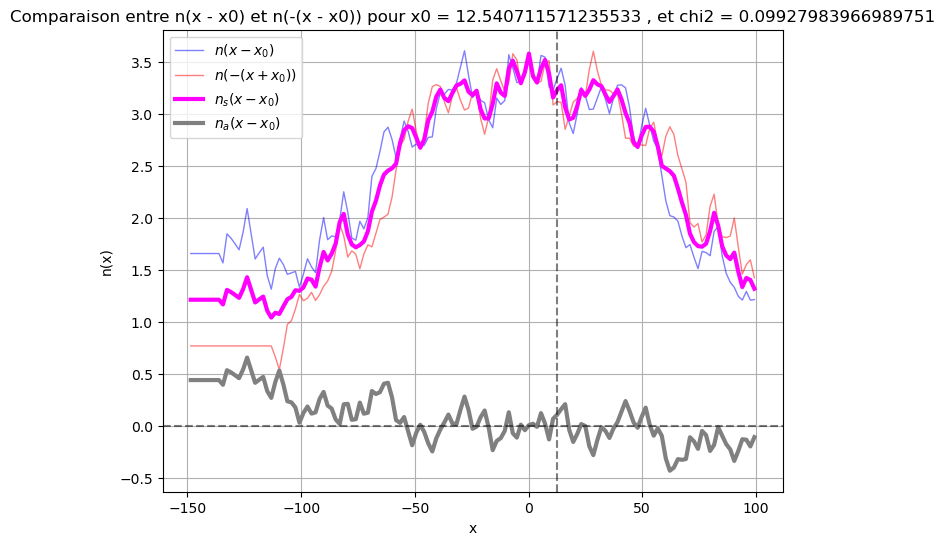

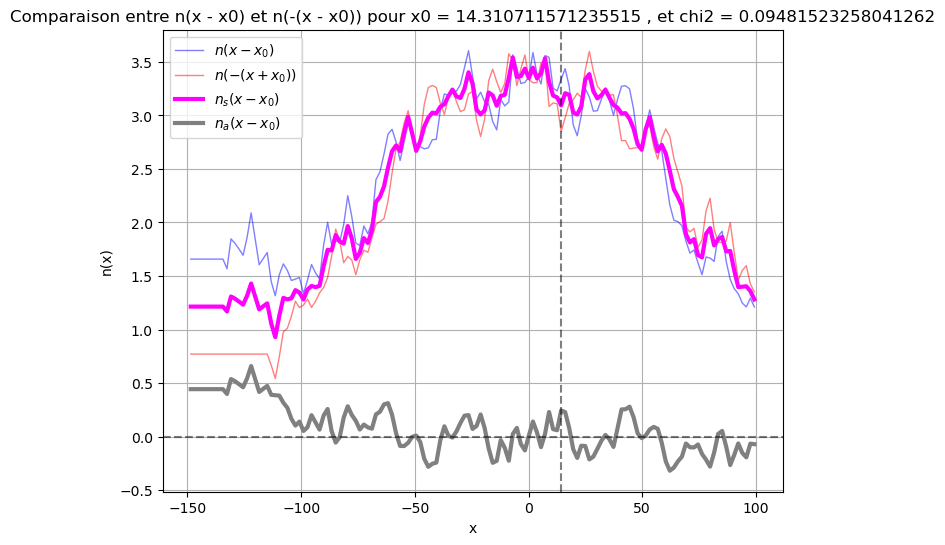

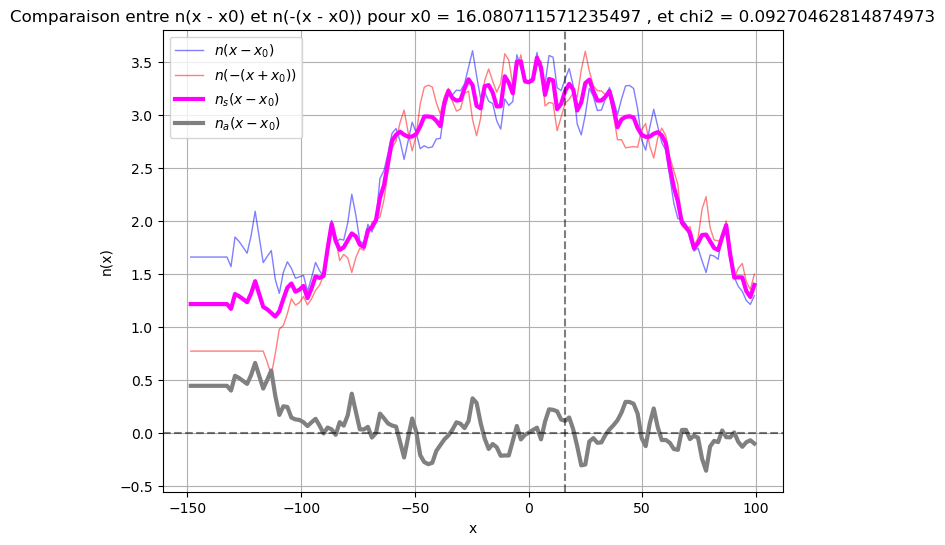

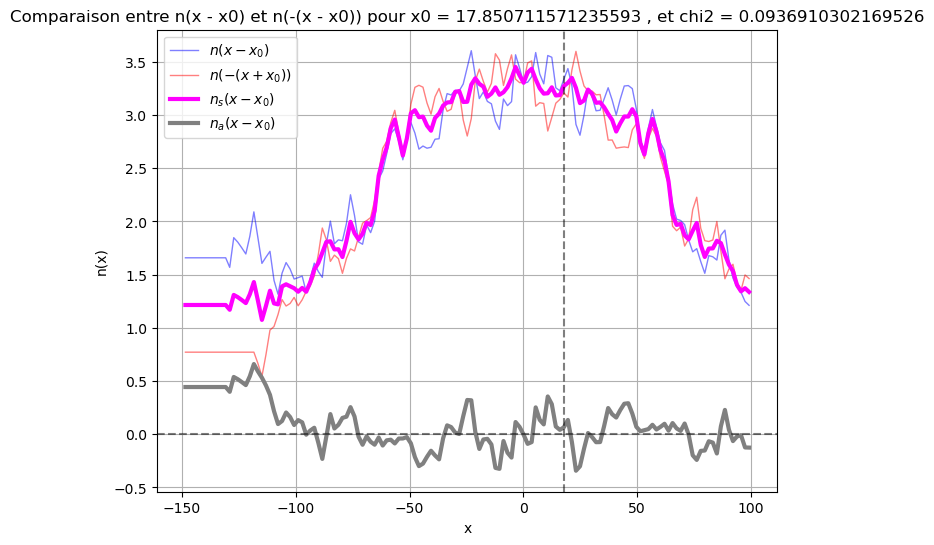

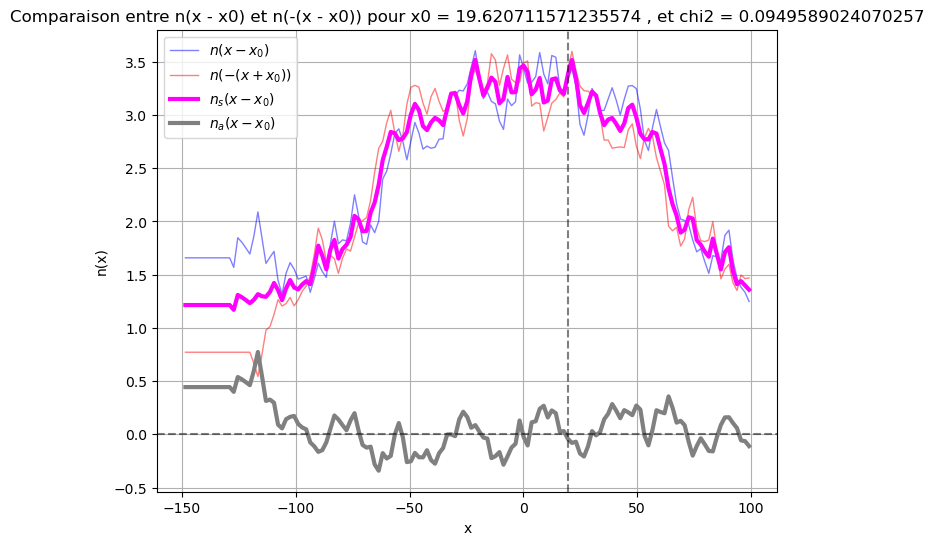

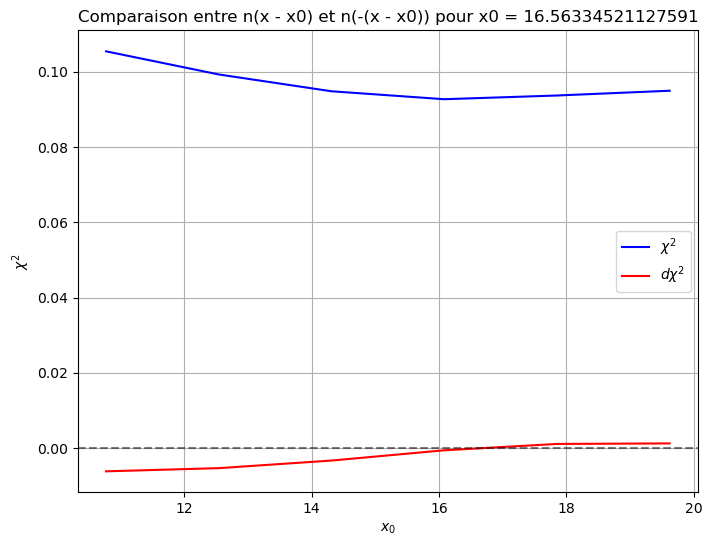

In [ ]:
# Calculer la fonction 
#MASK = mask
#CHI2 = np.array([chi_squared_and_plot(np.flip(X[mask]), np.flip(Y[mask]), x0, sigma=None) for x0 in np.flip(X[MASK])])
CHI2 = np.array([chi_squared_and_plot(np.flip(X[mask]), np.flip(y_smoothed[mask]), x0, sigma=None) for x0 in np.flip(X[MASK])])
plt.figure(figsize=(8, 6))
plt.plot(np.flip(X[MASK]), CHI2, label=f'$\\chi^2$', color='blue')
plt.plot(np.flip(X[MASK]), np.gradient(CHI2), label=f'$d\\chi^2$', color='red')
plt.title(f'Comparaison entre n(x - x0) et n(-(x - x0)) pour x0 = {x0}')
#plt.axvline(x=x0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
#plt.xlim([90 , 120 ])
#plt.ylim([-100, 200 ])
plt.xlabel('$x_0$')
plt.ylabel(f'$\\chi^2$')
plt.legend()
plt.grid(True)
plt.show()

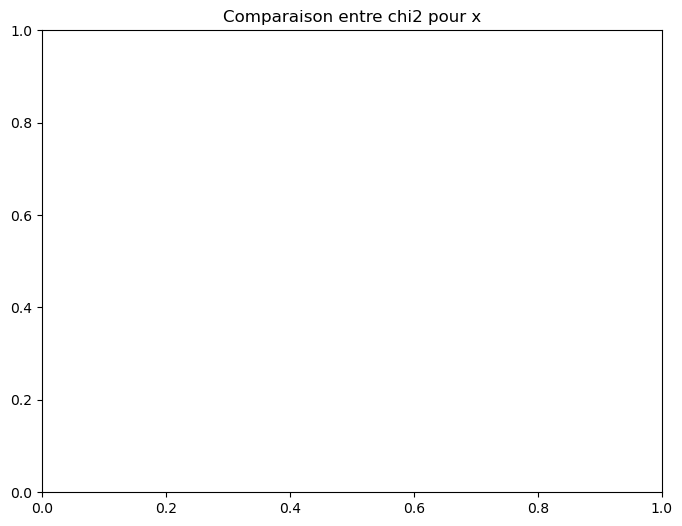

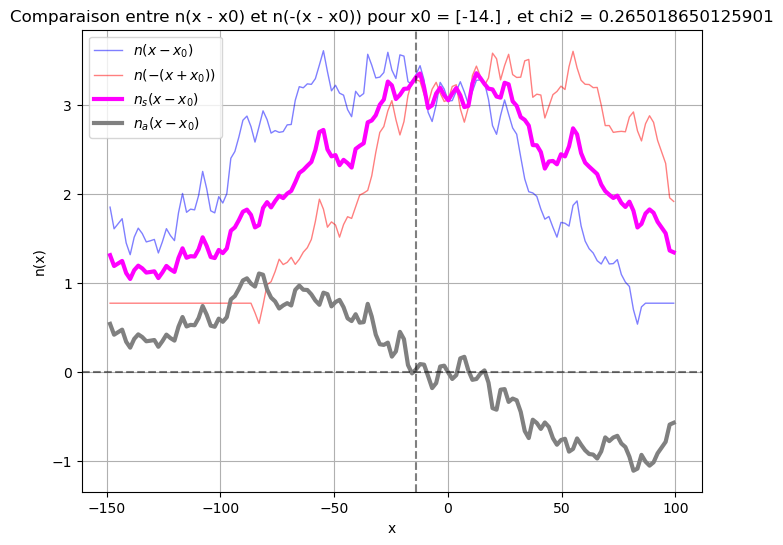

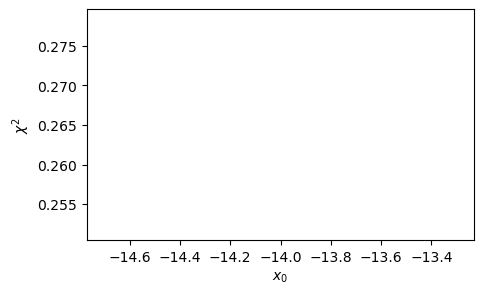

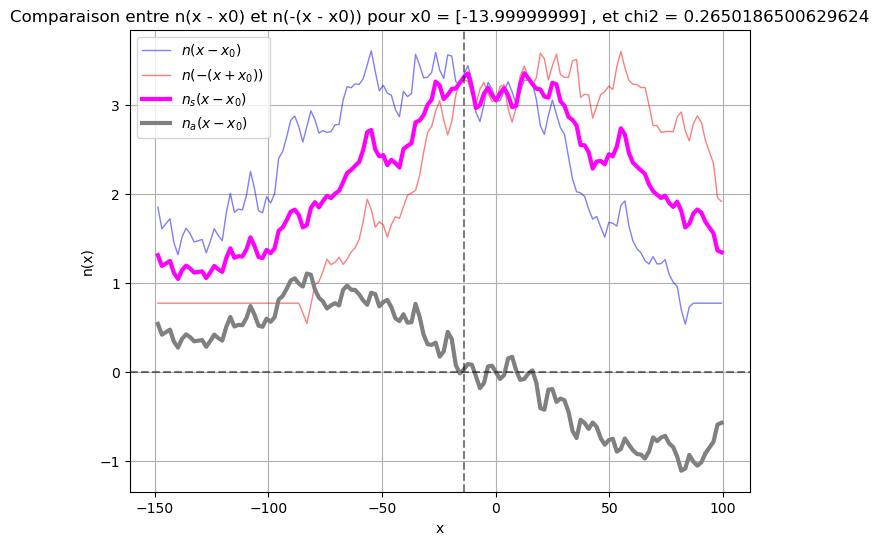

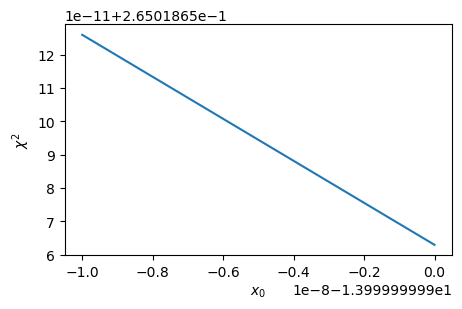

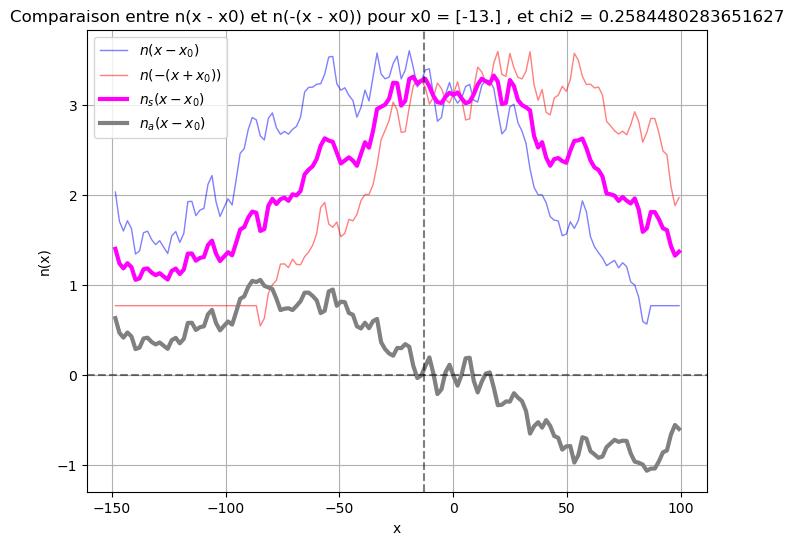

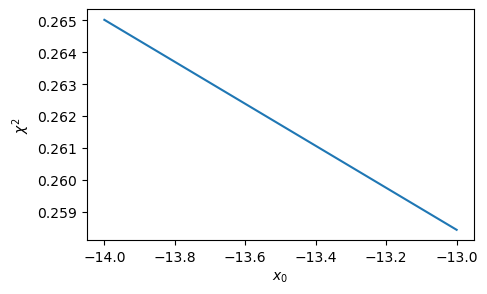

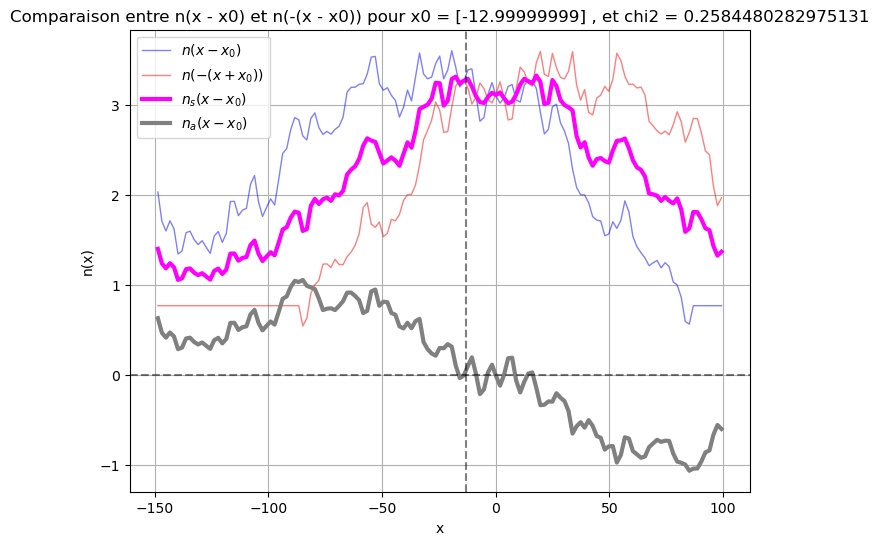

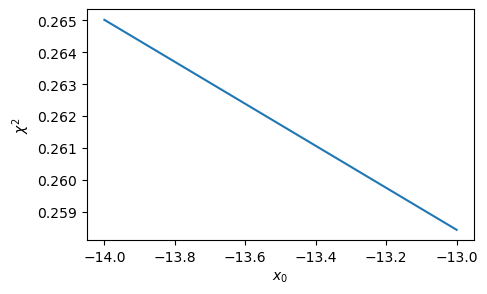

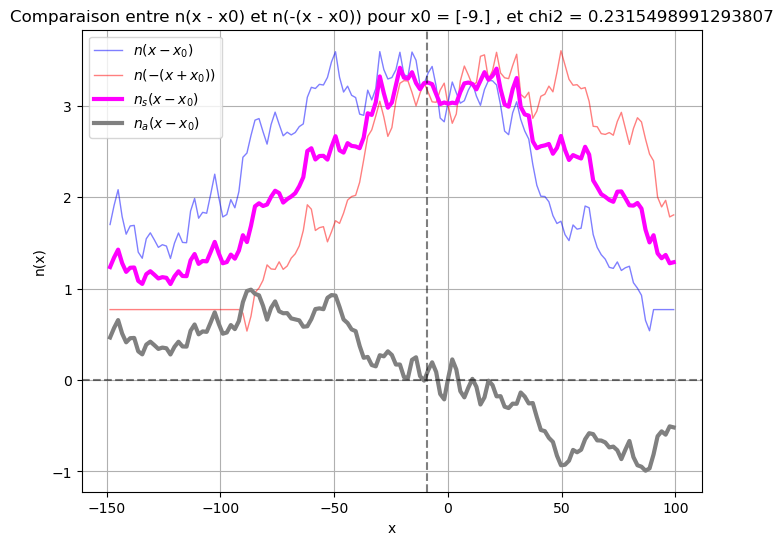

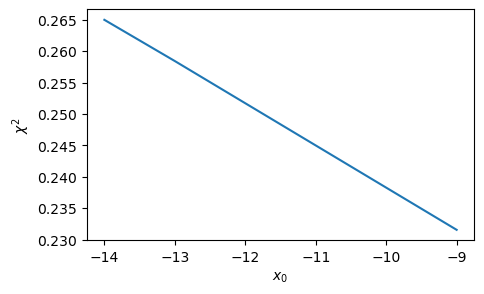

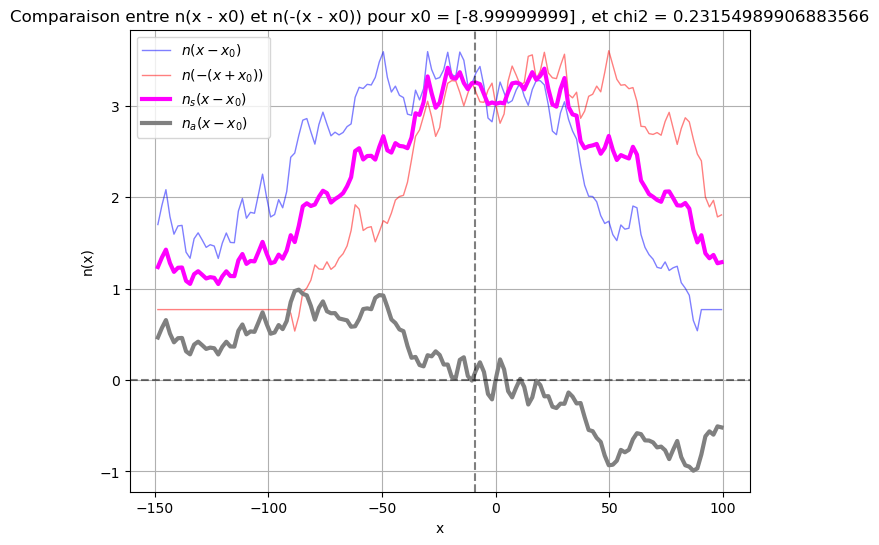

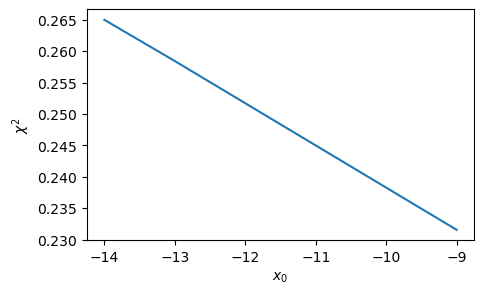

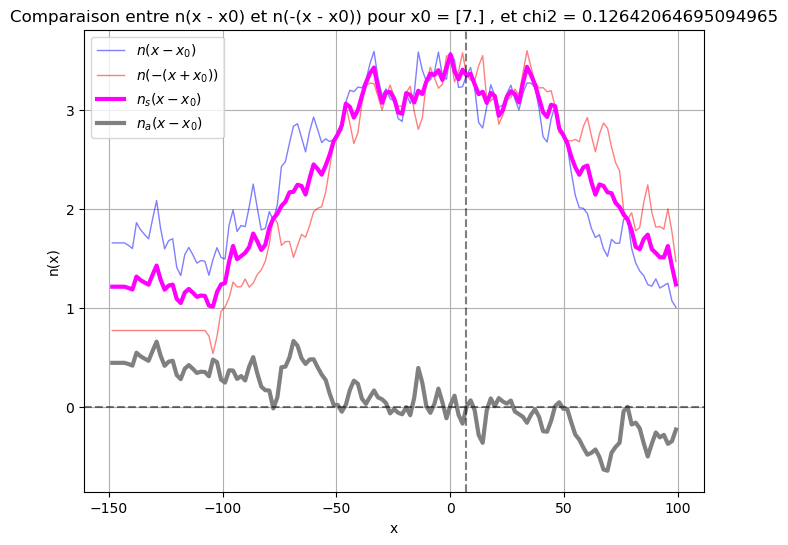

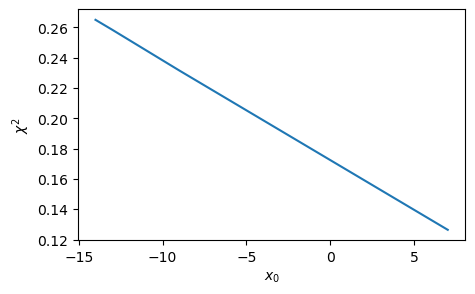

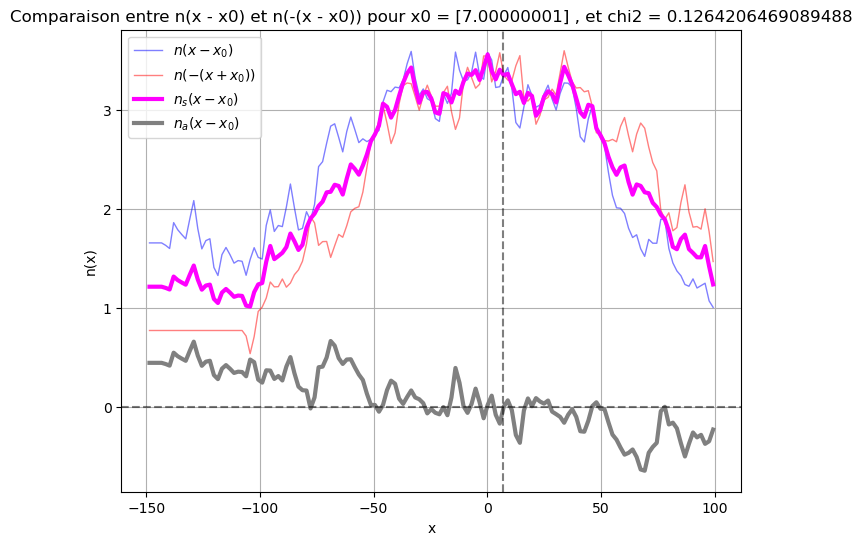

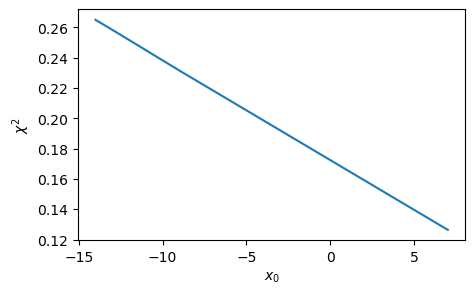

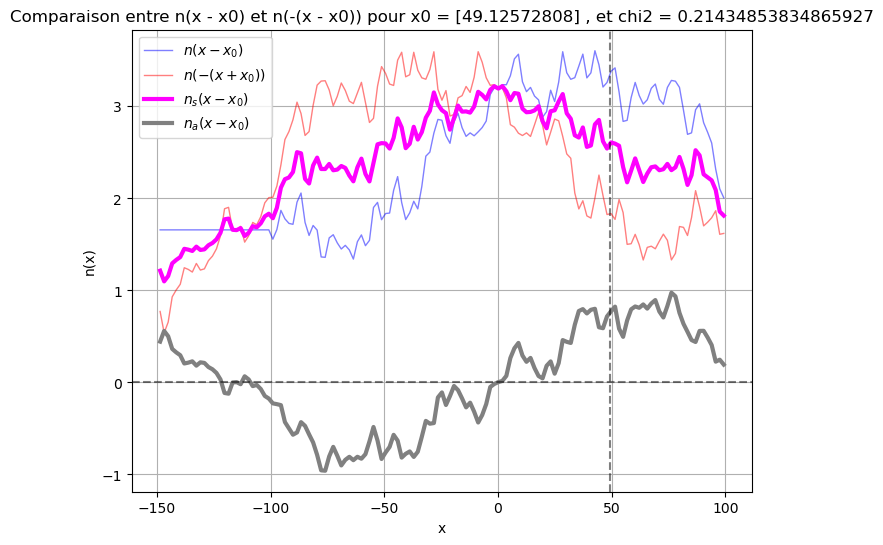

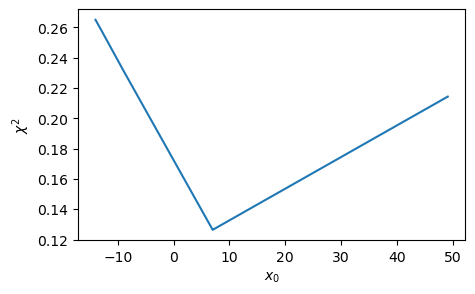

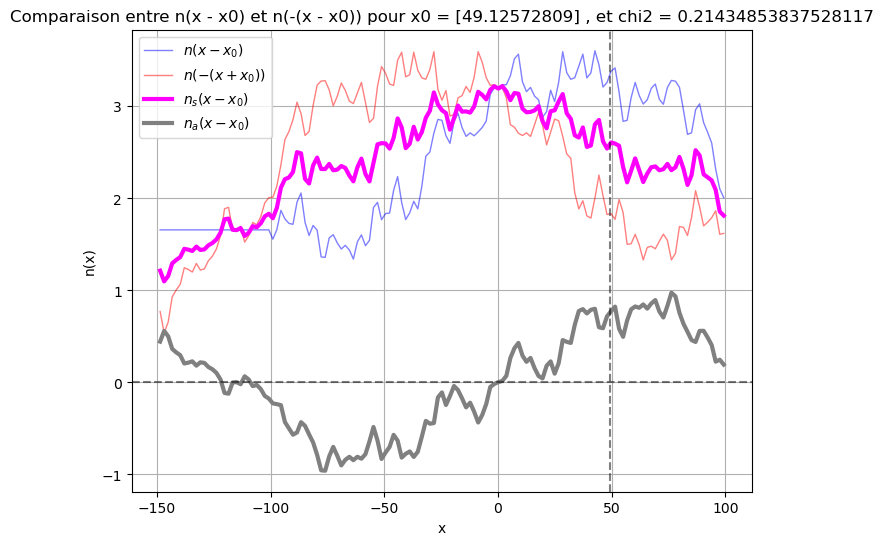

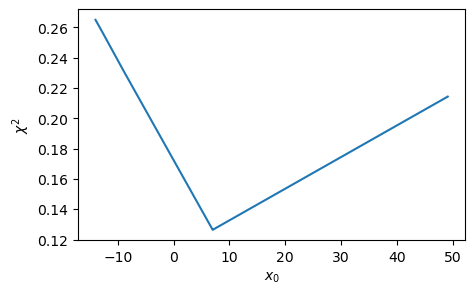

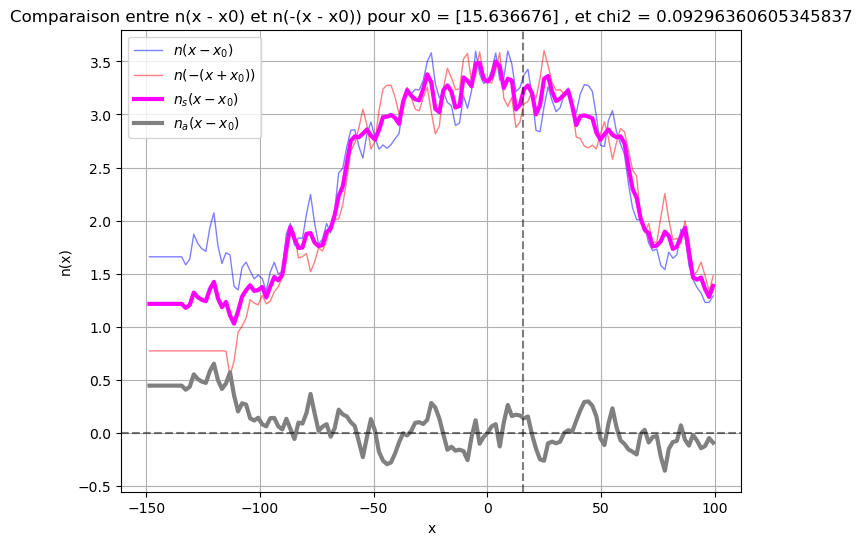

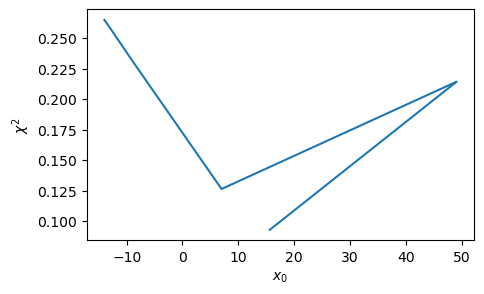

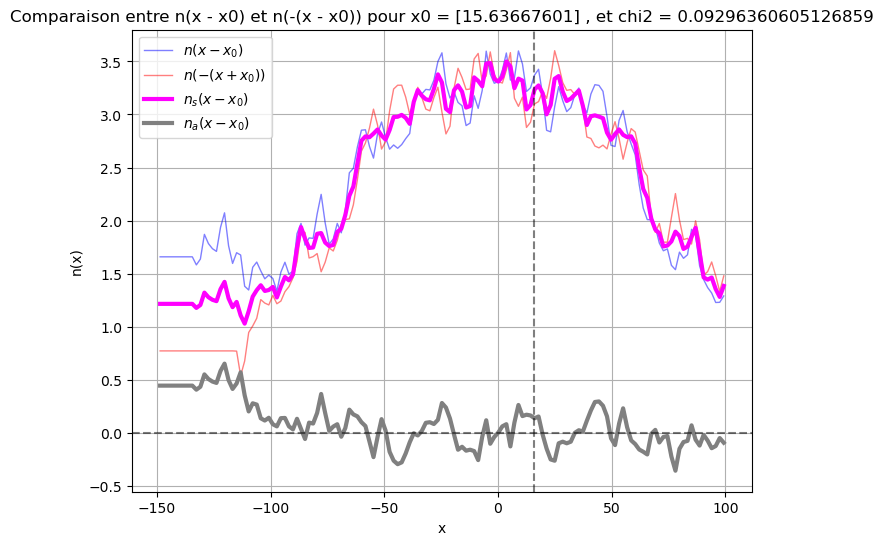

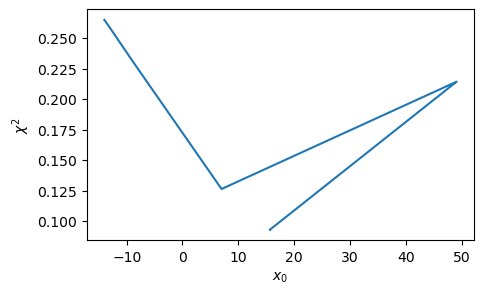

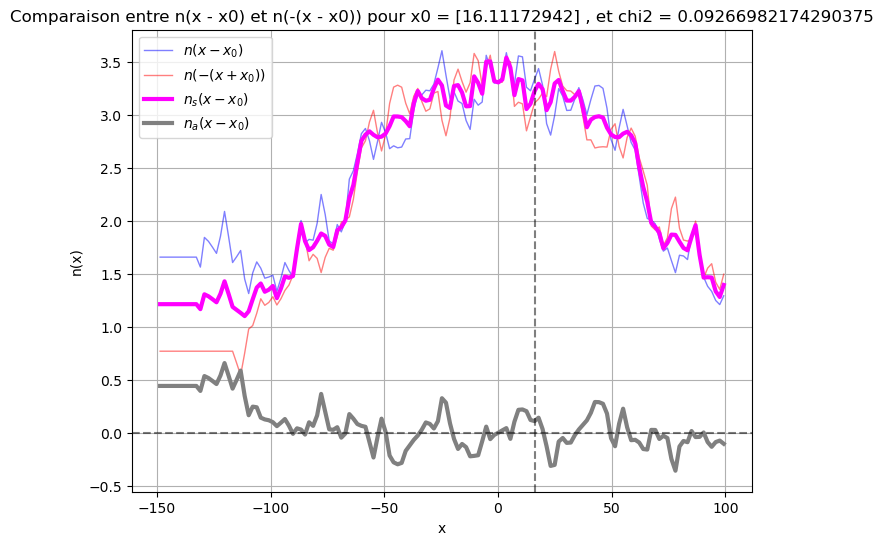

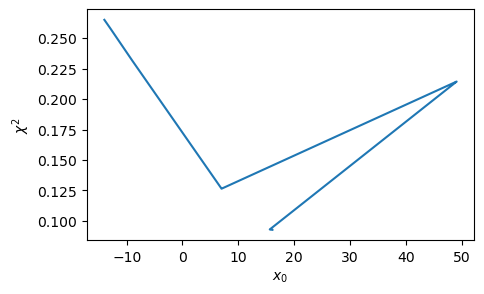

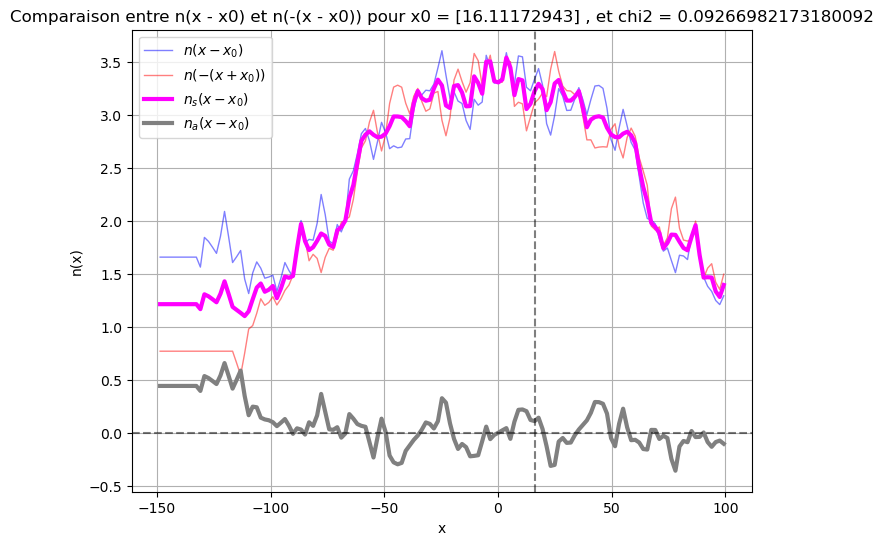

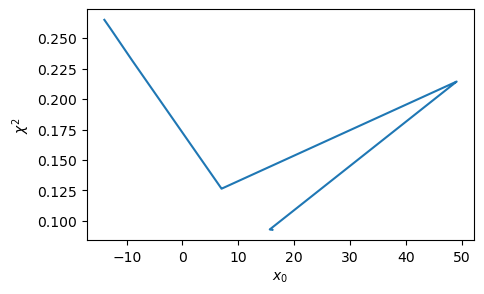

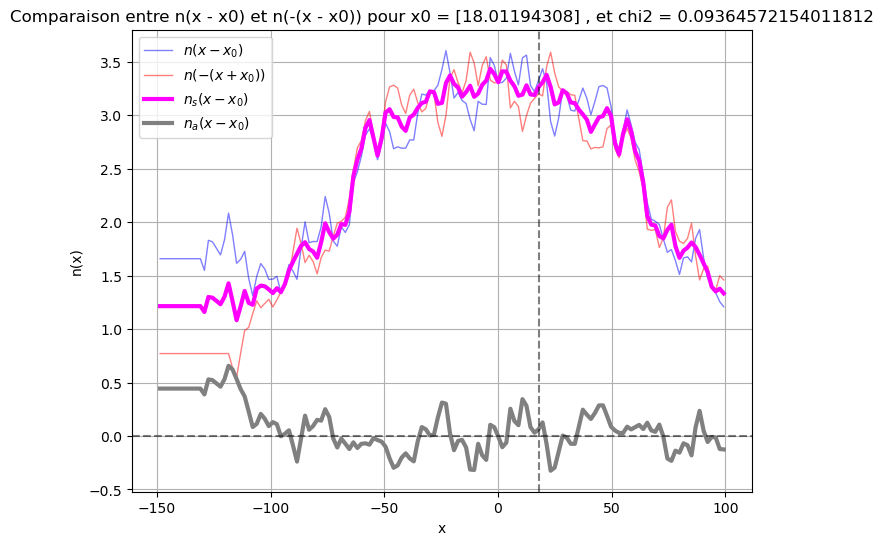

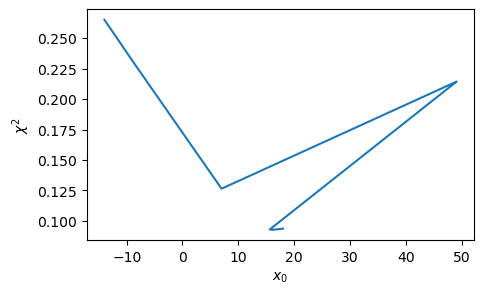

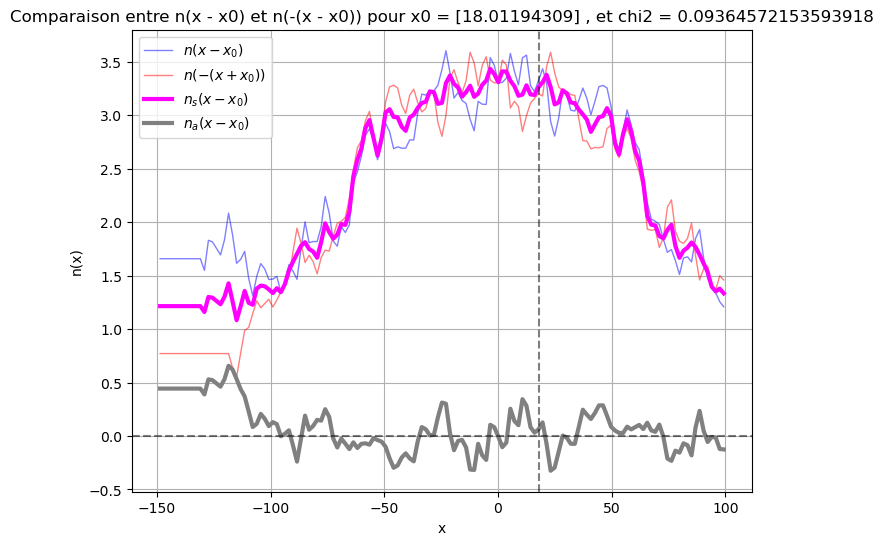

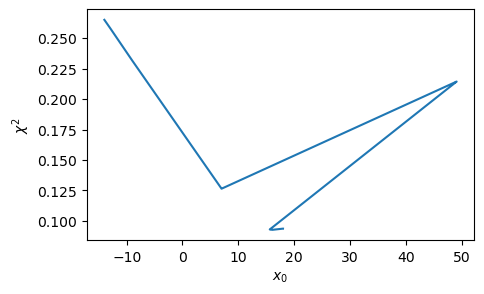

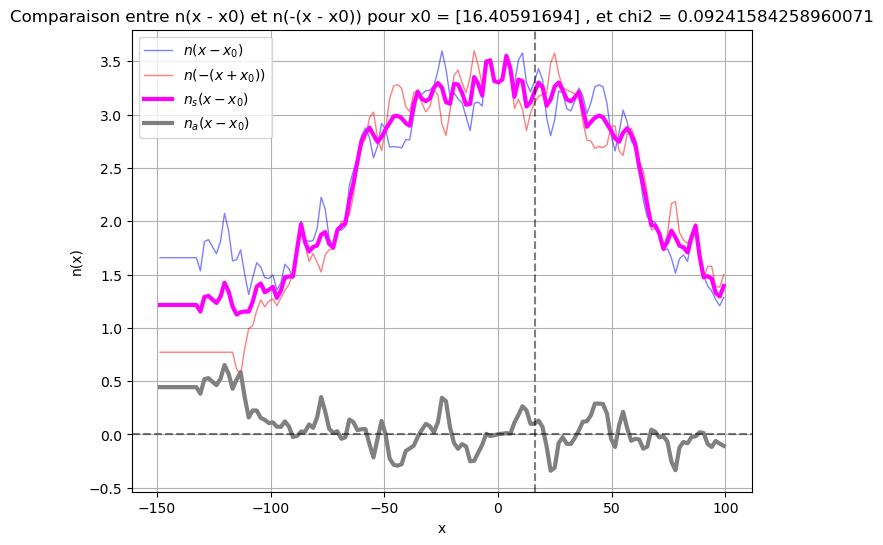

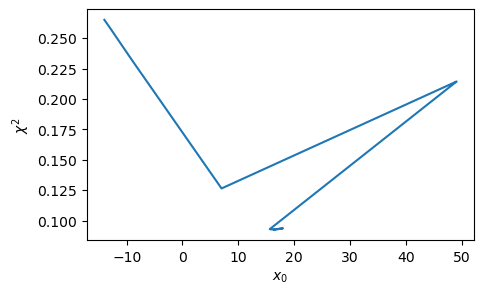

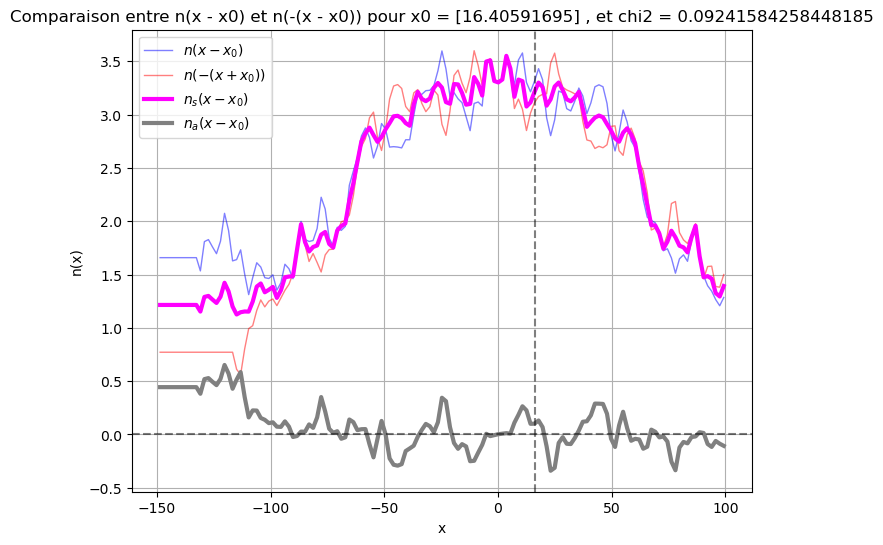

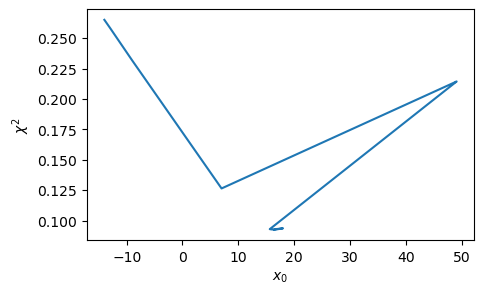

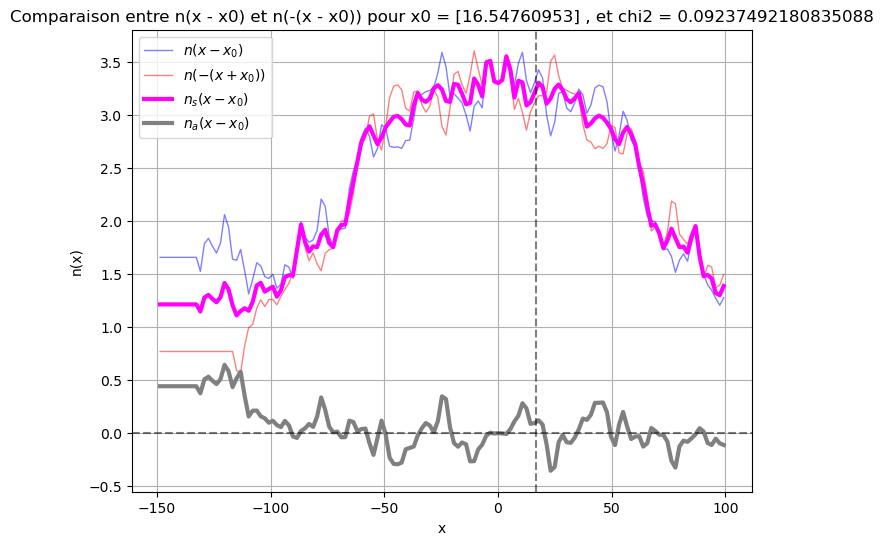

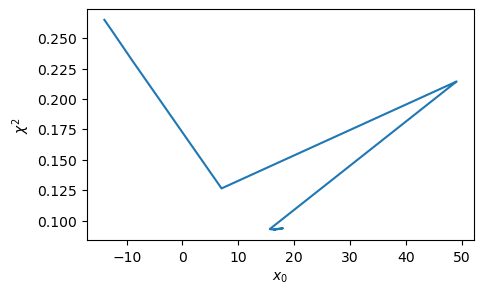

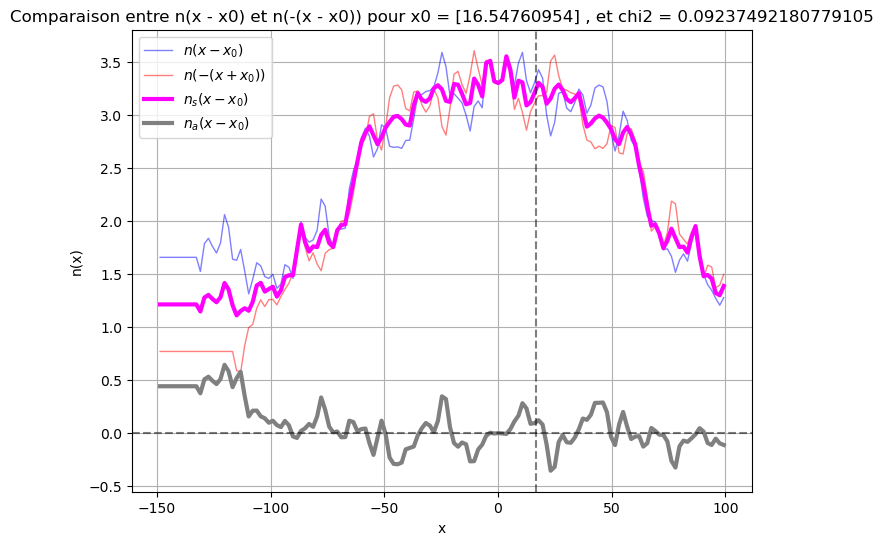

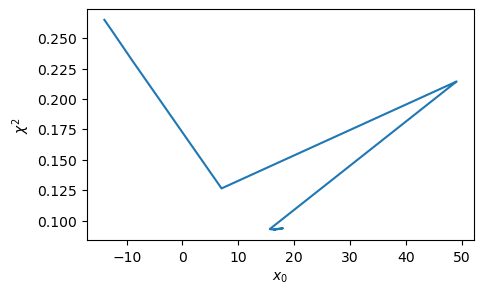

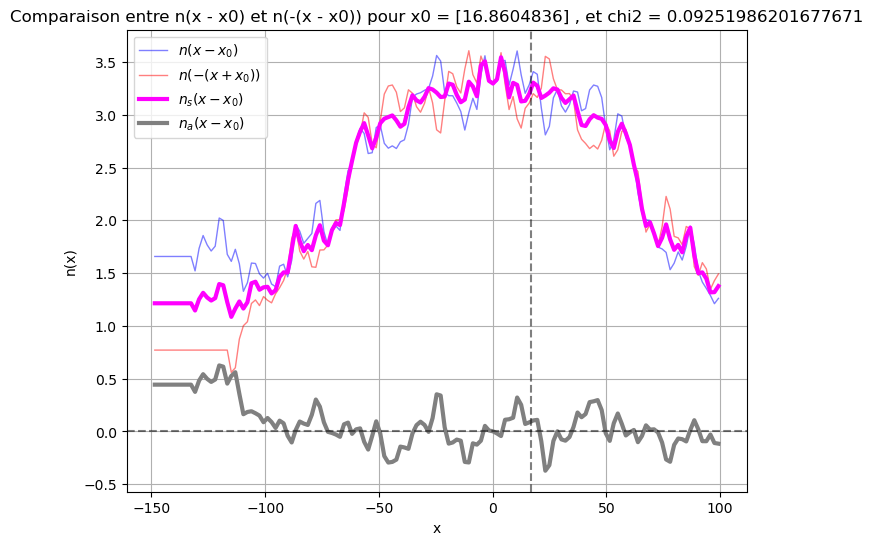

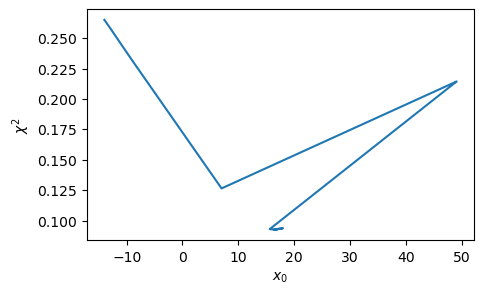

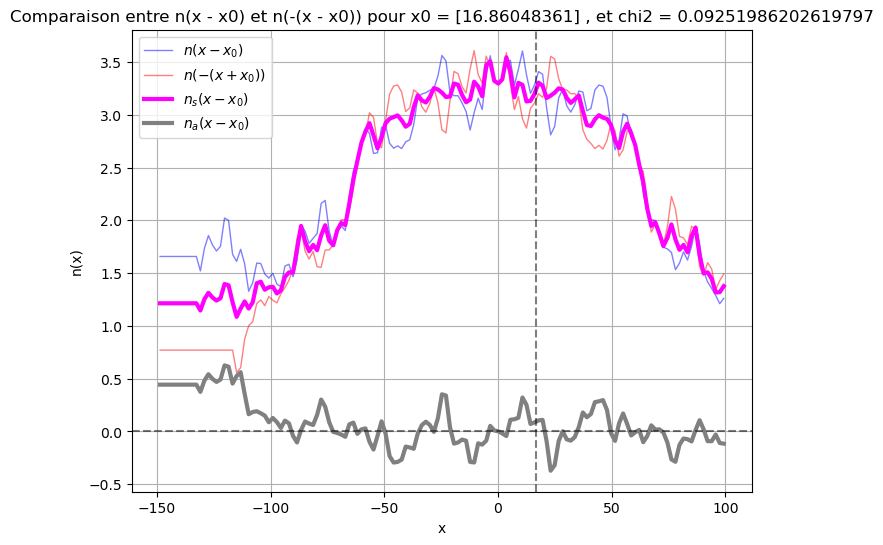

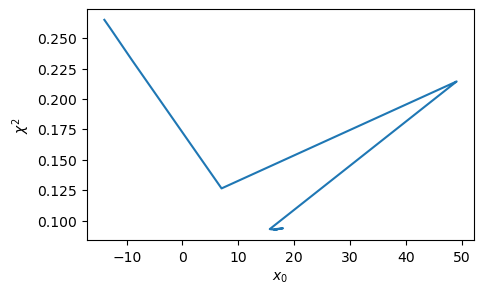

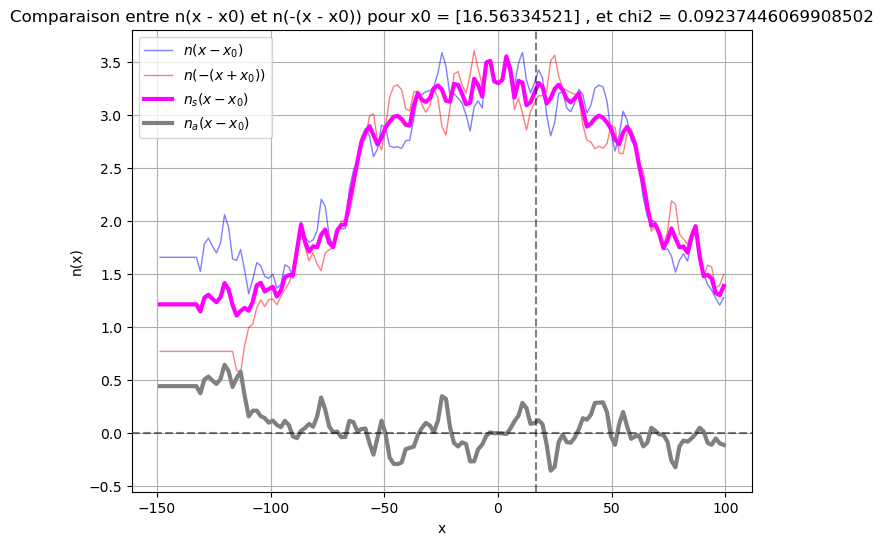

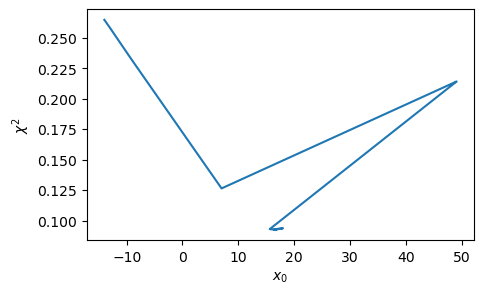

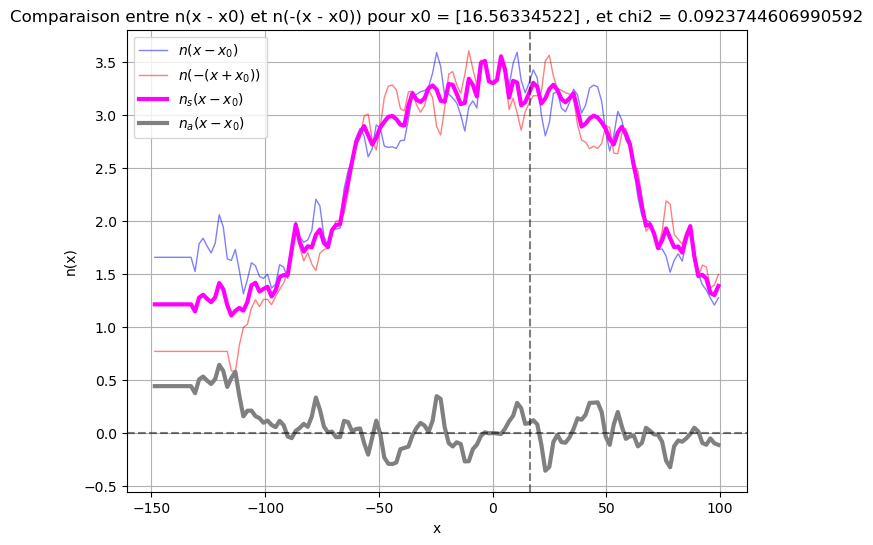

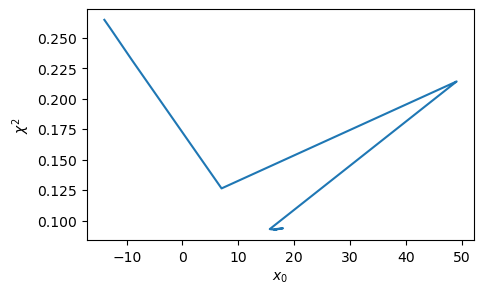

Optimisation terminée. x0 optimisé : 16.56334521127591, Chi-carré final : 0.09237446069908502


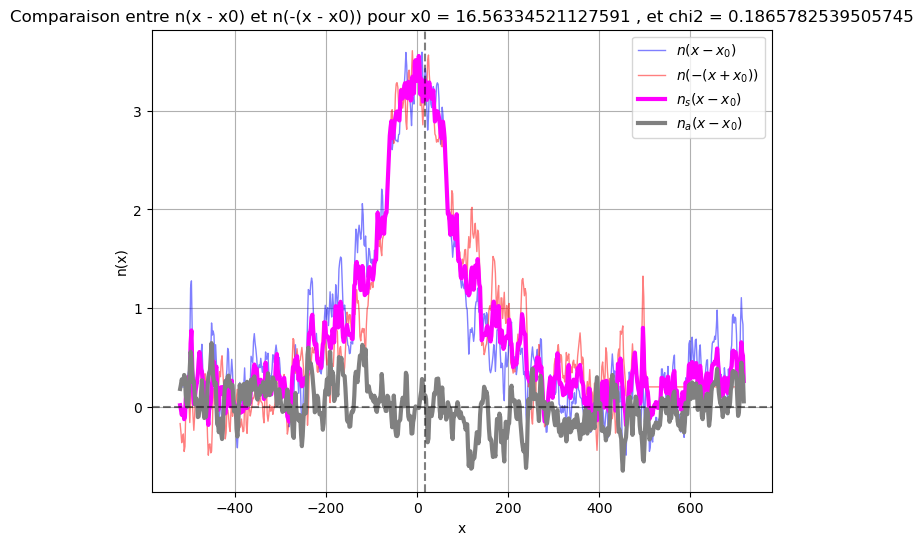

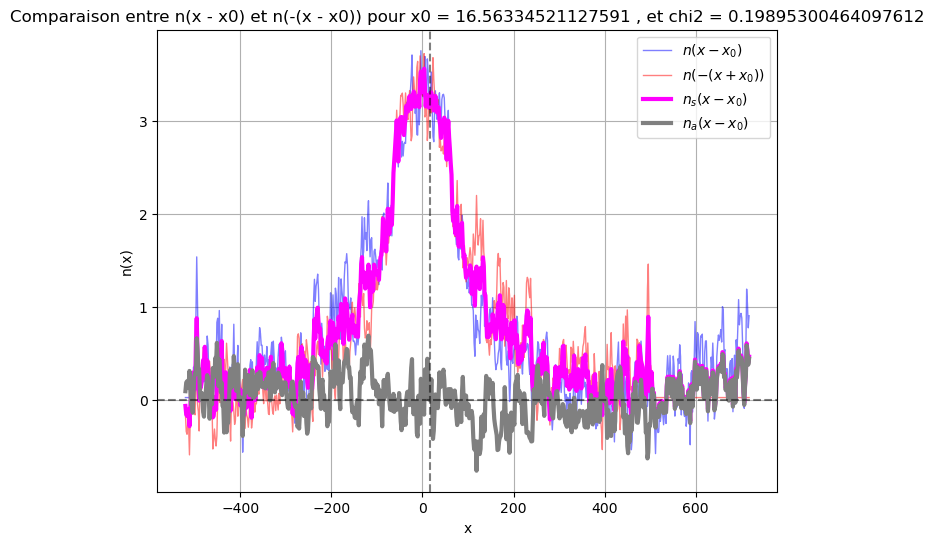

0.19895300464097612

In [ ]:
#Cercher min 

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

X0 , YChi2 = [] , []
plt.figure(figsize=(8, 6))
plt.title(f'Comparaison entre chi2 pour x')
# Fonction à minimiser (chi-carré en fonction de x0)
def objective_function(x0, x, y):
    chi = chi_squared_and_plot(x, y, x0)
    X0.append(x0)
    YChi2.append(chi)
    plt.plot( X0 , YChi2 ) 
    plt.xlabel('$x_0$')
    plt.ylabel(f'$\\chi^2$')
    plt.show()
    return chi


# Paramètres d'initialisation
#p0 =  117 # Estimation initiale pour x0
lower_bound = 0.5*p0  # Borne inférieure pour x0
upper_bound = 1.5*p0  # Borne supérieure pour x0

# Utilisation de scipy.optimize.minimize pour trouver le minimum de chi-carré
result = minimize(
    objective_function,  # Fonction objectif
    p0,  # Estimation initiale de x0
    args=(np.flip(X[mask]), np.flip(y_smoothed[mask])),  # Arguments supplémentaires (x_data, y_data)
    #args=(np.flip(X[mask]), np.flip(Y[mask])),  # Arguments supplémentaires (x_data, y_data)
    #bounds=[(lower_bound, upper_bound)],  # Bornes pour x0
    method='L-BFGS-B'  # Méthode de quasi-Newton avec bornes
)

# Résultat de l'optimisation
print(f"Optimisation terminée. x0 optimisé : {result.x[0]}, Chi-carré final : {result.fun}")


chi_squared_and_plot(np.flip(X), np.flip(y_smoothed), result.x[0])
chi_squared_and_plot(np.flip(X), np.flip(Y), result.x[0])

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\q'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\q'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/1601078509.py:55: SyntaxWarning: invalid escape sequence '\m'
  f'$x_0 = {x0:.3f}~\mu m, \; \\chi^2 = 2 \\Vert n_a^f \\Vert^2_2 = {chi2:.3f}~(\mu m)^{-2}; \quad (d = {window_size:.3f}~\mu m)$'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/1601078509.py:55: SyntaxWarning: invalid escape sequence '\m'
  f'$x_0 = {x0:.3f}~\mu m, \; \\chi^2 = 2 \\Vert n_a^f \\Vert^2_2 = {chi2:.3f}~(\mu m)^{-2}; \quad (d = {window_size:.3f}~\mu m)$'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/1601078509.

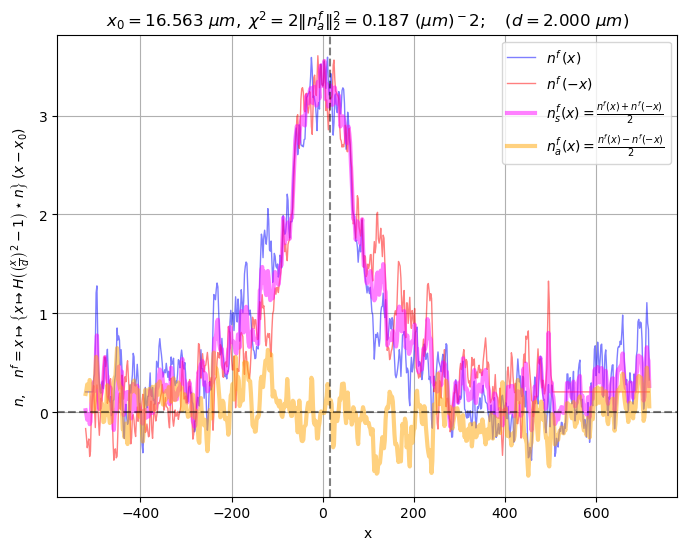

In [ ]:
# Fonction d'interpolation de n(x) (renvoie 0 si x est en dehors des bornes)
def n(x_val):
    if x_val < min(x):
        return y[0]  # Retourne 0 si x est hors des bornes
    elif x_val > max(x):
        return y[-1]

    from scipy.interpolate import CubicSpline

    # Créer l'interpolateur spline cubique
    spline = CubicSpline(x, y)

    # Générer des points à interpoler
    y_new = spline(x_val)
    return y_new#np.interp(x_val, x, y)  # Interpolation linéaire

x , y = np.flip(X), np.flip(y_smoothed)
#x , y = np.flip(X), np.flip(Y)

xs = result.x[0]
n_x_minus_xs = [n(xi-xs)for xi in x]

n_neg_x_minus_xs = [n(-xi-xs)for xi in x]

n_neg_x_minus_xs = [item if isinstance(item, np.float64) else item.item() for item in n_neg_x_minus_xs]
n_x_minus_xs = [item if isinstance(item, np.float64) else item.item() for item in n_x_minus_xs]

n_s = (np.array(n_x_minus_xs) + np.array(n_neg_x_minus_xs))/2
n_a = (np.array(n_x_minus_xs) - np.array(n_neg_x_minus_xs))/2


diff = np.array(n_x_minus_xs) - np.array(n_neg_x_minus_xs)

# Calcul de chi²
sigma = None
if sigma is None:sigma = np.ones_like(y)  # Si sigma n'est pas spécifié, on prend une incertitude de 1

chi2 = np.sum((np.array(diff) ** 2) / (np.array(sigma) ** 2))
chi2 = norme(diff/2, 2)/norme(n_x_minus_xs , 2)

x_vals = x

# Tracé des deux courbes
plt.figure(figsize=(8, 6))
#plt.plot(x_vals, n_x, label=r'$n(x)$', color='blue')
plt.plot(x_vals, n_x_minus_xs, label=r'$n^f \,(x)$', color='blue' ,  linewidth=1, alpha=0.5 )


#plt.plot(x_vals, n_neg_x_plus_xs, label=r'$n(-(x - x_0))$', color='red', linestyle='--')
plt.plot(x_vals, n_neg_x_minus_xs, label=r'$n^f \,(-x )$', color='red',  linewidth=1, alpha=0.5)
plt.plot(x_vals, n_s, label=r'$n_s^f(x) = \frac{n^f(x) + n^f(-x)}{2}$', color='magenta', linestyle='-' , linewidth=3 , alpha = 0.5 )
plt.plot(x_vals, n_a, label=r'$n_a^f(x) = \frac{n^f(x) - n^f(-x)}{2}$', color='orange', linestyle='-' , linewidth=3 , alpha = 0.5 ) 
#plt.scatter(X, Y, color='black', label=r'Données originales $n(x)$')
plt.title(
    f'$x_0 = {xs:.3f}~\mu m, \; \\chi^2 = 2 \\Vert n_a^f \\Vert^2_2 = {chi2:.3f}~(\mu m)^{-2}; \quad (d = {window_size:.3f}~\mu m)$'
)
plt.axvline(x=xs, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlabel('x')
plt.ylabel(r'$n , \quad n^f = x \mapsto \left \{x \mapsto H\left(\left(\frac{x}{d}\right)^2 - 1\right) \star n \right\}\, ( x -x_0 ) $ ')
plt.legend()
plt.grid(True)
#plt.savefig('./graphique_transparent.png', transparent=True)
#plt.savefig('./graphique_high_res.png', dpi=300) 
plt.show()


In [ ]:
colors = [
    #"#1f77b4",  # Bleu
    #"#ff7f0e",  # Orange
    #"#2ca02c",  # Vert
    #"#d62728",  # Rouge
    "#9467bd",  # Violet
    "#8c564b",  # Marron
    "#e377c2",  # Rose
    "#7f7f7f",  # Gris
    "#bcbd22",  # Jaune Olive
    "#17becf"   # Cyan
]

In [45]:
# Tracé des deux courbes
print(xs)
plt.figure()
### Plot style
police = 12
plt.rcParams["figure.figsize"] = (5,3)

#plt.plot(x_vals, n_x, label=r'$n(x)$', color='blue')
#plt.plot(x_vals, n_x_minus_xs, label=r'$n^f \,(x)$', color='blue' ,  linewidth=1, alpha=0.5 )
#plt.plot(X+xs, Y, label=r'$n \,(x -x_0)$', color="#1f77b4" ,  linewidth=1.5, alpha=0.8 )
#plt.plot(X+xs, y_smoothed, label=r'$n^s \,(+x)$', color="#1f77b4" ,  linewidth=1.5, alpha=0.8 )
#plt.plot(X, y_smoothed, label=r'$\tilde{n} \,(x)$', color="#1f77b4" ,  linewidth=1.5, alpha=0.8 )
plt.plot(X, Y, label=r'$\tilde{n} \,(x)$', color="#1f77b4" ,  linewidth=1.5, alpha=0.8 )


#plt.plot(x_vals, n_neg_x_plus_xs, label=r'$n(-(x - x_0))$', color='red', linestyle='--')
#plt.plot(x_vals, n_neg_x_minus_xs, label=r'$n^f \,(-x )$', color='red',  linewidth=1, alpha=0.5)
#plt.plot(-X-xs, Y, label=r'$n \,(-x-x_0 )$', color="#d62728",  linewidth=1.5, alpha=0.8)
#plt.plot(-X-xs, y_smoothed, label=r'$n^s \,(-x)$', color="#d62728",  linewidth=1.5, alpha=0.8)
#plt.plot(-X-2*xs, y_smoothed, label=r'$\tilde{n} \,(2x_s-x)$', color="#d62728" ,  linewidth=1.5, alpha=0.8 )
plt.plot(-X-2*xs, Y, label=r'$\tilde{n} \,(2x_s-x)$', color="#d62728" ,  linewidth=1.5, alpha=0.8 )
#plt.plot(X-2*xs, y_smoothed, label=r'$\tilde{n} \,(2x_s-x)$', color="#d62728" ,  linewidth=1.5, alpha=0.8 )

#plt.plot(X+xs, y_smoothed, label=r'$n^f \,(x)$', color="#7f7f7f" ,  linewidth=1.5, alpha=1 )
#plt.plot(-X-xs, y_smoothed, label=r'$n^f \,(-x)$', color="#8c564b",  linewidth=1.5, alpha=1)
#plt.plot(x_vals, n_s, label=r'$n_s^f(x) = \frac{n^f(x) + n^f(-x)}{2}$', color='magenta', linestyle='-' , linewidth=3 , alpha = 0.5 )
#plt.plot(x_vals, n_a, label=r'$n_a^f(x) = \frac{n^f(x) - n^f(-x)}{2}$', color='orange', linestyle='-' , linewidth=3 , alpha = 0.5 ) 
#plt.scatter(X, Y, color='black', label=r'Données originales $n(x)$')
#plt.title(
#    f'$x_s = {xs:.3f}~\mu m, \; \\chi = \\Vert n_a^s \\Vert_2/\\Vert n^s \\Vert_2= {chi2:.3f}; \quad (d = {window_size:.0f}~\mu m)$',
#    fontsize=14, color='black'
#)
#plt.axvline(x=X[-1]+xs, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
#plt.axvline(x=-X[-1]-xs, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axvline(x=-xs, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlim([X[-1]+xs , -X[-1]-xs])
plt.ylim([-0.5 , 3.7])
#plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlabel(r'$x\quad (\mu m)$', fontsize=police, color='black')#, fontweight='bold')
#plt.ylabel(r'$n^s ~\colon~ x \mapsto \left \{n \star \left(y \mapsto   H\left(\left(\frac{y}{d}\right)^2 - 1\right) \right) \right\}\, ( x -x_c ) ~~(1/\mu m )$ ' , fontsize=14, color='black' )
#plt.ylabel(r'$n^s = \left \{n \star \left(y \mapsto   H\left(\left(\frac{y}{d}\right)^2 - 1\right) \right) \right\} ~~(1/\mu m )$ ' , fontsize=14, color='black' )
plt.ylabel(r'$\tilde{n} \quad (\mu m^{-1} $) ' , fontsize=police, color='black' )

plt.grid(color='white', linestyle='-', linewidth=1)

# Appliquer un fond gris
#plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas


# Appliquer un fond gris clair au graphe
#plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé

# Rendre le cadre invisible
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

#plt.gcf().set_facecolor('lightgray')  # Fond gris pour l'ensemble de la figure

# Ajouter une légende avec fond gris et bordure blanche
plt.legend(
    fontsize=police,
    facecolor='#e8e8e8',  # Fond gris pour la légende
    #edgecolor='#b0b0b0',       # Bordure blanche pour la légende
    bbox_to_anchor=(0.58, 1.0)  # Ajuster ici (x, y)
)
plt.grid(True)
plt.savefig('./article_asymetrie_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
plt.savefig('./article_asymetrie_24-04-2024.svg', bbox_inches='tight', dpi = 300)
plt.show()

# 400 mu m pour 8 cm
# 3 mu m -1  c'est 8 cm sur lon graphe 
save_as_tikz_table(X*10/(500), y_smoothed*9/3, filename="donnee_article_asymetrie_24-04-202.table")
#read_and_plot_table(filename="donnee_article_asymetrie_24-04-202.table")
save_as_tikz_table((-X-2*xs)*8/(400), y_smoothed*9/3, filename="donnee_2_article_asymetrie_24-04-202.table")
#read_and_plot_table(filename="donnee_2_article_asymetrie_24-04-202.table")

NameError: name 'xs' is not defined

<>:60: SyntaxWarning: invalid escape sequence '\q'
<>:61: SyntaxWarning: invalid escape sequence '\q'
<>:60: SyntaxWarning: invalid escape sequence '\q'
<>:61: SyntaxWarning: invalid escape sequence '\q'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/2759701971.py:60: SyntaxWarning: invalid escape sequence '\q'
  plt.xlabel("$x\quad (\mu$m)", fontsize = police, color = "black")
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/2759701971.py:61: SyntaxWarning: invalid escape sequence '\q'
  plt.ylabel("$n\quad (\mu$m$^{-1}$)", fontsize = police, color = "black")


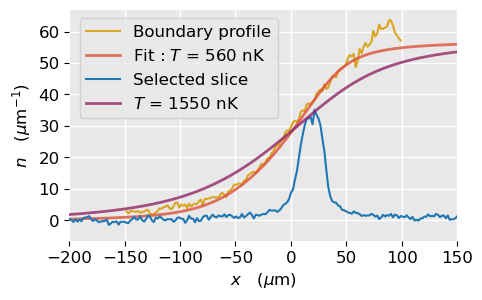

✅ Fichier enregistré sous : donnee_bord_article_distribution_24-04-2024.table
✅ Fichier enregistré sous : donnee_selection_1_article_distribution_24-04-2024.table
✅ Fichier enregistré sous : GHD_bord_article_distribution_24-04-2024.table
✅ Fichier enregistré sous : GHD_bord_2_article_distribution_24-04-2024.table


In [ ]:
X , Y , label = X_1_18 , Y_1_18 , "legend"



### Plot style
police = 12
plt.rcParams["figure.figsize"] = (5,3)
plt.rcParams["figure.figsize"] = (5,3)

### Plot
plt.figure()
plt.plot(X[mask], Y[mask], color = "goldenrod", label = "Boundary profile" )

nom1 = "theta_edge_1.0_ih1"
data_GHD = np.load(f"{date}/density_expansion_nu_{nom1}_{mu:.3f}_{T:.3f}_{'veff_bord'}.npz") 
plt.plot(data_GHD[0, :] * Temp_bord, data_GHD[1, :], color=plt.cm.inferno(0.6), linewidth=2, alpha=0.8,
         label=f"Fit : $T$ = {round(T, -1):.0f} nK")

X , Y , label = X_2_1 , Y_2_1 , "legend"
mask = (X < 100*Temp_bord)*(X>-100*Temp_bord)
#ax1.plot(X[mask], Y[mask], color='#1f77b4' ,label=f"donnés du "+ date_donnees + ' : ' + label )
plt.plot(X[mask], Y[mask], color='#1f77b4' ,label= "Selected slice" )

nom2 = "theta_edge_1.0_ih2"
mu_exp, T_exp, x0_exp, Taille_exp = 25.997, 1549.169, 18.3, 24.1
filename = f"{date}/density_expansion_nu_{nom1}_{mu_exp:.3f}_{T_exp:.3f}_{'veff_bord'}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
data_GHD2 = np.load(filename)
plt.plot(data_GHD2[0, :] * Temp_bord, data_GHD2[1, :], color=plt.cm.inferno(0.4), linewidth=2, alpha=0.8,
         label=f"$T$ = {round(T_exp, -1):.0f} nK")

# Ajouter une grille blanche
plt.grid(color='white', linestyle='-', linewidth=1)

# Appliquer un fond gris
#plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas


# Appliquer un fond gris clair au graphe
#plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé

# Rendre le cadre invisible
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

#plt.gcf().set_facecolor('lightgray')  # Fond gris pour l'ensemble de la figure

# Ajouter une légende avec fond gris et bordure blanche
plt.legend(
    loc='upper left',
    fontsize=police,
    facecolor='#e8e8e8',  # Fond gris pour la légende
    #edgecolor='black',       # Bordure blanche pour la légende
    bbox_to_anchor=(0.005, 1)  # Ajuster ici (x, y)
)

plt.xlabel("$x\quad (\mu$m)", fontsize = police, color = "black")
plt.ylabel("$n\quad (\mu$m$^{-1}$)", fontsize = police, color = "black")
plt.xticks(fontsize = police, color = "black")
plt.yticks(fontsize = police, color = "black")
#plt.legend(fontsize = police)
plt.xlim(-200,150)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-mu-T-x0=18.3.pdf", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-mu-T-x0=18.3.svg", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-mu-T-Taille=29.pdf", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-mu-T-Taille=29.svg", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-T-x0.pdf", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_deformation_1_24-04-2024-T-x0.svg", bbox_inches='tight', dpi = 300)
plt.show()

# 150+200 mu m c'est 20 cm sur lon graphe 
# 60 mu m -1  c'est 11 cm sur lon graphe 
save_as_tikz_table(X_1_18*20/(150+200), Y_1_18*11/60, filename="donnee_bord_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="donnee_bord_article_distribution_24-04-2024.table")
save_as_tikz_table(X_2_1*20/(150+200), Y_2_1*11/60, filename="donnee_selection_1_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="donnee_selection_1_article_distribution_24-04-2024.table")
save_as_tikz_table(data_GHD[0, :] * Temp_bord*20/(150+200), data_GHD[1, :]*11/60, filename="GHD_bord_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="GHD_bord_article_distribution_24-04-2024.table")
save_as_tikz_table(data_GHD2[0, :] * Temp_bord*20/(150+200), data_GHD2[1, :]*11/60, filename="GHD_bord_2_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="GHD_bord_2_article_distribution_24-04-2024.table")

la  33.0905469976991
✅ Fichier enregistré sous : GHD_article_distribution_24-04-2024.table
✅ Fichier enregistré sous : Pi_article_distribution_24-04-2024.table
theta_edge_1.0_ih2
filename = 2025-01-27/rho_bon_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz
filename = 2025-01-27/theta_discr_exp_2_theta_edge_1.0_discr_ih2_64.676_559.424_18.339.npz
600
✅ Fichier enregistré sous : rho_article_distribution_24-04-2024.table


<>:65: SyntaxWarning: invalid escape sequence '\q'
<>:65: SyntaxWarning: invalid escape sequence '\q'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/3491430767.py:65: SyntaxWarning: invalid escape sequence '\q'
  ax1.set_xlabel("$x \quad (\mu m/ms)$", fontsize=police)


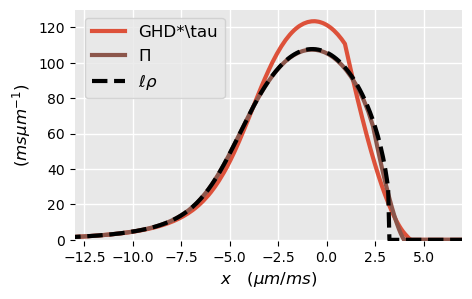

In [ ]:
#theta_discr_exp = np.load(f"{date}/theta_discr_exp_{nom2}_{mu_b:.3f}_{T_b:.3f}_{x0_b:.3f}_{Taille_b:.3f}_{0:.3f}.npz")
filename = f"{date}/theta_discr_exp_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp = np.load(filename)

fig, ax1 = plt.subplots()
X , Y , label = X_2_30, Y_2_30 , "legend"
Temps_exp = 30
mask = X < 20*Temps_exp



nom = "theta_edge_1.0_ih2"
filename = f"{date}/density_expansion_nu_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{Temps_exp:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
data_s = np.load(filename) 
label = r"GHD*\tau"
# Créer un nouvel intervalle allant de 0 à 400
x_new = np.linspace(max(data_s[0, :] * Taille/Temps_exp) , 400/Temps_exp, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux

# Concaténer avec tes données existantes
x_combined = np.concatenate([data_s[0, :] * Taille/Temps_exp, x_new])-x0/Temps_exp
y_combined = np.concatenate([data_s[1, :] *Temps_exp, y_new])
        
ax1.plot(x_combined, y_combined, linewidth=3, color=plt.cm.inferno(0.6), alpha=1,
         label=label)


# 20 mu m/ms pour 20 cm
# 3 mu m -1  c'est 8 cm sur lon graphe 
print ("la " ,  x_combined[-1] - x_combined[0])
save_as_tikz_table(x_combined*20/20, y_combined*10/120, filename="GHD_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="GHD_article_distribution_24-04-2024.table")

delta_x = np.array([x_combined[i+1] - x_combined[i] for i in range(len(x_combined)-1)] + [x_combined[len(x_combined)-1] - x_combined[len(x_combined)-2]])
#print("nombre atome GDH " , integrale(x_combined, y_combined) ,  np.sum(y_combined*delta_x))



#ax1.plot(X[mask], Y[mask], label=f"donnés du "+ date_donnees + ' : ' + label )
index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore


label = r"$\Pi$"
x_new = np.linspace(max(theta_discr_exp) , 400/Temps_exp, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux
filename = f"{date}/Pi_{nom2}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{0:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
Pi_0 = np.load(filename) * Taille
# Concaténer avec tes données existantes
x_combined = np.concatenate([theta_discr_exp, x_new])
y_combined = np.concatenate([Pi_0, y_new])
ax1.plot(x_combined,  y_combined, linewidth=3, color="#8c564b",alpha=1, 
         label=label)

# 20 mu m/ms pour 20 cm
# 3 mu m -1  c'est 8 cm sur lon graphe 
save_as_tikz_table(x_combined*20/(20), y_combined*10/120, filename="Pi_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="Pi_article_distribution_24-04-2024.table")


theta_discr = np.load(f"{date}/theta_discr_{nom2[index_last_underscore+1:]}.npz")
#ax1.set(xlabel="$x \quad \mu m  $", ylabel="$n(x) \quad ( 1/\mu m^1 ) $", title=f" $\\mu = $ {mu_b:.3f} $nK$ , $T =$ {T_b:.3f} $nK$ , $x_0 =$ {x0_b:.3f} $\mu m$,  $\\ell =$ {Taille_b:.3f} $\mu m$")
ax1.set_xlabel("$x \quad (\mu m/ms)$", fontsize=police)
ax1.set_ylabel(r"$(ms\mu m^{-1})$", fontsize=police)
#ax1.set_title(f" $\\mu = $ {mu_b:.1f} $nK$ , $T =$ {T_b:.0f} $nK$ , $x_0 =$ {x0_b:.1f} $\mu m$,  $\\ell =$ {Taille_b:.1f} $\mu m$", fontsize=16)
print(nom)
index_last_underscore = nom2.rfind('_')  # Trouver l'index du dernier underscore
#filename = f"{date}/rho_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
filename = f"{date}/rho_bon_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
rho_theta_star_discr = np.load(filename)['arr_0']


filename = f"{date}/theta_discr_exp_2_{nom2[:index_last_underscore]}_discr_{nom2[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}_{x0:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr_exp_2 = np.load(filename)['arr_0']

label = r"$\ell\rho$" 



#theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
theta0 =  x0/Temps_exp

print(len(theta_discr_exp_2) )#,theta_discr_exp_2 )
ax1.plot(theta_discr_exp_2, 
         rho_theta_star_discr*Taille , 
         linewidth=3 , 
         linestyle='--',
         alpha=1,
         color = "black",#"#bcbd22", 
         label=label)
#print("nombre atome rho " , integrale((theta_discr_exp_2+theta0)*Temps_exp,rho_theta_star_discr/Temps_exp*Taille_b)) 

# 20 mu m/ms pour 20 cm
# 3 mu m -1  c'est 8 cm sur lon graphe 
save_as_tikz_table(theta_discr_exp_2*20/20, rho_theta_star_discr*Taille*10/120, filename="rho_article_distribution_24-04-2024.table")
#read_and_plot_table(filename="rho_article_distribution_24-04-2024.table")

plt.ylim([-0.5 , 130 ])
plt.xlim([-13, 7 ])    
plt.grid(True)
#plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
#plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
# Personnalisation de la légende
ax1.legend(
    #loc='upper left',             # Position de la légende
    loc='upper left',
    #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
    #loc='best', 
    bbox_to_anchor=(0.005, 1),
    #fancybox=False,                  # Ajouter une bordure arrondie
    #shadow=False,                    # Ajouter une ombre
    #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
    fontsize=police,                    # Taille de la police
    #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
    facecolor='#e8e8e8',                  # Couleur de fond de la légende
    #edgecolor='black',              # Couleur du bord de la légende
    #title='Légende de l\'expérience', # Titre de la légende
    #title_fontsize='large',         # Taille de la police du titre
    #labelspacing=0.1,               # Espacement entre les labels de la légende
    #handlelength=0.5,               # Longueur des poignées des items de la légende
    #handleheight=1.5,               # Hauteur des poignées des items de la légende
    #columnspacing=0,               # Espacement entre les colonnes
    #alignment = 'right',
)
plt.grid(color='white', linestyle='-', linewidth=1)
# Rendre le cadre invisible
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Appliquer un fond gris
#plt.gca().set_facecolor('lightgray')  # Fond gris pour le canevas


# Appliquer un fond gris clair au graphe
#plt.gca().set_facecolor('#f0f0f0')  # Fond gris très clair (hex pour personnalisation)
plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
#plt.savefig('Figures/article_distribution_24-04-2024.pdf', bbox_inches='tight', dpi = 300)
#plt.savefig('Figures/article_distribution_24-04-2024.svg', bbox_inches='tight', dpi = 300)
plt.show()

# 400 mu m pour 8 cm
# 3 mu m -1  c'est 8 cm sur lon graphe 
#save_as_tikz_table(X*10/(500), y_smoothed*9/3, filename="article_distribution_24-04-2024.pdf")
#read_and_plot_table(filename="donnee_article_asymetrie_24-04-202.table")
#save_as_tikz_table((-X-2*xs)*8/(400), y_smoothed*9/3, filename="article_distribution_24-04-2024.pdf")
#read_and_plot_table(filename="donnee_2_article_asymetrie_24-04-202.table")

<>:19: SyntaxWarning: invalid escape sequence '\q'
<>:19: SyntaxWarning: invalid escape sequence '\q'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_67651/1101756496.py:19: SyntaxWarning: invalid escape sequence '\q'
  ax1.set_xlabel("$x \quad (\mu m)$", fontsize=police)


✅ Fichier enregistré sous : Donnee_article_simul_expansion_1_24-04-2024-T-x0.table
✅ Fichier enregistré sous : GHD_1_article_simul_expansion_1_24-04-2024-T-x0.table
✅ Fichier enregistré sous : GHD_2_article_simul_expansion_1_24-04-2024-T-x0.table
theta_edge_1.0_ih2
filename = 2025-01-27/rho_theta_edge_1.0_discr_ih2_25.997_1549.169_18.300.npz
filename = 2025-01-27/rho_theta_edge_1.0_discr_moy_ih2_25.997_1549.169_18.300_24.100.npz


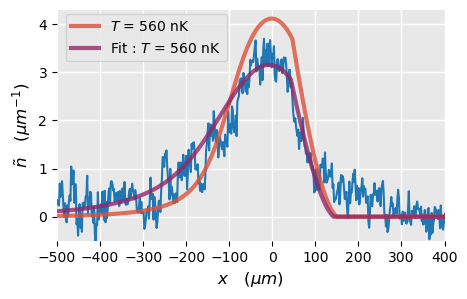

In [ ]:
fig, ax1 = plt.subplots()
X , Y , label = X_2_30, Y_2_30 ,"legend"
mask = X < 20*Temps_exp
#ax1.plot(X[mask], Y[mask], color = "#1f77b4" , label=f"donnés du "+ date_donnees + ' : ' + label )
ax1.plot(X[mask], Y[mask], color = "#1f77b4" )#, label="Data" )

# 900 mu m pour 20 cm
# 4 mu m -1  c'est 10 cm sur lon graphe 
save_as_tikz_table(X*20/(500+400), Y*10/4, filename="Donnee_article_simul_expansion_1_24-04-2024-T-x0.table")
#read_and_plot_table(filename="Donnee_article_simul_expansion_1_24-04-2024-T-x0.table")


index_last_underscore = nom.rfind('_')  # Trouver l'index du dernier underscore

filename = f"{date}/theta_discr_{nom[index_last_underscore+1:]}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
theta_discr = np.load(filename)

ax1.set_xlabel("$x \quad (\mu m)$", fontsize=police)
ax1.set_ylabel(r"$\tilde{n} \quad (\mu m^{-1})$", fontsize=police)
ax1.set_title("", fontsize=16)

#plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
#plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

nom = "theta_edge_1.0_ih2"
filename = f"{date}/density_expansion_nu_{nom}_{mu:.3f}_{T:.3f}_{x0:.3f}_{Taille:.3f}_{Temps_exp:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
data_s = np.load(filename) 

# Créer un nouvel intervalle allant de 0 à 400
x_new = np.linspace(max(data_s[0, :] * Taille) , 400, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux

# Concaténer avec tes données existantes
x_combined = np.concatenate([data_s[0, :] * Taille, x_new])
y_combined = np.concatenate([data_s[1, :], y_new])

ax1.plot(x_combined, 
         y_combined, 
         linewidth=3, 
         color=plt.cm.inferno(0.6), 
         alpha=0.8, 
         label=f"$T$ = {round(T, -1):.0f} nK"
            )

save_as_tikz_table(x_combined*20/(500+400), y_combined*10/4, filename="GHD_1_article_simul_expansion_1_24-04-2024-T-x0.table")
#read_and_plot_table(filename="GHD_1_article_simul_expansion_1_24-04-2024-T-x0.table")

filename = f"{date}/density_expansion_nu_{nom}_{mu_exp:.3f}_{T_exp:.3f}_{x0_exp:.3f}_{Taille_exp:.3f}_{Temps_exp:.3f}.npz"
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
data_s = np.load(filename) 

# Créer un nouvel intervalle allant de 0 à 400
x_new = np.linspace(max(data_s[0, :] * Taille_exp) , 400, 100)  # 100 points entre 0 et 400
y_new = np.zeros_like(x_new)  # Remplir les valeurs de y avec des zéros ou une fonction que tu veux

# Concaténer avec tes données existantes
x_combined = np.concatenate([data_s[0, :] * Taille_exp, x_new])
y_combined = np.concatenate([data_s[1, :], y_new])

      
ax1.plot(
        x_combined,  # X : données des abscisses, multipliées par Taille
        y_combined,  # Y : données des ordonnées
        linewidth=3,  # Épaisseur de la ligne
        color=plt.cm.inferno(0.4),  # Couleur de la ligne (code hexadécimal)
        alpha=0.8,  # Transparence de la ligne (0 = transparent, 1 = opaque)
        label=f"Fit : $T$ = {round(T, -1):.0f} nK"
        )

save_as_tikz_table(x_combined*20/(500+400), y_combined*10/4, filename="GHD_2_article_simul_expansion_1_24-04-2024-T-x0.table")
#read_and_plot_table(filename="GHD_2_article_simul_expansion_1_24-04-2024-T-x0.table")
    
index_last_underscore = nom.rfind('_')  # Trouver l'index du dernier underscore
print(nom)
filename = f"{date}/rho_{nom[:index_last_underscore]}_discr_{nom[index_last_underscore+1:]}_{mu_exp:.3f}_{T_exp:.3f}_{x0_exp:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
rho_theta_star_discr = np.load(filename)
filename = f"{date}/rho_{nom[:index_last_underscore]}_discr_moy_{nom[index_last_underscore+1:]}_{mu_exp:.3f}_{T_exp:.3f}_{x0_exp:.3f}_{Taille_exp:.3f}.npz"
print ( 'filename =' ,filename )
#sync_files(USER, HOST, PASSWORD, remote_path0 + filename, local_path + "/"+ filename )
rho_theta_discr_moy = np.load(filename)
theta0 = theta_discr[np.argmax(rho_theta_star_discr)]
theta0 =  0 
#ax1.plot(theta_discr*t, rho_theta_star_discr/t*Taille, label=f"$\\rho^\\star/\\tau*\\ell : \\quad \\mu$ = {mu:.3f} nK, $T$ = {T:.3f} nK, $x_0$ = {x0:.3f} $\\mu$m")
#ax1.plot(theta_discr*t, rho_theta_discr_moy/t*Taille, label=f"$\\Pi^\\star/\\tau*\\ell : \\quad \\mu$ = {mu:.3f} nK, $T$ = {T:.3f} nK, $x_0$ = {x0:.3f} $\\mu$m , $\\ell$ = {Taille:.3f} $\\mu$m")
ax1.set_xlim(-10*Temps_exp, 10*Temps_exp)  
plt.ylim([-0.5 , 4.3 ])
plt.xlim([-500, 400 ])
plt.grid(color='white', linestyle='-', linewidth=1)
plt.gca().set_facecolor('#e8e8e8')  # Fond gris plus foncé
# Rendre le cadre invisible
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.grid(True)
# Personnalisation de la légende
ax1.legend(
    #handles=legend_elements,
    #loc='upper left',             # Position de la légende
    loc='upper left',
    #bbox_to_anchor=(0.3, 1),    # Ajuste la position avec un ancrage spécifique
    #loc='best', 
    bbox_to_anchor=(0.005, 1.01),
    #fancybox=False,                  # Ajouter une bordure arrondie
    #shadow=False,                    # Ajouter une ombre
    #ncol=1,                         # Nombre de colonnes pour les entrées de la légende
    fontsize=10,#police,                    # Taille de la police
    #framealpha=0.5,                 # Transparence du fond de la légende (0: transparent, 1: opaque)
    facecolor='#e8e8e8',                  # Couleur de fond de la légende
    #edgecolor='black',              # Couleur du bord de la légende
    #title='Légende de l\'expérience', # Titre de la légende
    #title_fontsize='large',         # Taille de la police du titre
    #labelspacing=0.1,               # Espacement entre les labels de la légende
    #handlelength=0.5,               # Longueur des poignées des items de la légende
    #handleheight=1.5,               # Hauteur des poignées des items de la légende
    #columnspacing=0,               # Espacement entre les colonnes
    #alignment = 'right',
)

#plt.savefig("Figures/article_simul_expansion_1_24-04-2024-T-x0.pdf", bbox_inches='tight', dpi = 300)
#plt.savefig("Figures/article_simul_expansion_1_24-04-2024-T-x0.svg", bbox_inches='tight', dpi = 300)
plt.show()



In [ ]:
400/30

13.333333333333334